## Env Check

In [149]:
import sys
import torch

print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Compiled Version: {torch.version.cuda}")
print(f"CUDA Available: {torch.cuda.is_available()}")

import logging
import os

# Suppress PyTorch compiler and Triton verbosity
os.environ["TORCH_LOGS"] = "-all"

for logger_name in ["torch", "torch._dynamo", "torch._inductor", "triton"]:
    logging.getLogger(logger_name).setLevel(logging.WARNING)

# Mute the filelock library explicitly
logging.getLogger("filelock").setLevel(logging.WARNING)

# Mute standard PyTorch and Triton loggers
logging.getLogger("torch").setLevel(logging.WARNING)
logging.getLogger("triton").setLevel(logging.WARNING)

# Stop third-party loggers from passing INFO messages to the root logger
for logger_name in ["filelock", "triton", "torch", "torch._inductor", "torch._dynamo"]:
    log = logging.getLogger(logger_name)
    log.setLevel(logging.WARNING)
    log.propagate = False
    
# Root logger: without this, level defaults to WARNING with no handler and
# every logging.info() in the training loop is silently discarded.
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    handlers=[logging.StreamHandler(sys.stdout)],
    force=True,          # override any handler a library installed first
)
logging.info("logging configured")   # if this does not print, nothing else will

execution_device = "cuda" if torch.cuda.is_available() else "cpu"

PyTorch Version: 2.0.1+cu117
CUDA Compiled Version: 11.7
CUDA Available: True
2026-09-01 05:42:53,189 | INFO | logging configured


## Data Generator

In [48]:
import torch
import numpy as np
import logging
import os

DATA_SEED = 1234
DATA_CACHE = "dataset_v2.pt"

RHO_MIN, RHO_MAX = 500.0, 20000.0          # ohm-cm, realistic soil range
LOG_RHO_MIN, LOG_RHO_MAX = np.log10(RHO_MIN), np.log10(RHO_MAX)

def soil_to_log_rho(soil_prof):
    """Normalized soil profile in [0,1] -> log10(rho) in [log10(500), log10(20000)].
    Interpolation happens in LOG space because gamma ~ 1/sigma ~ rho spans 1.6
    decades; linear interpolation of rho itself would bias toward high values."""
    return LOG_RHO_MIN + soil_prof * (LOG_RHO_MAX - LOG_RHO_MIN)


def interp_profile(prof, x_query):
    """Linear interpolation of a [B,P] profile onto x_query in [0,1].

    prof     : [B, P]  values at P equally spaced nodes spanning x in [0,1]
    x_query  : [N]     query points in [0,1]
    returns  : [B, N]
    """
    B, P = prof.shape
    x_query = x_query.to(prof.device)
    xs = x_query.clamp(0.0, 1.0) * (P - 1)          # [N] in [0, P-1]
    i0 = xs.floor().long().clamp(0, P - 2)          # [N]
    frac = (xs - i0.float()).unsqueeze(0)           # [1,N]
    lo = prof[:, i0]                                # [B,N]
    hi = prof[:, i0 + 1]                            # [B,N]
    return lo + frac * (hi - lo)


def gamma_of_x(soil_prof, x_query, phys):
    """Per-sample, per-x charge-coupling coefficient.

    gamma = n*F*D*C_bulk / sigma,  sigma = 100/rho_ohm_cm
    Returns [B, N] matching x_query.
    NOTE: uses the scalar phys["C_bulk"]. Once C_bulk becomes a function of x
    (from the fluid profile), this must take the LOCAL C_bulk(x) instead --
    gamma is proportional to it."""
    log_rho = soil_to_log_rho(interp_profile(soil_prof, x_query))   # [B,N]
    rho = torch.pow(10.0, log_rho)
    sigma = 100.0 / rho
    return (phys["n_electrons"] * phys["F"] * phys["D_global"] * phys["C_bulk"]) / sigma


class API5LDataGenerator:
    def __init__(self, batch_size=1000):
        self.batch_size = batch_size
        self.wt_min, self.wt_max = 0.25, 1.0
        self.od_min, self.od_max = 4.0, 48.0

    def generate_grf_profiles(self, points, length_scale=0.2):
        x = np.linspace(0, 1, points)
        X, Y = np.meshgrid(x, x)
        cov = np.exp(-0.5 * ((X - Y) / length_scale) ** 2) + 1e-6 * np.eye(points)
        L = np.linalg.cholesky(cov)
        z = np.random.randn(self.batch_size, points)
        prof = 1 / (1 + np.exp(-(z @ L.T)))
        return torch.tensor(prof, dtype=torch.float32)

    def generate_api5l_metadata(self):
        real_wt = torch.FloatTensor(self.batch_size).uniform_(self.wt_min, self.wt_max)
        real_od = torch.FloatTensor(self.batch_size).uniform_(self.od_min, self.od_max)
        yolo_defect_score = torch.FloatTensor(self.batch_size).uniform_(0.0, 1.0)

        norm_wt = (real_wt - self.wt_min) / (self.wt_max - self.wt_min)
        norm_od = (real_od - self.od_min) / (self.od_max - self.od_min)

        # rho is NO LONGER a meta column -- the soil profile carries it.
        meta_tensor = torch.stack((norm_wt, norm_od, yolo_defect_score), dim=1)
        raw_tensor = torch.stack((real_wt, real_od, yolo_defect_score), dim=1)
        return meta_tensor, raw_tensor

SOIL_POINTS, FLUID_POINTS = 8, 50
SOIL_LS, FLUID_LS = 0.25, 0.3
DATA_FINGERPRINT = (DATA_SEED, 1000, SOIL_POINTS, FLUID_POINTS, SOIL_LS, FLUID_LS)
                    
_cached = torch.load(DATA_CACHE) if os.path.exists(DATA_CACHE) else None
if isinstance(_cached, dict) and _cached.get("fingerprint") == DATA_FINGERPRINT:
    soil_tensor, fluid_tensor, meta_tensor, raw_tensor = _cached["tensors"]
    logging.info(f"Loaded cached dataset from {DATA_CACHE}")
else:
    if _cached is not None:
        logging.warning("cache is stale or in the old un-fingerprinted format -- "
                        "regenerating (FDM ground truth must be regenerated too)")
                    
    torch.manual_seed(DATA_SEED)
    np.random.seed(DATA_SEED)
    generator = API5LDataGenerator(batch_size=1000)
    # 8 soil nodes, not 4: sigma(x) is now a physical field the network must
    # resolve, and 4 points cannot represent much x-structure.
    soil_tensor = generator.generate_grf_profiles(points=SOIL_POINTS, length_scale=SOIL_LS)
    fluid_tensor = generator.generate_grf_profiles(points=FLUID_POINTS, length_scale=FLUID_LS)
    meta_tensor, raw_tensor = generator.generate_api5l_metadata()
    torch.save({"fingerprint": DATA_FINGERPRINT,
                "tensors": (soil_tensor, fluid_tensor, meta_tensor, raw_tensor)}, DATA_CACHE)
    logging.info(f"Generated and cached dataset to {DATA_CACHE}")

PHYSICS_PARAMS = {
    "D_global": 1e-9,
    "k_rate": 2.07e-7,          # from literature i_0 ~ 1e-2 A/m^2 for API 5L in soil
    "alpha": 0.5,
    "F": 96485.0,
    "R": 8.314,
    "T": 298.15,
    "E_eq": -0.44,
    "E_corr": -0.44,            # free-corrosion reference -> eta = -phi
    "t_max": 31536000.0,
    "n_electrons": 2.0,
    "C_bulk": 1.0,
}

C_BULK_MIN, C_BULK_MAX = 0.3, 1.0     # local O2 as a fraction of the reference


def fluid_to_cbulk(fluid_prof):
    """Normalized fluid profile [0,1] -> local bulk concentration c(x).

    This is the DIRICHLET VALUE at y=0, not the nondimensionalization scale.
    The C_bulk inside gamma = n*F*D*C_bulk/sigma is the scale (stays 1.0) --
    only the boundary condition becomes a function of x."""
    return C_BULK_MIN + fluid_prof * (C_BULK_MAX - C_BULK_MIN)


def interp_profile_bn(prof, x):
    """Batched linear interpolation: prof [B,P], x [B,N] -> [B,N].

    Unlike interp_profile, x varies per batch element. Needed in
    FactoredMIONet.forward, where the trunk coordinates carry the x values."""
    B, P = prof.shape
    xs = x.clamp(0.0, 1.0) * (P - 1)
    i0 = xs.floor().long().clamp(0, P - 2)
    frac = xs - i0.float()
    lo = torch.gather(prof, 1, i0)
    hi = torch.gather(prof, 1, i0 + 1)
    return lo + frac * (hi - lo)

# quick look at the spatial variation now present
_x = torch.linspace(0, 1, 9)
_g = gamma_of_x(soil_tensor[:4], _x, PHYSICS_PARAMS)
print("soil:", soil_tensor.shape, "| meta:", meta_tensor.shape)
print("gamma(x) for sample 0:", np.array2string(_g[0].numpy(), precision=5))
print(f"gamma varies {(_g.max(dim=1).values / _g.min(dim=1).values).mean():.1f}x along x (batch mean)")
print(torch.equal(soil_tensor[:5], torch.load("dataset_v2.pt")["tensors"][0][:5]))  # True

2026-08-21 09:58:33,653 | INFO | Loaded cached dataset from dataset_v2.pt
soil: torch.Size([1000, 8]) | meta: torch.Size([1000, 3])
gamma(x) for sample 0: [0.00935 0.00536 0.00522 0.00681 0.00763 0.00677 0.00628 0.00803 0.01081]
gamma varies 4.6x along x (batch mean)
True


## Pre Gen Validation

In [49]:
PHYSICS_PARAMS = {
    "D_global": 1e-9,
    "k_rate": 2.07e-7,     # literature i_0 ~ 1e-2 A/m^2 -> k = i_0/(nFC_bulk)
    "alpha": 0.5,
    "F": 96485.0,
    "R": 8.314,
    "T": 298.15,
    "E_eq": -0.44,
    "E_corr": -0.44,       # free-corrosion reference -> eta = -phi
    "t_max": 31536000.0,
    "n_electrons": 2.0,
    "C_bulk": 1.0,
    # Physical length of the modelled pipe segment (m). Previously absent,
    # which meant x and y were scaled by the SAME length -- the domain was a
    # square of side = wall thickness, i.e. a "pipe" ~1 cm long. That made
    # x-diffusion enormous (Fo/dx^2 ~ 8e4) and homogenized any x-structure
    # before it reached the wall: c(x) varied 233% at y=0 but only 16.4%
    # survived at y=1.
    "L_x": 10.0,
}

def validate_cbulk_x(params, WT=0.5, Nx=21, Ny=61, Nt=200):
    """C_bulk(x) must produce x-structure comparable to the across-sample signal.
    sigma(x) alone gave only ~1.5% of mean; this should give ~100%."""
    print("=" * 62)
    print(" VALIDATION 4: C_bulk(x) produces strong x-structure")
    print("=" * 62)
    L = WT * 0.0254
    x = np.linspace(0, 1, Nx)
    c_x = 0.3 + 0.5 * (1 + np.sin(2 * np.pi * x)) * (1.0 - 0.3)
    C, phi, y, _ = solve_fdm(Nx, Ny, Nt, 1.0 / (Nt - 1), L, params,
                             rho_x=np.full(Nx, 2000.0), c_x=c_x)
    cw = C[:, -1]
    print(f"  c_x       range: {c_x.min():.3f} .. {c_x.max():.3f}")
    print(f"  C_wall(x) range: {cw.min():.6f} .. {cw.max():.6f} "
          f"({100*(cw.max()-cw.min())/cw.mean():.1f}% of mean)")
    print(f"  corr(c_x, C_wall) = {np.corrcoef(c_x, cw)[0,1]:+.3f}   (expect ~+1)")
    return cw

# Run BEFORE generating 30 minutes of data. Validation 2 is the regression
# guard (c_x=None -> uniform 1.0, so the verified 1D case must be unchanged);
# validation 4 confirms C_bulk(x) actually produces the strong x-signal that
# sigma(x) did not (~1.5% of mean measured, ~100% expected here).
validate_pure_diffusion(PHYSICS_PARAMS)
print()
ok = validate_uniform_vs_analytic(PHYSICS_PARAMS)
print()
validate_xvarying_sanity(PHYSICS_PARAMS)
print()
validate_cbulk_x(PHYSICS_PARAMS)

if not ok:
    raise SystemExit("regression test FAILED -- do not generate a dataset")

 VALIDATION 1: Da=0 pure diffusion vs analytic slab
  t=0.0345 | max abs err 6.98e-02 | rel L2 6.46e-02
  t=0.1034 | max abs err 2.32e-04 | rel L2 2.13e-04
  t=0.2069 | max abs err 4.25e-08 | rel L2 3.90e-08
  worst rel L2: 6.46e-02   (the largest value is a coarse-Nt artifact of this test only; production uses Nt >= 200)

 VALIDATION 2: uniform rho vs analytic steady state (REGRESSION)
  C_wall   analytic 2.7012739675e-01 | FDM 2.7012739675e-01 | rel 1.212e-12
  phi_wall analytic -1.4084351625e-03 | FDM -1.4084351630e-03 | rel 3.418e-10
  x-uniformity: max spread across x = 9.064e-12
  PASS

 VALIDATION 3: x-varying rho produces x-structure
  rho_x    range: 500 .. 20000 ohm-cm (40.0x)
  C_wall(x) range: 0.169317 .. 0.272848 (42.9% of mean)
  corr(rho_x, C_wall) = -0.917
  (high rho -> low sigma -> larger |phi| -> lower eta -> slower rate
   -> higher C_wall, so a POSITIVE correlation is expected)

 VALIDATION 4: C_bulk(x) produces strong x-structure
  c_x       range: 0.300 .. 1.000


## FDM Baselines and Holdout Batch

In [50]:
"""
FDM ground-truth solver -- x-varying soil resistivity.

Verified as a numerical method:
  - Da=0 pure diffusion vs the analytic slab solution: 3.9e-08 relative L2
  - nonlinear steady state vs the analytic self-consistent Butler-Volmer
    balance: C_wall 6.8e-10, phi_wall 2.5e-09, rate 1.5e-14 relative error
  - mesh/timestep/stretch converged to 1e-11 across
    Ny in {31,61,121}, Nx in {11,21}, Nt in {200,400}, k in {4,6,8}

This verifies the SOLVER, not the physical model. The kinetic constants
(k_rate from literature i_0, E_corr = E_eq free-corrosion reference) are
documented in PHYSICS_PARAMS and carry their own separate assumptions.

CHANGED from v2.1: soil resistivity is now a FUNCTION of x. With rho constant
the solver reproduces the previous 1D behaviour exactly -- that is what
regression_test_uniform() checks, and it should be run after any edit here.
"""

import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import spsolve
import time


# =============================================================================
# GRID AND STENCILS  (unchanged -- these are the verified pieces)
# =============================================================================

def build_index(Nx, Ny):
    return lambda i, j: i * Ny + j


def stretched_y_grid(Ny, k=6.0):
    xi = np.linspace(0.0, 1.0, Ny)
    y = np.tanh(k * xi) / np.tanh(k)
    y[0] = 0.0
    y[-1] = 1.0
    return y


def y_second_deriv_coeffs(y):
    """Non-uniform 3-point second-derivative stencil, per interior node."""
    Ny = len(y)
    coeffs = np.zeros((Ny, 3))
    for j in range(1, Ny - 1):
        h1 = y[j] - y[j - 1]
        h2 = y[j + 1] - y[j]
        coeffs[j, 0] = 2.0 / (h1 * (h1 + h2))
        coeffs[j, 1] = -2.0 / (h1 * h2)
        coeffs[j, 2] = 2.0 / (h2 * (h1 + h2))
    return coeffs


def y_boundary_deriv_coeffs(y):
    """One-sided 3-point backward first-derivative coefficients at j = Ny-1."""
    Ny = len(y)
    h1 = y[Ny - 1] - y[Ny - 2]
    h2 = y[Ny - 2] - y[Ny - 3]
    H = h1 + h2
    return (H + h1) / (h1 * H), -H / (h1 * h2), h1 / (H * h2)


def build_phi_matrix(Nx, Ny, y, dx, A2=1.0):
    """Constant sparse operator for the phi Laplace problem.
    Independent of gamma -- gamma enters only through the RHS -- so this is
    still built once even though gamma now varies with x.
    """
    N = Nx * Ny
    idx = build_index(Nx, Ny)
    A = sp.lil_matrix((N, N))
    y2c = y_second_deriv_coeffs(y)
    b_j, b_jm1, b_jm2 = y_boundary_deriv_coeffs(y)

    for i in range(Nx):
        for j in range(Ny):
            k_ = idx(i, j)
            if j == 0:                                  # Dirichlet: phi = 0 in bulk
                A[k_, k_] = 1.0
            elif j == Ny - 1:                           # Neumann: reactive wall
                A[k_, k_] = b_j
                A[k_, idx(i, j - 1)] = b_jm1
                A[k_, idx(i, j - 2)] = b_jm2
            elif i == 0:                                # zero-flux pipe end
                A[k_, k_] = 3.0
                A[k_, idx(1, j)] = -4.0
                A[k_, idx(2, j)] = 1.0
            elif i == Nx - 1:
                A[k_, k_] = 3.0
                A[k_, idx(Nx - 2, j)] = -4.0
                A[k_, idx(Nx - 3, j)] = 1.0
            else:                                       # interior Laplace
                cL, cC, cR = y2c[j]
                A[k_, k_] = -2.0 * A2 / dx**2 + cC
                A[k_, idx(i - 1, j)] = A2 / dx**2
                A[k_, idx(i + 1, j)] = A2 / dx**2
                A[k_, idx(i, j - 1)] = cL
                A[k_, idx(i, j + 1)] = cR

    return A.tocsr()


# =============================================================================
# KINETICS
# =============================================================================

def bv_reaction_rate_and_deriv(C, phi, Da, params):
    """Butler-Volmer rate and its dC derivative.

    E_corr is REQUIRED, not defaulted. A missing E_corr previously fell back to
    0.0, which silently gives eta = -phi + 0.44 -- a spurious 440 mV anodic
    overpotential, exp(k*eta) = 5236, and a transport-limited regime where the
    solution stops depending on its inputs at all. That default was a trap.
    """
    if Da == 0.0:
        return np.zeros_like(C), np.zeros_like(C)

    if "E_corr" not in params:
        raise KeyError("params must define E_corr explicitly (use E_corr = E_eq "
                       "for the free-corrosion reference)")

    alpha, F, R, T = params["alpha"], params["F"], params["R"], params["T"]
    E_eq, E_corr = params["E_eq"], params["E_corr"]
    k_const = alpha * F / (R * T)

    eta = -phi - (E_eq - E_corr)
    raw_exponent = k_const * eta
    exponent = np.clip(raw_exponent, -10.0, 10.0)          # overflow guard only
    saturated = (raw_exponent < -10.0) | (raw_exponent > 10.0)

    exp_term = np.exp(exponent)
    rate = Da * C * exp_term
    d_rate_dC = np.where(~saturated, Da * exp_term, 0.0)
    return rate, d_rate_dC


# =============================================================================
# SOLVER -- x-varying rho
# =============================================================================

def solve_fdm(Nx, Ny, Nt, dt, L_meters, params, rho_x, c_x = None,
              y_stretch_k=6.0, Da_override=None,
              keep_history=False, verbose=False):
    """Coupled C/phi solve with per-x soil resistivity.

    rho_x : array_like, length Nx. Resistivity in ohm-cm at each x node.
            A constant array recovers the verified 1D behaviour exactly.

    Returns (C_final [Nx,Ny], phi_final [Nx,Ny], y [Ny], info dict).
    With keep_history=True, info["C_history"] is [Nt,Nx,Ny].
    """
    dx = 1.0 / (Nx - 1)
    y = stretched_y_grid(Ny, k=y_stretch_k)
    idx = build_index(Nx, Ny)
    N = Nx * Ny

    Fo = params["D_global"] * params["t_max"] / (L_meters ** 2)
    Da = (params["k_rate"] * L_meters / params["D_global"]
          if Da_override is None else Da_override)

    # Aspect ratio: y is scaled by L_meters (wall thickness), x by L_x (segment
    # length). The nondimensional Laplacian is A^2 * d2/dx^2 + d2/dy^2.
    A2 = (L_meters / params["L_x"]) ** 2

    y2c = y_second_deriv_coeffs(y)
    b_j, b_jm1, b_jm2 = y_boundary_deriv_coeffs(y)

    A_phi_csr = build_phi_matrix(Nx, Ny, y, dx, A2=A2)
    phi_flat = np.zeros(N)

    # gamma is now per-x. sigma = 100/rho_ohm_cm (i.e. 1/(rho_cm/100)).
    rho_x = np.asarray(rho_x, dtype=np.float64)
    if rho_x.shape != (Nx,):
        raise ValueError(f"rho_x must have shape ({Nx},), got {rho_x.shape}")
    sigma_x = 100.0 / rho_x
    gamma_x = (params["n_electrons"] * params["F"] * params["D_global"]
               * params.get("C_bulk", 1.0)) / sigma_x
    # Dirichlet value at y=0, per x. None -> uniform 1.0 (the previous
    # behaviour, and what the regression test relies on).
    c_x = np.ones(Nx) if c_x is None else np.asarray(c_x, dtype=np.float64)
    if c_x.shape != (Nx,):
        raise ValueError(f"c_x must have shape ({Nx},), got {c_x.shape}")

    C_flat_prev = np.zeros(N)
    C_history = np.zeros((Nt, Nx, Ny)) if keep_history else None
    newton_log, rate_log = [], []

    for n in range(1, Nt):
        C_flat = C_flat_prev.copy()
        n_newton = 0
        max_rate = 0.0

        for it in range(30):
            n_newton = it + 1

            # 1. staggered phi update from the latest reaction rates
            b_phi = np.zeros(N)
            for i in range(Nx):
                k_wall = idx(i, Ny - 1)
                r, _ = bv_reaction_rate_and_deriv(
                    np.array([C_flat[k_wall]]), np.array([phi_flat[k_wall]]), Da, params)
                b_phi[k_wall] = -gamma_x[i] * r[0]          # per-x gamma
            phi_flat = spsolve(A_phi_csr, b_phi)

            # 2. Newton system for C
            A = sp.lil_matrix((N, N))
            R_vec = np.zeros(N)

            for i in range(Nx):
                for j in range(Ny):
                    k_ = idx(i, j)

                    if j == 0:                                   # bulk Dirichlet
                        A[k_, k_] = 1.0
                        R_vec[k_] = C_flat[k_] - c_x[i]
                        continue

                    if j == Ny - 1:                              # reactive wall
                        r, dr = bv_reaction_rate_and_deriv(
                            np.array([C_flat[k_]]), np.array([phi_flat[k_]]), Da, params)
                        r, dr = r[0], dr[0]
                        max_rate = max(max_rate, abs(r))
                        dCdy = (b_j * C_flat[k_] + b_jm1 * C_flat[idx(i, j - 1)]
                                + b_jm2 * C_flat[idx(i, j - 2)])
                        R_vec[k_] = dCdy + r
                        A[k_, k_] = b_j + dr
                        A[k_, idx(i, j - 1)] = b_jm1
                        A[k_, idx(i, j - 2)] = b_jm2
                        continue

                    if i == 0:                                   # zero-flux ends
                        A[k_, k_] = 3.0
                        A[k_, idx(1, j)] = -4.0
                        A[k_, idx(2, j)] = 1.0
                        R_vec[k_] = (3 * C_flat[k_] - 4 * C_flat[idx(1, j)]
                                     + C_flat[idx(2, j)])
                        continue

                    if i == Nx - 1:
                        A[k_, k_] = 3.0
                        A[k_, idx(Nx - 2, j)] = -4.0
                        A[k_, idx(Nx - 3, j)] = 1.0
                        R_vec[k_] = (3 * C_flat[k_] - 4 * C_flat[idx(Nx - 2, j)]
                                     + C_flat[idx(Nx - 3, j)])
                        continue

                    cL, cC, cR = y2c[j]                          # interior
                    coef = 1.0 / dt + 2 * Fo * A2 / dx**2 - Fo * cC
                    A[k_, k_] = coef
                    A[k_, idx(i - 1, j)] = -Fo * A2 / dx**2
                    A[k_, idx(i + 1, j)] = -Fo * A2 / dx**2
                    A[k_, idx(i, j - 1)] = -Fo * cL
                    A[k_, idx(i, j + 1)] = -Fo * cR
                    R_vec[k_] = (coef * C_flat[k_]
                                 - Fo * A2 / dx**2 * C_flat[idx(i - 1, j)]
                                 - Fo * A2 / dx**2 * C_flat[idx(i + 1, j)]
                                 - Fo * cL * C_flat[idx(i, j - 1)]
                                 - Fo * cR * C_flat[idx(i, j + 1)]
                                 - C_flat_prev[k_] / dt)

            delta = spsolve(A.tocsr(), -R_vec)
            C_flat = C_flat + delta
            if np.max(np.abs(delta)) < 1e-10:
                break

        newton_log.append(n_newton)
        rate_log.append(max_rate)
        if keep_history:
            C_history[n] = C_flat.reshape(Nx, Ny)
        if verbose and (n % max(1, Nt // 10) == 0 or n == 1):
            print(f"  t-step {n}/{Nt-1} | newton={n_newton} | max|rate|={max_rate:.4e} "
                  f"| max|C|={np.max(np.abs(C_flat)):.4e} | max|phi|={np.max(np.abs(phi_flat)):.4e}")
        C_flat_prev = C_flat.copy()

    info = {"newton_iters": newton_log, "max_rate": rate_log,
            "Fo": Fo, "Da": Da, "gamma_x": gamma_x}
    if keep_history:
        info["C_history"] = C_history

    return C_flat.reshape(Nx, Ny), phi_flat.reshape(Nx, Ny), y, info


# =============================================================================
# VALIDATION
# =============================================================================

def analytic_slab_solution(y, t, Fo, n_terms=200):
    """Dirichlet(y=0)=1, insulated(y=1), C(y,0)=0."""
    u = np.zeros_like(y)
    for n in range(n_terms):
        lam = (2 * n + 1) * np.pi / 2.0
        u += (2.0 / lam) * np.sin(lam * y) * np.exp(-lam**2 * Fo * t)
    return 1.0 - u


def validate_pure_diffusion(params, WT=0.5, Nx=5, Ny=61, Nt=30):
    """Da=0 vs the analytic slab solution. Tests the transport operator alone."""
    print("=" * 62)
    print(" VALIDATION 1: Da=0 pure diffusion vs analytic slab")
    print("=" * 62)
    L = WT * 0.0254
    Fo = params["D_global"] * params["t_max"] / (L ** 2)
    dt = 1.0 / (Nt - 1)
    _, _, y, info = solve_fdm(Nx, Ny, Nt, dt, L, params,
                              rho_x=np.full(Nx, 1000.0),
                              y_stretch_k=4.0, Da_override=0.0, keep_history=True)
    worst = 0.0
    for t_val in [0.05, 0.1, 0.2]:
        n_idx = int(round(t_val / dt))
        num = info["C_history"][n_idx, Nx // 2, :]
        ana = analytic_slab_solution(y, n_idx * dt, Fo)
        rel = np.linalg.norm(num - ana) / (np.linalg.norm(ana) + 1e-12)
        worst = max(worst, rel)
        print(f"  t={n_idx*dt:.4f} | max abs err {np.abs(num-ana).max():.2e} | rel L2 {rel:.2e}")
    print(f"  worst rel L2: {worst:.2e}   (the largest value is a coarse-Nt "
          f"artifact of this test only; production uses Nt >= 200)")
    return worst


def validate_uniform_vs_analytic(params, rho=1000.0, WT=0.5, Nx=21, Ny=61, Nt=200):
    """REGRESSION TEST. Constant rho must collapse to the verified 1D case.

    Run this after ANY edit to this file. It checks two things:
      (a) C_wall matches the analytic self-consistent Butler-Volmer balance
      (b) the solution is x-uniform, i.e. the new per-x code path did not
          introduce spurious x-structure
    """
    from scipy.optimize import brentq
    print("=" * 62)
    print(" VALIDATION 2: uniform rho vs analytic steady state (REGRESSION)")
    print("=" * 62)
    L = WT * 0.0254
    C, phi, y, info = solve_fdm(Nx, Ny, Nt, 1.0 / (Nt - 1), L, params,
                                rho_x=np.full(Nx, rho))

    Da = params["k_rate"] * L / params["D_global"]
    kc = params["alpha"] * params["F"] / (params["R"] * params["T"])
    g = (params["n_electrons"] * params["F"] * params["D_global"]
         * params["C_bulk"]) / (100.0 / rho)
    f = lambda s: s + Da * (1 + s) * np.exp(
        np.clip(kc * (-(g * s) - (params["E_eq"] - params["E_corr"])), -10, 10))
    s = brentq(f, -1.0, -1e-14, xtol=1e-18, rtol=1e-15)

    c_ana, c_fdm = 1 + s, C[Nx // 2, -1]
    p_ana, p_fdm = g * s, phi[Nx // 2, -1]
    x_spread = np.abs(C[:, -1] - C[:, -1].mean()).max()

    print(f"  C_wall   analytic {c_ana:.10e} | FDM {c_fdm:.10e} | rel {abs((c_fdm-c_ana)/c_ana):.3e}")
    print(f"  phi_wall analytic {p_ana:.10e} | FDM {p_fdm:.10e} | rel {abs((p_fdm-p_ana)/p_ana):.3e}")
    print(f"  x-uniformity: max spread across x = {x_spread:.3e}")
    ok = abs((c_fdm - c_ana) / c_ana) < 1e-6 and x_spread < 1e-9
    print(f"  {'PASS' if ok else 'FAIL'}")
    return ok


def validate_xvarying_sanity(params, WT=0.5, Nx=21, Ny=61, Nt=200):
    """Non-uniform rho: check the solution actually acquires x-structure and
    that C_wall tracks local rho in the physically expected direction."""
    print("=" * 62)
    print(" VALIDATION 3: x-varying rho produces x-structure")
    print("=" * 62)
    L = WT * 0.0254
    x = np.linspace(0, 1, Nx)
    rho_x = 10 ** (np.log10(500.0) + 0.5 * (1 + np.sin(2 * np.pi * x))
                   * (np.log10(20000.0) - np.log10(500.0)))
    C, phi, y, info = solve_fdm(Nx, Ny, Nt, 1.0 / (Nt - 1), L, params, rho_x=rho_x)
    cw = C[:, -1]
    print(f"  rho_x    range: {rho_x.min():.0f} .. {rho_x.max():.0f} ohm-cm ({rho_x.max()/rho_x.min():.1f}x)")
    print(f"  C_wall(x) range: {cw.min():.6f} .. {cw.max():.6f} ({100*(cw.max()-cw.min())/cw.mean():.1f}% of mean)")
    print(f"  corr(rho_x, C_wall) = {np.corrcoef(np.log10(rho_x), cw)[0,1]:+.3f}")
    print("  (high rho -> low sigma -> larger |phi| -> lower eta -> slower rate")
    print("   -> higher C_wall, so a POSITIVE correlation is expected)")
    return cw


# =============================================================================
# DATASET DRIVER
# =============================================================================

def generate_fdm_dataset(soil_tensor, fluid_tensor, raw_tensor, params, n_samples,
                         Nx=21, Ny=61, Nt=200, out="fdm_dataset_v2.npz",
                         fingerprint=None, start_b=0, existing_cache=None):
    """Ground truth for the x-varying problem, one solve per sample.

    Nt=200 not 1000: the transient ends by t ~ 5/Fo <= 0.103, so dt=5e-3 still
    places ~20 steps inside the slowest transient. ~6 s/sample.

    soil_tensor rows are normalized profiles in [0,1]; they map to rho by
    log-uniform interpolation over [500, 20000] ohm-cm.
    """
    LOG_LO, LOG_HI = np.log10(500.0), np.log10(20000.0)
    x_nodes = np.linspace(0, 1, Nx)
    soil = soil_tensor.detach().cpu().numpy()
    fluid = fluid_tensor.detach().cpu().numpy()
    raw = raw_tensor.detach().cpu().numpy()
    P = soil.shape[1]
    xp = np.linspace(0, 1, P)
    xp_f = np.linspace(0, 1, fluid.shape[1])


    if existing_cache is not None and start_b > 0:
        C_all = existing_cache["C"]
        phi_all = existing_cache["phi"]
        rho_all = existing_cache["rho"]
        cb_all = existing_cache["c_bulk"]
        y = existing_cache["y"]
    else:
        C_all = np.zeros((n_samples, Nx, Ny), dtype=np.float32)
        phi_all = np.zeros((n_samples, Nx, Ny), dtype=np.float32)
        rho_all = np.zeros((n_samples, Nx), dtype=np.float32)
        cb_all = np.zeros((n_samples, Nx), dtype=np.float32)

    t0 = time.time()
    for b in range(start_b, n_samples):
        # interpolate in LOG space: rho spans 1.6 decades, linear interpolation
        # of rho itself would bias toward the high end
        rho_x = 10 ** (LOG_LO + np.interp(x_nodes, xp, soil[b]) * (LOG_HI - LOG_LO))
        # must match fluid_to_cbulk() in the data cell -- if these drift apart,
        # the network hard-enforces one Dirichlet value while the ground truth
        # was generated with another, and nothing errors
        c_x = C_BULK_MIN + np.interp(x_nodes, xp_f, fluid[b]) * (C_BULK_MAX - C_BULK_MIN) 
        L = float(raw[b, 0]) * 0.0254
        C, phi, y, _ = solve_fdm(Nx, Ny, Nt, 1.0 / (Nt - 1), L, params,
                                 rho_x=rho_x, c_x=c_x)
        C_all[b], phi_all[b], rho_all[b], cb_all[b] = C, phi, rho_x, c_x

        # Save checkpoint every 50 samples and on final step
        if (b + 1) % 50 == 0 or (b + 1) == n_samples:
            np.savez_compressed(out, C=C_all, phi=phi_all, rho=rho_all, c_bulk=cb_all,
                                y=y, x=x_nodes, n=b+1, fingerprint=fingerprint)
            print(f"  [Checkpoint saved -> {out} ({b+1}/{n_samples})]")
        if (b + 1) % 20 == 0:
            el = time.time() - t0
            
    print(f"\nsaved {out}: C{C_all.shape} phi{phi_all.shape} rho{rho_all.shape}")
    print(f"C_wall across dataset: {C_all[:,:,-1].min():.6f} .. {C_all[:,:,-1].max():.6f}")
    return C_all, phi_all, rho_all, y, x_nodes

In [51]:
# =============================================================================
# FDM GROUND TRUTH -- both splits, generated up front.
#
# Rows   0-699 : training
# Rows 950-999 : held-out, never seen by the optimizer
#
# 200 samples was enough for a 2-scalar operator (WT, mean rho). With C_bulk(x)
# the model must map a 50-node profile to an x-resolved field -- true along-x
# variation went 0.0036 -> 0.0616 (17x) and held-out x_corr collapsed to 0.004
# while training reached 0.806. That is a coverage problem, so: 700 rows.
#
# ~6-9 s/sample -> ~75-105 min for a cold start. Cached per range.
# =============================================================================
import os
import numpy as np
import torch

TRAIN_RANGE = (0, 700)
HOLD_RANGE = (950, 1000)          # far from training, unambiguous


def fdm_for_range(lo, hi, tag):
    """Generate (or load) FDM ground truth for rows [lo, hi).

    All three tensors are sliced with the SAME range here -- passing mismatched
    slices silently pairs each sample's soil profile with another sample's
    fluid profile, and every anchor target then belongs to a different
    environment than the one the branches see.
    """
    path = f"fdm_{tag}_{lo}_{hi}.npz"
    start_b = 0
    existing_cache = None
    
    if os.path.exists(path):
        data = np.load(path, allow_pickle=True)
        saved_fp = data.get("fingerprint", None)
        if saved_fp == DATA_FINGERPRINT:
            saved_n = int(data.get("n", data["C"].shape[0]))
            if saved_n == (hi - lo):
                print(f"{path} exists and is complete -- skipping")
                return data
            else:
                print(f"Resuming {path} from sample {saved_n}/{hi - lo}")
                start_b = saved_n
                existing_cache = dict(data)
        else:
            print(f"Stale fingerprint in {path} -- regenerating")

    print(f"generating rows {lo}-{hi-1} -> {path}")
    generate_fdm_dataset(soil_tensor[lo:hi], fluid_tensor[lo:hi],
                         raw_tensor[lo:hi], PHYSICS_PARAMS,
                         n_samples=hi - lo, Nt=200, out=path,
                         fingerprint=DATA_FINGERPRINT,
                         start_b=start_b, existing_cache=existing_cache)
    return np.load(path)


_tr = fdm_for_range(*TRAIN_RANGE, "train")
_ho = fdm_for_range(*HOLD_RANGE, "hold")

# grids must match -- the validator reuses fdm_x/fdm_y for both splits
assert np.allclose(_tr["x"], _ho["x"]) and np.allclose(_tr["y"], _ho["y"]), \
    "train and held-out FDM grids differ"

_dev = lambda a: torch.tensor(a, dtype=torch.float32, device=execution_device)
fdm_C, fdm_phi = _dev(_tr["C"]), _dev(_tr["phi"])
fdm_C_ho, fdm_phi_ho = _dev(_ho["C"]), _dev(_ho["phi"])
fdm_x, fdm_y = _dev(_tr["x"]), _dev(_tr["y"])

dataset_tensors = [t[TRAIN_RANGE[0]:TRAIN_RANGE[1]].to(execution_device) for t in
                   (soil_tensor, fluid_tensor, meta_tensor, raw_tensor)]
holdout_tensors = [t[HOLD_RANGE[0]:HOLD_RANGE[1]].to(execution_device) for t in
                   (soil_tensor, fluid_tensor, meta_tensor, raw_tensor)]

N_TRAIN = TRAIN_RANGE[1] - TRAIN_RANGE[0]
N_HOLD = HOLD_RANGE[1] - HOLD_RANGE[0]

# FDM row i must correspond to dataset row i, or every anchor target is
# attached to the wrong environment (Technical_Logs v4 section 5.5)
assert fdm_C.shape[0] == dataset_tensors[0].shape[0] == N_TRAIN
assert fdm_C_ho.shape[0] == holdout_tensors[0].shape[0] == N_HOLD

print(f"\ntrain    : {tuple(fdm_C.shape)}  C_wall "
      f"{fdm_C[:,:,-1].min():.4f} .. {fdm_C[:,:,-1].max():.4f}")
print(f"held-out : {tuple(fdm_C_ho.shape)}  C_wall "
      f"{fdm_C_ho[:,:,-1].min():.4f} .. {fdm_C_ho[:,:,-1].max():.4f}")

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

## Quadrature Grid

In [52]:
import numpy as np
import torch

def get_1d_gauss_legendre(N, a=0.0, b=1.0):
    x, w = np.polynomial.legendre.leggauss(N)
    return torch.tensor(0.5 * (x + 1) * (b - a) + a, dtype=torch.float32), \
           torch.tensor(0.5 * w * (b - a), dtype=torch.float32)

def build_hp_spatial_quadrature_distance(Nx=15, num_elements_d=12, quad_per_elem=5, k=10.0):
    x, w_x = get_1d_gauss_legendre(Nx, 0.0, 1.0)
    
    # FIX: Compute stretched edges in FP64 to avoid element width collapse
    xi = np.linspace(0.0, 1.0, num_elements_d + 1, dtype=np.float64)
    d_edges_64 = 1.0 - (np.tanh(k * (1.0 - xi)) / np.tanh(k))
    d_edges = torch.tensor(d_edges_64, dtype=torch.float32)
    
    gl_pts, gl_w = get_1d_gauss_legendre(quad_per_elem, -1.0, 1.0)
    d_pts_list, w_d_list = [], []
    
    for i in range(num_elements_d):
        d_a, d_b = d_edges[i], d_edges[i+1]
        
        d_mapped = 0.5 * (gl_pts + 1) * (d_b - d_a) + d_a
        w_mapped = 0.5 * gl_w * (d_b - d_a)
        
        d_pts_list.append(d_mapped)
        w_d_list.append(w_mapped)
        
    d = torch.cat(d_pts_list)
    w_d = torch.cat(w_d_list)
    
    X, D = torch.meshgrid(x, d, indexing='ij')
    W_X, W_D = torch.meshgrid(w_x, w_d, indexing='ij')
    
    return torch.stack([X.flatten(), D.flatten()], dim=-1), (W_X * W_D).flatten(), d_edges

def build_boundary_spatial_quadrature(Nx):
    x, w_x = get_1d_gauss_legendre(Nx, 0.0, 1.0)
    return x.unsqueeze(1), w_x 

def generate_true_hp_test_functions(points, d_edges, num_modes_x=2):
    x, d = points[:, 0], points[:, 1]
    h_list, dh_dd_list = [], []

    # 1. NEW: boundary half-hat for the wall node itself (d_edges[0] = 0)
    d0, d1 = d_edges[0], d_edges[1]
    boundary_mask = (d >= d0) & (d <= d1)
    
    h0 = torch.where(boundary_mask, (d1 - d) / (d1 - d0), torch.zeros_like(d))
    dh0 = torch.where(boundary_mask, torch.full_like(d, -1.0 / (d1 - d0)), torch.zeros_like(d))
    
    h_list.append(h0)
    dh_dd_list.append(dh0)

    # Stop at len(d_edges)-1: the final hat is 1 at d=1, where the ansatz
    # hard-enforces the Dirichlet condition. A test function that does not
    # vanish on a Dirichlet boundary imposes a spurious zero-flux condition
    # there (the boundary term is dropped from Green's identity), leaving that
    # boundary over-determined.
    for j in range(1, len(d_edges) - 1):
        d_prev, d_curr = d_edges[j-1], d_edges[j]
        d_next = d_edges[j+1]          # always valid: loop stops before the last edge
        
        left_mask = (d > d_prev) & (d <= d_curr)
        h_left = (d - d_prev) / (d_curr - d_prev)
        dh_left = (1.0 / (d_curr - d_prev)).item()
        
        right_mask = (d > d_curr) & (d <= d_next)
        h_right = (d_next - d) / (d_next - d_curr)
        dh_right = (-1.0 / (d_next - d_curr)).item()
            
        h = torch.where(left_mask, h_left, torch.where(right_mask, h_right, torch.zeros_like(d)))
        dh_dd = torch.where(left_mask, torch.full_like(d, dh_left), torch.where(right_mask, torch.full_like(d, dh_right), torch.zeros_like(d)))
        
        h_list.append(h)
        dh_dd_list.append(dh_dd)

        h_tensor = torch.stack(h_list, dim=0)   # 12 shape functions (final hat dropped)
        dh_dd_tensor = torch.stack(dh_dd_list, dim=0)
    
    v_list, dv_dx_list, dv_dd_list = [], [], []
    for m in range(0, num_modes_x + 1):
        cos_x = torch.cos(m * np.pi * x)
        dcos_x = -m * np.pi * torch.sin(m * np.pi * x)
        
        for j in range(len(h_list)):
            v_list.append(cos_x * h_tensor[j])
            dv_dx_list.append(dcos_x * h_tensor[j])
            dv_dd_list.append(cos_x * dh_dd_tensor[j])
            
    return torch.stack(v_list, dim=0), \
           torch.stack([torch.stack(dv_dx_list, dim=0), torch.stack(dv_dd_list, dim=0)], dim=-1)

# Precompute Quadrature and Test Functions
NUM_ELEMENTS_D = 12
NUM_MODES_X = 2
STRETCH_K = 4.0

PTS_SPACE, W_SPACE, D_EDGES = build_hp_spatial_quadrature_distance(Nx=8, num_elements_d=NUM_ELEMENTS_D, quad_per_elem=3, k=STRETCH_K)
PTS_WALL_X, W_WALL_X = build_boundary_spatial_quadrature(Nx=8)

V_SPACE, GRAD_V_SPACE = generate_true_hp_test_functions(PTS_SPACE, D_EDGES, num_modes_x=NUM_MODES_X)
V_WALL_X, _ = generate_true_hp_test_functions(torch.cat([PTS_WALL_X, torch.zeros_like(PTS_WALL_X)], dim=-1), D_EDGES, num_modes_x=NUM_MODES_X)

# Test functions are ordered [m, hat] -> flat index m*NUM_HATS + j.
# Only hat j=0 (the boundary half-hat, h0) is nonzero at d=0, so only those
# rows ever see the Butler-Volmer wall BC.
NUM_HATS = len(D_EDGES) - 1                  # 12: final hat dropped (Dirichlet at d=1)
WALL_TF_MASK = torch.zeros(V_SPACE.shape[0], dtype=torch.bool)
WALL_TF_MASK[[m * NUM_HATS for m in range(NUM_MODES_X + 1)]] = True
assert V_WALL_X[WALL_TF_MASK].abs().sum() > 0 and V_WALL_X[~WALL_TF_MASK].abs().sum() == 0, \
    "WALL_TF_MASK does not match which test functions are supported at d=0"
print("V_SPACE:", V_SPACE.shape)      # expect [36, 288]
print("V_WALL_X:", V_WALL_X.shape)    # expect [36, 8]
print("NUM_HATS:", NUM_HATS)          # expect 12

V_SPACE: torch.Size([36, 288])
V_WALL_X: torch.Size([36, 8])
NUM_HATS: 12


## Model Architecture

In [53]:
import torch
import torch.nn as nn
import numpy as np
import logging

# ---------------------------------------------------------------------------
# SPLIT_POINT ablation:
#   "late"  -> shared backbone, split only in the last block
#   "early" -> split immediately after the input encoding
#
# The early arm's width is SOLVED so its trunk parameter count matches the
# late arm's. The previous run used a sqrt(2) heuristic that came out 31.7%
# short, which confounded "late wins" with "late has more capacity".
# ---------------------------------------------------------------------------
SPLIT_POINT = "late"


def _late_trunk_params(trunk_dim, hidden, basis):
    bb = (trunk_dim * hidden + hidden) + (hidden * hidden + hidden)
    head = (hidden * hidden + hidden) + (hidden * basis + basis)
    return bb + 2 * head


def _early_trunk_params(h, trunk_dim, basis):
    per = ((trunk_dim * h + h) + (h * h + h) + (h * h + h) + (h * basis + basis))
    return 2 * per


def _match_early_width(trunk_dim, hidden, basis):
    """Width whose 2x4-layer early-split trunk matches the late-split param count."""
    tgt = _late_trunk_params(trunk_dim, hidden, basis)
    return min(range(8, 4 * hidden), key=lambda h: abs(_early_trunk_params(h, trunk_dim, basis) - tgt))


class PlainTrunk(nn.Module):
    def __init__(self, trunk_dim=3, hidden_dim=128, basis_dim=128, split_point="late"):
        super().__init__()
        self.split_point = split_point

        if split_point == "late":
            self.backbone = nn.Sequential(
                nn.Linear(trunk_dim, hidden_dim), nn.Tanh(),
                nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
            )
            h = hidden_dim
            self.head_C = nn.Sequential(
                nn.Linear(h, h), nn.Tanh(), nn.Linear(h, basis_dim))
            self.head_phi = nn.Sequential(
                nn.Linear(h, h), nn.Tanh(), nn.Linear(h, basis_dim))

        elif split_point == "early":
            self.backbone = None
            h = _match_early_width(trunk_dim, hidden_dim, basis_dim)
            self.head_C = nn.Sequential(
                nn.Linear(trunk_dim, h), nn.Tanh(),
                nn.Linear(h, h), nn.Tanh(),
                nn.Linear(h, h), nn.Tanh(),
                nn.Linear(h, basis_dim))
            self.head_phi = nn.Sequential(
                nn.Linear(trunk_dim, h), nn.Tanh(),
                nn.Linear(h, h), nn.Tanh(),
                nn.Linear(h, h), nn.Tanh(),
                nn.Linear(h, basis_dim))
        else:
            raise ValueError(f"split_point must be 'late' or 'early', got {split_point}")

    def forward(self, x_trunk):
        feat = self.backbone(x_trunk) if self.backbone is not None else x_trunk
        return torch.cat([self.head_C(feat), self.head_phi(feat)], dim=-1)


class FactoredMIONet(nn.Module):
    def __init__(self, soil_dim=8, fluid_dim=50, meta_dim=3, basis_dim=128,
                 split_point=SPLIT_POINT):
        super().__init__()
        self.num_outputs = 2
        self.basis_dim = basis_dim
        p_output = self.num_outputs * self.basis_dim

        self.branch_soil = nn.Sequential(
            nn.Linear(soil_dim, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, p_output))
        self.branch_fluid = nn.Sequential(
            nn.Linear(fluid_dim, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, p_output))
        self.branch_meta = nn.Sequential(
            nn.Linear(meta_dim, 64), nn.Tanh(),
            nn.Linear(64, p_output))

        self.trunk = PlainTrunk(trunk_dim=3, hidden_dim=128,
                                basis_dim=basis_dim, split_point=split_point)

        n_trunk = sum(p.numel() for p in self.trunk.parameters())
        logging.info(f"MIONet init | trunk split='{split_point}' | trunk params={n_trunk:,}")

    def forward(self, x_soil, x_fluid, x_meta, x_trunk):
        b_feat = self.branch_soil(x_soil) + self.branch_fluid(x_fluid) + self.branch_meta(x_meta)
        b_feat = b_feat.view(-1, self.num_outputs, self.basis_dim).unsqueeze(1)

        t_feat = self.trunk(x_trunk)
        shape = list(t_feat.shape[:-1]) + [self.num_outputs, self.basis_dim]
        t_feat = t_feat.view(*shape)

        raw = torch.sum(b_feat * t_feat, dim=-1) / (self.basis_dim ** 0.5)

        d = x_trunk[..., 1:2]
        g = d - 1.0
        # NOTE: the hardcoded 1.0 is the bulk Dirichlet value. Under C_bulk(x)
        # this becomes C = C_bulk(x) + (d-1)*raw, requiring interpolation of
        # x_fluid onto x_trunk[..., 0:1] here.
        # Dirichlet value is now c(x), read from the fluid profile, so the
        # hard BC tracks the local bulk concentration instead of a constant.
        c_x = interp_profile_bn(fluid_to_cbulk(x_fluid), x_trunk[..., 0])   # [B,N]
        C   = c_x.unsqueeze(-1) + g * raw[..., 0:1]
        phi = g * raw[..., 1:2]
        return torch.cat([C, phi], dim=-1)

## Loss Setup

In [208]:
import torch

def compute_weak_loss_split(model, data_tensors, quad_engine, test_engine,
                            phys_params, N_t=5, device=execution_device,
                            dual_norm=False, L_G=None):
    b_soil, b_fluid, b_meta, raw_meta = data_tensors
    pts_space, w_space, pts_wall_x, w_wall_x = quad_engine
    
    v_space, grad_v_space, v_wall_x, _ = test_engine  
    
    B = b_soil.shape[0]
    L_geom = (raw_meta[:, 0] * 0.0254).unsqueeze(1) 
    
    Fo = (phys_params["D_global"] * phys_params["t_max"]) / (L_geom ** 2) 
    Da = (phys_params["k_rate"] * L_geom) / phys_params["D_global"]
    A2 = (L_geom / phys_params["L_x"]) ** 2        # [B,1] aspect ratio squared
    k_const = (phys_params["alpha"] * phys_params["F"]) / (phys_params["R"] * phys_params["T"])
        
    # gamma is now a FUNCTION of x, read from the soil profile.
    gamma_wall = gamma_of_x(b_soil, pts_wall_x[:, 0], phys_params)      # [B, N_wall]
    gamma_ref  = gamma_of_x(b_soil, torch.tensor([0.5], device=device),
                            phys_params)                                # [B, 1]

    # Stratified: force one sample into the transient. With Fo in [48.9, 782.1]
    # the transient ends at t ~ 5/Fo, i.e. 0.0064 (WT=0.25in) to 0.1023 (WT=1.0in)
    # -- a 16x spread, so draw LOG-uniformly over [1e-4, 0.1] to cover all scales.
    # Uniform sampling hits this window only ~7.5% of the time at N_t=3.
    # With N_t=5, n_transient=2.
    n_transient = max(1, N_t // 2)   # half the samples in the transient, not just one
    t_transient = 10.0 ** (torch.rand(n_transient, device=device) * (-1.0 - (-4.0)) + (-4.0))
    t_samples = torch.cat([t_transient, torch.rand(N_t - n_transient, device=device)])
    w_t = 1.0 / N_t
    
    N_space = pts_space.shape[0]
    pts_xy = pts_space[:, :2].unsqueeze(0).expand(N_t, N_space, 2)
    pts_t = t_samples.view(N_t, 1, 1).expand(N_t, N_space, 1)
    pts_vol_3d = torch.cat([pts_xy, pts_t], dim=-1).reshape(-1, 3) 
    
    w_vol = (w_space * w_t).repeat(N_t)
    v_vol = v_space.repeat(1, N_t)
    dv_dx = grad_v_space[..., 0].repeat(1, N_t)
    dv_dy = grad_v_space[..., 1].repeat(1, N_t)
    
    coords_vol = pts_vol_3d.unsqueeze(0).expand(B, -1, -1).clone().requires_grad_(True)
    u_vol = model(b_soil, b_fluid, b_meta, coords_vol)
    
    C_vol = u_vol[..., 0]
    phi_vol = u_vol[..., 1]
    
    grad_C = torch.autograd.grad(outputs=C_vol.sum(), inputs=coords_vol, create_graph=True)[0]
    grad_phi = torch.autograd.grad(outputs=phi_vol.sum(), inputs=coords_vol, create_graph=True)[0]
    
    dC_dx, dC_dy, dC_dt = grad_C[..., 0], grad_C[..., 1], grad_C[..., 2]
    dphi_dx, dphi_dy = grad_phi[..., 0], grad_phi[..., 1]
    
    # Explicit x-smoothness penalty to prevent high-frequency spatial wiggles
    loss_x_smooth = torch.mean(dC_dx ** 2) + torch.mean(dphi_dx ** 2)

    transient_loss = torch.einsum("bn, tn, n -> bt", dC_dt, v_vol, w_vol)
    stiffness_loss = Fo * (A2 * torch.einsum("bn, tn, n -> bt", dC_dx, dv_dx, w_vol)
                           + torch.einsum("bn, tn, n -> bt", dC_dy, dv_dy, w_vol))
    laplace_loss = (A2 * torch.einsum("bn, tn, n -> bt", dphi_dx, dv_dx, w_vol)
                    + torch.einsum("bn, tn, n -> bt", dphi_dy, dv_dy, w_vol))

    N_wall = pts_wall_x.shape[0]
    pts_wall_xy = torch.cat([pts_wall_x, torch.zeros_like(pts_wall_x)], dim=-1)
    pts_wall_xy_exp = pts_wall_xy[:, :2].unsqueeze(0).expand(N_t, N_wall, 2)
    pts_wall_t = t_samples.view(N_t, 1, 1).expand(N_t, N_wall, 1)
    pts_wall_3d = torch.cat([pts_wall_xy_exp, pts_wall_t], dim=-1).reshape(-1, 3)
    
    w_wall = (w_wall_x * w_t).repeat(N_t)
    v_wall = v_wall_x.repeat(1, N_t)
    
    coords_wall = pts_wall_3d.unsqueeze(0).expand(B, -1, -1).clone()
    u_wall = model(b_soil, b_fluid, b_meta, coords_wall)
    
    C_wall = u_wall[..., 0]
    phi_wall = u_wall[..., 1]
    
    eta  = -phi_wall - (phys_params["E_eq"] - phys_params["E_corr"])
    # Saturation scale 40, not 10: at the phi values seen in training
    # (~1.8V -> k*eta ~ -35) a scale-10 tanh passes only 0.34% of the
    # gradient, re-creating the dead zone this was meant to avoid.
    SAT = 40.0
    safe_exponent = SAT * torch.tanh(k_const * eta / SAT)
    rate = torch.clamp(Da * C_wall * torch.exp(safe_exponent), max=50.0)
    
    flux_loss = Fo * torch.einsum("bn, tn, n -> bt", rate, v_wall, w_wall)
    gamma_wall_t = gamma_wall.repeat(1, N_t)     # [B, N_wall*N_t]
    assert gamma_wall_t.shape[1] == rate.shape[1], \
    "gamma_wall tiling must match the (N_t, N_wall) reshape order of pts_wall_3"
    phi_flux_loss = torch.einsum("bn, tn, n -> bt",
                                  gamma_wall_t * rate, v_wall, w_wall)  
    
    # Divide the mass residual by Fo (equivalently: write the PDE as
    # (1/Fo) dC/dt = laplacian(C)). Removes the 16x per-sample Fo spread
    # and drops the residual scale by ~Fo^2 in trace terms.
    res_C_all = (transient_loss + stiffness_loss + flux_loss) / Fo
    # Normalize by gamma, mirroring the /Fo normalization on the mass residual.
    # phi is O(gamma) at the solution (phi_wall = -gamma*rate), so both the
    # Laplace and flux halves are O(gamma) and the squared residual is O(gamma^2).
    # Without this, res_phi's trace sits ~1e9x below res_C's for purely
    # dimensional reasons.
    # CAVEAT: this OVERSHOT. A later trace at a trained point gave res_phi
    # 92.9% share vs res_C 7.0% -- it flipped which term owns the gradient.
    # W_RES_C=10 partially compensates. Unresolved (Technical_Logs v4 §3.1).
    res_phi_all = (laplace_loss + phi_flux_loss) / gamma_ref
    
    # FastVPINNs aggregation: mean within element, sum across elements.
    # With NUM_MODES_X+1 x-modes sharing each hat, that is proportional
    # to a flat mean over all test functions -- use the mean so the
    # scale does not grow with the size of the test space.
    if dual_norm:
        K = res_C_all.shape[1]
        zC = torch.cholesky_solve(res_C_all.T, L_G).T
        residual_C = (res_C_all * zC).sum(1).mean() / K
        zP = torch.cholesky_solve(res_phi_all.T, L_G).T
        residual_phi = (res_phi_all * zP).sum(1).mean() / K
    else:
        residual_C   = torch.mean(res_C_all ** 2)
        residual_phi = torch.mean(res_phi_all ** 2)
    # NOT handled by the ansatz: C = 1 + (d-1)*raw pins only d=1.    
    # Everywhere else C is unbounded -- this is what kept C <= 1.
    loss_bounds = torch.mean(torch.clamp(-C_vol, min=0.0)**2)  \
                  + torch.mean(torch.clamp(C_vol - 1.0, min=0.0)**2)
    loss_bounds = loss_bounds + torch.mean(torch.clamp(phi_vol.abs() - 1.0, min=0.0)**2)
    
    return residual_C, residual_phi, loss_bounds, loss_x_smooth


def compute_essential_penalties(model, data_tensors, N_samples=50, device="cuda"):
    b_soil, b_fluid, b_meta, _ = data_tensors
    B = b_soil.shape[0]
    
    pts_ic = torch.stack([
        torch.rand(N_samples, device=device), 
        torch.rand(N_samples, device=device), 
        torch.zeros(N_samples, device=device)
    ], dim=-1)
    coords_ic = pts_ic.unsqueeze(0).expand(B, -1, -1)
    loss_ic_C = torch.mean(model(b_soil, b_fluid, b_meta, coords_ic)[..., 0] ** 2)
    
    pts_ends = torch.stack([
        torch.randint(0, 2, (N_samples,), device=device, dtype=torch.float32),
        torch.rand(N_samples, device=device),
        torch.rand(N_samples, device=device)
    ], dim=-1)
    coords_ends = pts_ends.unsqueeze(0).expand(B, -1, -1).clone().requires_grad_(True)
    
    u_ends = model(b_soil, b_fluid, b_meta, coords_ends)
    grad_C_ends = torch.autograd.grad(outputs=u_ends[..., 0].sum(), inputs=coords_ends, create_graph=True)[0]
    grad_phi_ends = torch.autograd.grad(outputs=u_ends[..., 1].sum(), inputs=coords_ends, create_graph=True)[0]
    
    loss_ends_C = torch.mean(grad_C_ends[..., 0] ** 2)
    loss_ends_phi = torch.mean(grad_phi_ends[..., 0] ** 2)
    
    # Zero out Dirichlet penalties since the architecture handles them natively
    return torch.tensor(0.0, device=device), torch.tensor(0.0, device=device), loss_ic_C, loss_ends_C, loss_ends_phi


def compute_anchor_loss_fdm(model, batch_idx, data_tensors, fdm_C, fdm_phi,
                            fdm_x, fdm_y, phys_params, n_pts=4, device="cuda"):
    """Minimal supervised anchor from the FDM ground truth.

    n_pts random (x, y) locations per sample, at t=1.0. PINNACLE used a single
    point; with an x-varying solution a handful is the parametric analogue.
    The phi term is normalized by a per-sample REFERENCE gamma, never by a
    per-point gamma -- the latter spans 40x and swamped the C term entirely
    (C_wall collapsed to ~0, some samples negative)."""
    b_soil, b_fluid, b_meta, raw_meta = data_tensors
    B = b_soil.shape[0]

    ix = torch.randint(0, len(fdm_x), (n_pts,), device=device)
    iy = torch.randint(0, len(fdm_y), (n_pts,), device=device)

    xq = fdm_x[ix]                                     # [n_pts]
    yq = fdm_y[iy]
    dq = 1.0 - yq                                      # model works in distance space

    coord = torch.stack([xq, dq, torch.ones_like(xq)], dim=-1)    # [n_pts,3]
    coord = coord.unsqueeze(0).expand(B, n_pts, 3)

    u = model(b_soil, b_fluid, b_meta, coord)
    C_tgt = fdm_C[batch_idx][:, ix, iy]                # [B,n_pts]
    phi_tgt = fdm_phi[batch_idx][:, ix, iy]

    gamma_ref = gamma_of_x(b_soil, torch.tensor([0.5], device=device), phys_params)
    return (torch.mean((u[..., 0] - C_tgt) ** 2)
            + torch.mean(((u[..., 1] - phi_tgt) / gamma_ref) ** 2))

## Training Loop

In [210]:
import torch
import torch.optim as optim
import logging

# --- STATIC loss weights ----------------------------------------------------
# Adaptive NTK weighting was tried twice and failed both ways:
#   unrenormalized -> converged terms' traces shrink, weights inflate without
#                     bound (res_phi hit 3.5e5 while its loss sat at 1e-8)
#   renormalized   -> fixed budget squeezed the terms that still mattered
#                     (res_C 0.616->0.139, bounds 0.658->0.064, C>1 returned)
# Both are feedback loops driven by the training run's own state. Static
# weights measured once at the FDM-matched solution avoid that entirely.
# CHANGED: W_RES_C 1.0 -> 10.0, W_ANCHOR 0.0 -> 10.0, RHO_COL removed (now cell 7)
#
# W_RES_C sweep at 700 epochs (anchor at d=0), all else fixed:
# CAVEAT: n=1 per point, pre-loss dataset. Post-loss reruns showed corr
# ranging -0.555..+0.892 across similar configs -- this table may be noise.
#     W=1  : C L2 0.3455 | flux  10.63% | spread   6.63% | corr +0.353
#     W=2  : C L2 0.2222 | flux 109.21% | spread 119.37% | corr +0.949
#     W=4  : C L2 0.1736 | flux  87.44% | spread 117.33% | corr +0.949
#     W=8  : C L2 0.2530 | flux  71.27% | spread  15.43% | corr +0.944   <- bad seed
#     W=10 : C L2 0.1276 | flux  64.03% | spread 110.22% | corr +0.946   <- best
#     W=20 : C L2 0.1259 | flux  65.20% | spread  82.30% | corr +0.931   (2500 ep)
#     TRUE :                              spread 135.17%
#
# Not a Pareto tradeoff: above W=2 both C L2 and flux improve together.
# W=1's low flux error is an artifact -- it predicts a near-constant field
# that happens to sit near the batch mean. The curve turns over past 10.
# W=8's spread is out of line with both neighbours; likely an unlucky init,
# worth a reseed if it matters for the paper.

W_RES_C    = 10.0    # was 1.0
W_RES_PHI  = 1.0     # equal weighting: after /gamma normalization the two
                     # residual traces sit within ~20x. Raising it degraded
                     # BOTH fields monotonically (5.0 and 10.0 both tested).
W_ANCHOR   = 1.0    # was 0.0
W_BOUNDS   = 100.0   # NOT trace-derived. Exactly satisfied at the solution
                     # (trace ~0), so a measured weight is meaningless. This
                     # is an enforcement floor for when C leaves [0,1] --
                     # removing it let C run to 3.19.
W_SMOOTH   = 2.0    # explicit x-derivative smoothness penalty weight
W_IC_C     = 1.0
W_ENDS_C   = 1.0
W_ENDS_PHI = 1.0
RHO_COL = 3

# NOTE on scheduling: ReduceLROnPlateau(patience=100) was tried and caused a
# silent training collapse. res_C swings ~5x batch-to-batch on noise alone,
# so "no improvement for 100 epochs" fired constantly and halved the LR
# repeatedly -- by epoch 2500 it had fallen 1024x to 9.77e-08 (effectively
# zero), and res_C sat flat for the last 1000 epochs while training had
# silently stopped. CosineAnnealingLR decays on a fixed schedule instead of
# reacting to noise, so it can't collapse this way.

# NOTE on adaptive NTK weighting: also tried and removed (not shown here).
# Unrenormalized, weights inflated without bound as terms converged and
# their traces shrank (res_phi hit 3.5e5 while its own loss was at 1e-8).
# Renormalized to a fixed budget, the squeeze starved the terms that still
# needed weight (res_C fell 0.616->0.139, C>1 returned). Static weights
# measured once at a reference solution avoid both failure modes.


def train_vmionet_curriculum(model, data_tensors, quad_engine, test_engine,
                             phys_params, epochs_a=1000, epochs_c=1500,
                             lr=1e-3, batch_size=256, w_res_phi=None,
                             device="cuda", dual_norm=False, L_G=None):
    model = model.to(device)
    data_tensors = [t.to(device) for t in data_tensors]
    quad_dev = [t.to(device) for t in quad_engine]
    test_dev = [t.to(device) for t in test_engine]

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs_a, eta_min=1e-6)
    N = data_tensors[0].shape[0]
    total_epochs = epochs_a + epochs_c
    assert N == fdm_C.shape[0], (
    f"dataset has {N} rows but FDM ground truth has {fdm_C.shape[0]}. "
    "Slice dataset_tensors to the FDM rows -- otherwise batch_idx will "
    "index past the end of fdm_C.")

    lam = {"res_C": W_RES_C, "res_phi": W_RES_PHI if w_res_phi is None else w_res_phi, "bounds": W_BOUNDS,
           "ic_C": W_IC_C, "ends_C": W_ENDS_C, "ends_phi": W_ENDS_PHI}
    logging.info("Static weights: " + "  ".join(f"{k}={v:.3e}" for k, v in sorted(lam.items())))
    logging.info(f"  W_ANCHOR={W_ANCHOR:.3e} | W_SMOOTH={W_SMOOTH:.3e}")
    
    logging.info(f"Starting Factored Loop: Phase A ({epochs_a} EPs) -> Phase C ({epochs_c} EPs)...")

    for epoch in range(1, total_epochs + 1):
        if epoch <= epochs_a:
            phase, w_charge = "A (Mass)", 0.0
        else:
            phase, w_charge = "C (Coupled)", 1.0
            if epoch == epochs_a + 1:
                logging.info("--- PHASE TRANSITION: Resetting LR for Coupled Physics ---")
                for g in optimizer.param_groups:
                    g["lr"] = lr
                scheduler = optim.lr_scheduler.CosineAnnealingLR(
                    optimizer, T_max=epochs_c, eta_min=1e-6)

        # ---- training step --------------------------------------------------
        perm = torch.randperm(N, device=device)
        epoch_loss = last = None

        for i in range(0, N, batch_size):
            idx = perm[i:i + batch_size]
            batch = [t[idx] for t in data_tensors]

            optimizer.zero_grad(set_to_none=True)

            res_C, res_phi, bounds, loss_x_smooth = compute_weak_loss_split(
                model, batch, quad_engine, test_engine, phys_params,
                N_t=5, device=execution_device, dual_norm=dual_norm, L_G=L_G)
            dir_C, dir_phi, ic_C, ends_C, ends_phi = compute_essential_penalties(
                model, batch, N_samples=50, device=device)

            loss_mass = (lam["res_C"] * res_C
                          + W_SMOOTH * loss_x_smooth
                          + lam["ic_C"] * ic_C
                          + lam["ends_C"] * ends_C
                          + lam["bounds"] * bounds)
            loss_charge = (lam["res_phi"] * res_phi
                            + lam["ends_phi"] * ends_phi)
            loss_anchor = compute_anchor_loss_fdm(
                model, idx, batch, fdm_C, fdm_phi, fdm_x, fdm_y,
                phys_params, n_pts=4, device=device)            
            total_loss = loss_mass + w_charge * loss_charge + W_ANCHOR * loss_anchor
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_loss = total_loss.item()
            last = (res_C.item(), res_phi.item())

        scheduler.step()

        if epoch == 1 or epoch % 100 == 0:
            cur_lr = optimizer.param_groups[0]["lr"]
            logging.info(f"Epoch {epoch:04d}/{total_epochs} [{phase}] | LR: {cur_lr:.2e} | "
                         f"Total: {epoch_loss:.3e} | res_C: {last[0]:.3e} | res_phi: {last[1]:.3e}")

    return model

## Calls

In [56]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# Define execution device FIRST before setting up lambda functions or tensor allocations
execution_device = "cuda" if torch.cuda.is_available() else "cpu"

# =============================================================================
# FAST DISK LOAD (Bypasses generator safely)
# =============================================================================
_tr = np.load("fdm_train_0_700.npz")
_ho = np.load("fdm_hold_950_1000.npz")

_dev = lambda a: torch.tensor(a, dtype=torch.float32, device=execution_device)
fdm_C, fdm_phi = _dev(_tr["C"]), _dev(_tr["phi"])
fdm_C_ho, fdm_phi_ho = _dev(_ho["C"]), _dev(_ho["phi"])
fdm_x, fdm_y = _dev(_tr["x"]), _dev(_tr["y"])

TRAIN_RANGE, HOLD_RANGE = (0, 700), (950, 1000)
dataset_tensors = [t[TRAIN_RANGE[0]:TRAIN_RANGE[1]].to(execution_device) 
                   for t in (soil_tensor, fluid_tensor, meta_tensor, raw_tensor)]
holdout_tensors = [t[HOLD_RANGE[0]:HOLD_RANGE[1]].to(execution_device) 
                   for t in (soil_tensor, fluid_tensor, meta_tensor, raw_tensor)]

print(f"Loaded train   : {tuple(fdm_C.shape)}")
print(f"Loaded holdout : {tuple(fdm_C_ho.shape)}")

quad_tensors = (PTS_SPACE, W_SPACE, PTS_WALL_X, W_WALL_X)
test_tensors = (V_SPACE, GRAD_V_SPACE, V_WALL_X, WALL_TF_MASK)

torch.manual_seed(42)
model = FactoredMIONet(soil_dim=8, fluid_dim=50, meta_dim=3, split_point="late")

print("fdm_C:", fdm_C.shape, "| C_wall range:",
      fdm_C[:, :, -1].min().item(), "..", fdm_C[:, :, -1].max().item())

trained_vmionet = train_vmionet_curriculum(
    model=model,
    data_tensors=dataset_tensors,
    quad_engine=quad_tensors,
    test_engine=test_tensors,
    phys_params=PHYSICS_PARAMS,
    epochs_a=300,          # 700 total was the best config; 2500 compressed
    epochs_c=900,          # the operator spread 110% -> 82% with no C L2 gain
    lr=1e-4,
    batch_size=128,
    device=execution_device,
    w_res_phi=1.0,
)

Loaded train   : (700, 21, 61)
Loaded holdout : (50, 21, 61)
2026-08-21 09:59:19,258 | INFO | MIONet init | trunk split='late' | trunk params=83,072
fdm_C: torch.Size([700, 21, 61]) | C_wall range: 0.053676899522542953 .. 0.38328444957733154
2026-08-21 09:59:19,261 | INFO | Static weights: bounds=1.000e+02  ends_C=1.000e+00  ends_phi=1.000e+00  ic_C=1.000e+00  res_C=1.000e+01  res_phi=1.000e+00
2026-08-21 09:59:19,261 | INFO |   W_ANCHOR=1.000e+00 | W_SMOOTH=2.000e+00
2026-08-21 09:59:19,261 | INFO | Starting Factored Loop: Phase A (300 EPs) -> Phase C (900 EPs)...
2026-08-21 09:59:19,824 | INFO | Epoch 0001/1200 [A (Mass)] | LR: 1.00e-04 | Total: 3.505e+01 | res_C: 2.366e-01 | res_phi: 9.649e-01


KeyboardInterrupt: 

## Audit Pre L-BFGS

In [57]:
def diagnostic_boundary_scan_vmionet(model, data_tensors, device="cuda"):
    """Probes are given in PHYSICAL y (0=bulk, 1=wall) and converted to the
    model's distance coordinate d = 1 - y before inference."""
    model.eval()
    x_soil, x_fluid, x_meta, _ = [t.to(device) for t in data_tensors]
    soil_single, fluid_single, meta_single = x_soil[0:1], x_fluid[0:1], x_meta[0:1]

    # y=1.0 is the wall; extra probes packed near the wall to resolve the layer
    y_probes = [0.0, 0.2, 0.5, 0.8, 0.9, 0.99, 0.9999, 0.999999, 1.0]

    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    
    # ---- SWEEP 1: TIME EVOLUTION (fixed x=0.5) ----
    print(" SWEEP 1: TIME EVOLUTION (Fixed x=0.5)")
    print("=" * 50)
    for t_val in [0.2, 0.5, 0.8, 1.0]:
        print(f"\n--- TIME EVOLUTION: t={t_val}, x=0.5 ---")
        print(f"{'y-coord':<12} | {'C (Pred)':<15} | {'phi (Pred) V':<15}")
        print("-" * 48)

        C_vals, phi_vals = [], []
        with torch.no_grad():
            for y_val in y_probes:
                d_val = 1.0 - y_val                      # <-- y -> d conversion
                coord = torch.tensor([[[0.5, d_val, t_val]]],
                                     dtype=torch.float32, device=device)
                u_pred = model(soil_single, fluid_single, meta_single, coord)
                C_raw = u_pred[0, 0, 0].item()
                phi_raw = u_pred[0, 0, 1].item()
                C_vals.append(C_raw)
                phi_vals.append(phi_raw)
                print(f"{y_val:<12.6f} | {C_raw:<15.8e} | {phi_raw:<15.8e}")
        print("-" * 48)

        axs[0, 0].plot(y_probes, C_vals, marker='o', label=f"t={t_val}")
        axs[0, 1].plot(y_probes, phi_vals, marker='s', linestyle='--', label=f"t={t_val}")

    axs[0, 0].set_title('Concentration (C) Time Evolution (x=0.5)')
    axs[0, 0].set_ylabel('Concentration')
    axs[0, 1].set_title(r'Potential ($\phi$) Time Evolution (x=0.5)')
    axs[0, 1].set_ylabel('Potential (V)')

    # ---- SWEEP 2: SPATIAL DISTRIBUTION (fixed t=1.0) ----
    print(" SWEEP 2: SPATIAL DISTRIBUTION (Fixed t=1.0)")
    print("=" * 50)
    for x_val in [0.2, 0.5, 0.8]:
        print(f"\n--- SPATIAL DISTRIBUTION: t=1.0, x={x_val} ---")
        print(f"{'y-coord':<12} | {'C (Pred)':<15} | {'phi (Pred) V':<15}")
        print("-" * 48)

        C_vals, phi_vals = [], []
        with torch.no_grad():
            for y_val in y_probes:
                d_val = 1.0 - y_val                      # <-- y -> d conversion
                coord = torch.tensor([[[x_val, d_val, 1.0]]],
                                     dtype=torch.float32, device=device)
                u_pred = model(soil_single, fluid_single, meta_single, coord)
                C_raw = u_pred[0, 0, 0].item()
                phi_raw = u_pred[0, 0, 1].item()
                C_vals.append(C_raw)
                phi_vals.append(phi_raw)
                print(f"{y_val:<12.6f} | {C_raw:<15.8e} | {phi_raw:<15.8e}")
        print("-" * 48)

        axs[1, 0].plot(y_probes, C_vals, marker='o', label=f"x={x_val}")
        axs[1, 1].plot(y_probes, phi_vals, marker='s', linestyle='--', label=f"x={x_val}")

    axs[1, 0].set_title('Concentration (C) Spatial Profile (t=1.0)')
    axs[1, 0].set_xlabel('Depth y  [0=Bulk, 1=Steel Wall]')
    axs[1, 0].set_ylabel('Concentration')
    axs[1, 1].set_title(r'Potential ($\phi$) Spatial Profile (t=1.0)')
    axs[1, 1].set_xlabel('Depth y  [0=Bulk, 1=Steel Wall]')
    axs[1, 1].set_ylabel('Potential (V)')

    for ax in axs.flat:
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.legend()

    plt.tight_layout()
    plt.show()
    
def validate_pinn_vs_fdm(model, data_tensors, fdm_C, fdm_phi, fdm_x, fdm_y,
                         device="cuda", n_samples=64):
    """Validate against the x-varying FDM ground truth.

    No closed form exists once sigma varies with x, so the FDM (verified to
    1e-11 in the uniform limit) is the reference.

    Reports four things, in increasing order of what they actually tell you:
      C/phi rel L2   -- pointwise fit
      wall flux      -- the corrosion-rate quantity; well-conditioned, unlike
                        C_wall which is a 1-minus-1 cancellation (~6 digits lost)
      ACROSS-sample  -- does the model tell environments apart, or has it
                        learned the batch mean? A model at the mean scores
                        well on the two above while being useless as an operator
      ALONG-x        -- does it resolve sigma(x)? This is the whole point of
                        the x-varying formulation; everything else can look
                        fine while this is zero
    """    
    b_soil, b_fluid, b_meta, raw_meta = [t[:n_samples].to(device) for t in data_tensors]

    Nx, Ny = len(fdm_x), len(fdm_y)
    X, Y = torch.meshgrid(fdm_x, fdm_y, indexing="ij")
    coords = torch.stack([X.flatten(), 1.0 - Y.flatten(),
                          torch.ones_like(X.flatten())], dim=-1)   # d = 1 - y
    coords = coords.unsqueeze(0).expand(n_samples, Nx * Ny, 3)

    model.eval()
    with torch.no_grad():
        u = model(b_soil, b_fluid, b_meta, coords)
        C_p = u[..., 0].view(n_samples, Nx, Ny)
        phi_p = u[..., 1].view(n_samples, Nx, Ny)

    C_t, phi_t = fdm_C[:n_samples], fdm_phi[:n_samples]

    C_err = (C_p - C_t).flatten(1).norm(dim=1) / C_t.flatten(1).norm(dim=1)
    phi_err = (phi_p - phi_t).flatten(1).norm(dim=1) / phi_t.flatten(1).norm(dim=1)

    flux_p = (C_p[:, :, -1] - C_p[:, :, -2]) / (fdm_y[-1] - fdm_y[-2])
    flux_t = (C_t[:, :, -1] - C_t[:, :, -2]) / (fdm_y[-1] - fdm_y[-2])
    flux_err = ((flux_p - flux_t).abs() / flux_t.abs().clamp_min(1e-12)).mean(dim=1)

    cw_p, cw_t = C_p[:, :, -1], C_t[:, :, -1]                      # [B, Nx]

    op_corr = np.corrcoef(cw_p.mean(1).cpu().numpy(),
                          cw_t.mean(1).cpu().numpy())[0, 1]
    # normalize spread by the TRUE mean -- using the predicted mean explodes
    # this metric when predictions collapse toward zero (gave a bogus 3305%)
    ref = cw_t.mean().item()
    spread_p = 100 * (cw_p.mean(1).max() - cw_p.mean(1).min()).item() / ref
    spread_t = 100 * (cw_t.mean(1).max() - cw_t.mean(1).min()).item() / ref

    x_var_p = (cw_p.max(1).values - cw_p.min(1).values).mean().item()
    x_var_t = (cw_t.max(1).values - cw_t.min(1).values).mean().item()
    x_corr = float(np.mean([np.corrcoef(cw_p[i].cpu().numpy(),
                                        cw_t[i].cpu().numpy())[0, 1]
                            for i in range(n_samples)]))

    print("\n" + "=" * 62)
    print(" PINN vs FDM (x-varying sigma, t=1.0)")
    print("=" * 62)
    print(f"  C   rel L2 : mean {C_err.mean():.4e}   worst {C_err.max():.4e}")
    print(f"  phi rel L2 : mean {phi_err.mean():.4e}   worst {phi_err.max():.4e}")
    print(f"  wall flux  : mean {flux_err.mean()*100:.2f}%   worst {flux_err.max()*100:.2f}%")
    print(f"\n  ACROSS samples : spread {spread_p:.1f}% (true {spread_t:.1f}%)  corr {op_corr:+.3f}")
    print(f"  ALONG x        : var {x_var_p:.5f} (true {x_var_t:.5f}, "
          f"{100*x_var_p/x_var_t:.0f}%)  corr {x_corr:+.3f}")
    if x_var_p > 3 * x_var_t:
        print("  ** x-variation far exceeds truth -- fitting noise, not sigma(x) **")
    elif x_var_p < 0.1 * x_var_t:
        print("  ** nearly flat in x -- the sigma(x) signal is not being learned **")

    print(f"\n{'WT':>6} {'C L2':>10} {'flux err':>10} {'C_wall pred':>12} {'C_wall true':>12}")
    for i in torch.argsort(raw_meta[:, 0])[:: max(1, n_samples // 8)]:
        print(f"{raw_meta[i,0].item():>6.3f} {C_err[i].item():>10.4e} "
              f"{flux_err[i].item()*100:>9.2f}% {cw_p[i].mean().item():>12.6f} "
              f"{cw_t[i].mean().item():>12.6f}")

    return dict(C_l2=C_err.mean().item(), phi_l2=phi_err.mean().item(),
                flux_err=flux_err.mean().item(), op_corr=float(op_corr),
                x_corr=x_corr, x_var_ratio=x_var_p / x_var_t)

print("\n" + "#" * 62)
print("#  ADAM BASELINE (pre-L-BFGS)")
print("#" * 62)

diagnostic_boundary_scan_vmionet(trained_vmionet, dataset_tensors, execution_device)
metrics_adam = validate_pinn_vs_fdm(trained_vmionet, dataset_tensors,
                                    fdm_C, fdm_phi, fdm_x, fdm_y, execution_device)


##############################################################
#  ADAM BASELINE (pre-L-BFGS)
##############################################################


NameError: name 'trained_vmionet' is not defined

## L-BFGS Phase

In [58]:
import copy
import gc
import logging
import torch
import torch.optim as optim

# Clear cached CUDA memory prior to allocating L-BFGS graphs
gc.collect()
torch.cuda.empty_cache()


def run_lbfgs_phase(
    model,
    data_tensors,
    quad_engine,
    test_engine,
    phys_params,
    fdm_C,
    fdm_phi,
    fdm_x,
    fdm_y,
    device="cuda",
    steps=100,
    lbfgs_batch=200,
    history_size=20,
):
    model.eval()
    # FIXED subset -- deterministic across closure calls, which strong-Wolfe
    # requires. Reduced from 700 to 200 to fit full autograd computational 
    # graphs in GPU memory during L-BFGS history tracking.
    lbfgs_batch = min(lbfgs_batch, data_tensors[0].shape[0])
    batch_data = [t[:lbfgs_batch].to(device) for t in data_tensors]
    quad_engine = [t.to(device) for t in quad_engine]
    test_engine = [t.to(device) for t in test_engine]

    # leading slice -> batch position i is FDM row i
    anchor_idx = torch.arange(lbfgs_batch, device=device)

    optimizer = optim.LBFGS(
        model.parameters(),
        lr=0.1,
        max_iter=steps,
        max_eval=steps,
        tolerance_grad=1e-7,
        tolerance_change=1e-6,
        history_size=history_size,
        line_search_fn="strong_wolfe",
    )
    closure_evals = 0
    logging.info(
        f"Phase D: L-BFGS ({steps} steps, batch={lbfgs_batch},"
        f" history={history_size})"
    )

    def closure():
        nonlocal closure_evals
        closure_evals += 1
        optimizer.zero_grad(set_to_none=True)
        torch.manual_seed(42)  # stationary landscape for strong-Wolfe

        # Unpack 4 returned values from compute_weak_loss_split
        res_C, res_phi, bounds, loss_x_smooth = compute_weak_loss_split(
            model,
            batch_data,
            quad_engine,
            test_engine,
            phys_params,
            N_t=5,
            device=device,
        )
        dir_C, dir_phi, ic_C, ends_C, ends_phi = compute_essential_penalties(
            model, batch_data, N_samples=50, device=device
        )
        loss_anchor = compute_anchor_loss_fdm(
            model,
            anchor_idx,
            batch_data,
            fdm_C,
            fdm_phi,
            fdm_x,
            fdm_y,
            phys_params,
            n_pts=4,
            device=device,
        )

        # SAME weights as the Adam phase. A different objective here would pull
        # toward a different minimum and read as "L-BFGS didn't help".
        # dir_C/dir_phi are identically zero (ansatz enforces them) -- omitted.
        loss_mass = (
            W_RES_C * res_C
            + W_SMOOTH * loss_x_smooth  # MUST be present in L-BFGS closure
            + W_IC_C * ic_C
            + W_ENDS_C * ends_C
            + W_BOUNDS * bounds
        )

        loss_charge = W_RES_PHI * res_phi + W_ENDS_PHI * ends_phi
        total_loss = loss_mass + loss_charge + W_ANCHOR * loss_anchor

        total_loss.backward()
        return total_loss

    optimizer.step(closure)
    logging.info(f"L-BFGS Complete. Total Closure Evals: {closure_evals}")
    return model


# deep copy so trained_vmionet stays as the Adam baseline for comparison
model_lbfgs = copy.deepcopy(trained_vmionet)

model_lbfgs = run_lbfgs_phase(
    model=model_lbfgs,
    data_tensors=dataset_tensors,
    quad_engine=quad_tensors,
    test_engine=test_tensors,
    phys_params=PHYSICS_PARAMS,
    fdm_C=fdm_C,
    fdm_phi=fdm_phi,
    fdm_x=fdm_x,
    fdm_y=fdm_y,
    device=execution_device,
    steps=100,  # Reduced from 250 to prevent over-refinement of spatial wiggles
    lbfgs_batch=200,  # Deterministic 200-sample slice to avoid VRAM OOM
)

NameError: name 'trained_vmionet' is not defined

## Audit Post L-BFGS

In [59]:
print("\n" + "#" * 62)
print("#  AFTER L-BFGS")
print("#" * 62)

diagnostic_boundary_scan_vmionet(model_lbfgs, dataset_tensors, execution_device)
metrics_lbfgs = validate_pinn_vs_fdm(model_lbfgs, dataset_tensors,
                                     fdm_C, fdm_phi, fdm_x, fdm_y, execution_device)

print("\n" + "=" * 62)
print(" ADAM vs L-BFGS")
print("=" * 62)
print(f"{'metric':<14} {'Adam':>12} {'L-BFGS':>12} {'change':>10}")
for k in ["C_l2", "phi_l2", "flux_err", "op_corr", "x_corr", "x_var_ratio"]:
    a, b = metrics_adam[k], metrics_lbfgs[k]
    if k in ("op_corr", "x_corr"):          # higher is better, additive
        note = f"{b-a:+.3f}"
    else:                                    # lower is better, multiplicative
        note = f"{b/a:.2f}x" if a != 0 else "n/a"
    print(f"{k:<14} {a:>12.4f} {b:>12.4f} {note:>10}")


##############################################################
#  AFTER L-BFGS
##############################################################


NameError: name 'model_lbfgs' is not defined

## Tests

In [60]:
# Re-derive sample counts dynamically from loaded tensors
N_TRAIN = dataset_tensors[0].shape[0]
N_HOLD = holdout_tensors[0].shape[0]

# =============================================================================
# EVALUATION & VALIDATION
# =============================================================================
print("#" * 62)
print("#  TRAINING SET (seen by optimizer)")
print("#" * 62)
m_train = validate_pinn_vs_fdm(
    model_lbfgs, 
    dataset_tensors, 
    fdm_C, 
    fdm_phi, 
    fdm_x, 
    fdm_y,
    execution_device, 
    n_samples=N_TRAIN
)

print("\n" + "#" * 62)
print("#  HELD-OUT SET (never seen)")
print("#" * 62)
m_hold = validate_pinn_vs_fdm(
    model_lbfgs, 
    holdout_tensors, 
    fdm_C_ho, 
    fdm_phi_ho, 
    fdm_x, 
    fdm_y,
    execution_device, 
    n_samples=N_HOLD
)

print("\n" + "=" * 62)
print(" GENERALIZATION GAP")
print("=" * 62)
print(f"{'metric':<16} {'train':>10} {'held-out':>10} {'gap':>10}")
for k in ["C_l2", "phi_l2", "flux_err", "op_corr", "x_corr", "x_var_ratio"]:
    a, b = m_train[k], m_hold[k]
    gap = f"{b-a:+.3f}" if k in ("op_corr", "x_corr") else \
          (f"{(b-a)/a*100:+.1f}%" if a != 0 else "n/a")
    print(f"{k:<16} {a:>10.4f} {b:>10.4f} {gap:>10}")

##############################################################
#  TRAINING SET (seen by optimizer)
##############################################################


NameError: name 'model_lbfgs' is not defined

In [61]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def visualize_x_variance_defect(model, holdout_tensors, fdm_C_ho, fdm_x, device="cuda", sample_indices=[0, 10, 25, 40]):
    model.eval()
    b_soil, b_fluid, b_meta, _ = [t.to(device) for t in holdout_tensors]
    
    Nx = len(fdm_x)
    # Wall coordinate: y = 1.0 -> d = 1 - y = 0.0, at t = 1.0
    wall_coords = torch.stack([
        fdm_x, 
        torch.zeros_like(fdm_x), 
        torch.ones_like(fdm_x)
    ], dim=-1).unsqueeze(0)  # [1, Nx, 3]
    
    fig, axs = plt.subplots(1, 2, figsize=(15, 5))
    
    # -------------------------------------------------------------------------
    # Panel 1: Along-pipe Wall Concentration Profile C_wall(x)
    # -------------------------------------------------------------------------
    colors = plt.cm.tab10(np.linspace(0, 1, len(sample_indices)))
    
    for idx_num, sample_idx in enumerate(sample_indices):
        soil_i = b_soil[sample_idx:sample_idx+1]
        fluid_i = b_fluid[sample_idx:sample_idx+1]
        meta_i = b_meta[sample_idx:sample_idx+1]
        
        with torch.no_grad():
            u_pred = model(soil_i, fluid_i, meta_i, wall_coords)
            c_pred_x = u_pred[0, :, 0].cpu().numpy()
            
        c_true_x = fdm_C_ho[sample_idx, :, -1].cpu().numpy()
        x_axis = fdm_x.cpu().numpy()
        
        c = colors[idx_num]
        axs[0].plot(x_axis, c_true_x, label=f'Sample {sample_idx} (True)', color=c, linewidth=2.0)
        axs[0].plot(x_axis, c_pred_x, label=f'Sample {sample_idx} (PINN)', color=c, linestyle='--', marker='o', markersize=3, alpha=0.8)
        
    axs[0].set_title(r"Along-Pipe $C_{wall}(x)$ Profiles (Artificial Oscillation Artifact)")
    axs[0].set_xlabel("Pipe Length $x$ (normalized)")
    axs[0].set_ylabel(r"Concentration $C_{wall}$")
    axs[0].grid(True, linestyle=':', alpha=0.6)
    axs[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
    
    # -------------------------------------------------------------------------
    # Panel 2: Scatter Plot Across All Held-Out Wall Nodes
    # -------------------------------------------------------------------------
    N_hold = b_soil.shape[0]
    wall_coords_all = wall_coords.expand(N_hold, Nx, 3)
    
    with torch.no_grad():
        u_all = model(b_soil, b_fluid, b_meta, wall_coords_all)
        c_pred_all = u_all[..., 0].cpu().numpy().flatten()
        
    c_true_all = fdm_C_ho[:, :, -1].cpu().numpy().flatten()
    
    axs[1].scatter(c_true_all, c_pred_all, alpha=0.3, color='crimson', edgecolor='none', s=15)
    
    # 1:1 Reference Line
    min_val = min(c_true_all.min(), c_pred_all.min())
    max_val = max(c_true_all.max(), c_pred_all.max())
    axs[1].plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1.5, label='Ideal 1:1 Match')
    
    axs[1].set_title(r"$C_{wall}(x)$ Scatter: PINN Pred vs. FDM Ground Truth")
    axs[1].set_xlabel(r"True $C_{wall}$")
    axs[1].set_ylabel(r"Predicted $C_{wall}$")
    axs[1].grid(True, linestyle=':', alpha=0.6)
    axs[1].legend(loc='upper left')
    
    plt.tight_layout()
    plt.show()

# Run visualization on held-out set
visualize_x_variance_defect(model_lbfgs, holdout_tensors, fdm_C_ho, fdm_x, device=execution_device)

NameError: name 'model_lbfgs' is not defined

In [62]:
def flush():
    gc.collect(); torch.cuda.empty_cache()


def vram(tag=""):
    a = torch.cuda.max_memory_allocated() / 2**20
    r = torch.cuda.max_memory_reserved() / 2**20
    print(f"    [vram{(' '+tag) if tag else ''}] peak alloc {a:.0f} MiB | reserved {r:.0f} MiB")
    torch.cuda.reset_peak_memory_stats()

## Mulit-Seed Run

In [74]:
# =============================================================================
# MULTI-SEED: modes=5, Nx=8, 200+600 Adam, bs64, lr1e-4.
# Arms: seeds 42,43,44,45,46 + a REPEAT of 42.
# The repeat is the point: torch.manual_seed pins the init but NOT the
# trajectory (GPU matmul reductions are nondeterministic). If s42 vs s42r
# spans as much as s42 vs s46, seeding does not control variance at all.
# =============================================================================
import json, os, gc, time, copy, statistics as st, torch

RUN_DIR = "multiseed_m5"; os.makedirs(RUN_DIR, exist_ok=True)
ARMS = [(42, "a"), (43, "a"), (44, "a"), (45, "a"), (46, "a"), (42, "b")]  # (seed, replicate)
CFG = dict(n_modes=5, epochs_a=200, epochs_c=600, lr=1e-4, batch_size=64,
           split="late", lbfgs_steps=250, b_eval=64)
METRICS = ["C_l2", "phi_l2", "flux_err", "op_corr", "x_corr", "x_var_ratio"]


def flush():
    gc.collect(); torch.cuda.empty_cache()


def vram(tag=""):
    a = torch.cuda.max_memory_allocated() / 2**20
    r = torch.cuda.max_memory_reserved() / 2**20
    print(f"    [vram{(' '+tag) if tag else ''}] peak alloc {a:.0f} MiB | reserved {r:.0f} MiB")
    torch.cuda.reset_peak_memory_stats()


# ---- test space at 5 modes: built once, identical for every arm ----
V_S, GRAD_V_S = generate_true_hp_test_functions(PTS_SPACE, D_EDGES, num_modes_x=CFG["n_modes"])
V_W, _ = generate_true_hp_test_functions(
    torch.cat([PTS_WALL_X, torch.zeros_like(PTS_WALL_X)], dim=-1),
    D_EDGES, num_modes_x=CFG["n_modes"])
MASK = torch.zeros(V_S.shape[0], dtype=torch.bool)
MASK[[m * NUM_HATS for m in range(CFG["n_modes"] + 1)]] = True
assert V_W[MASK].abs().sum() > 0 and V_W[~MASK].abs().sum() == 0
TE = (V_S, GRAD_V_S, V_W, MASK)
print(f"V_SPACE {tuple(V_S.shape)} | PTS_SPACE {tuple(PTS_SPACE.shape)}")


def weak_losses(mdl, B, draws=5):
    """Weak-form objective at the SAME checkpoint as the accuracy metrics.
    Small B and create_graph=True -- this is the term that OOM'd at B=200."""
    batch = [t[:B].to(execution_device) for t in dataset_tensors]
    q  = [t.to(execution_device) for t in quad_tensors]
    t_ = [t.to(execution_device) for t in TE]
    acc = {k: [] for k in ["res_C", "res_phi", "bounds", "smooth", "weak_total"]}
    for _ in range(draws):
        rC, rP, bd, sm = compute_weak_loss_split(mdl, batch, q, t_, PHYSICS_PARAMS,
                                                 N_t=5, device=execution_device)
        v = [float(x.item()) for x in (rC, rP, bd, sm)]
        for k, x in zip(["res_C", "res_phi", "bounds", "smooth"], v): acc[k].append(x)
        acc["weak_total"].append(W_RES_C * v[0] + W_RES_PHI * v[1])
        del rC, rP, bd, sm
        mdl.zero_grad(set_to_none=True); flush()
    del batch, q, t_; flush()
    return {k: st.median(v) for k, v in acc.items()}


def anchor_share(mdl, B, draws=5):
    """Median gradient share of the supervised anchor. A result, not a check."""
    idx = torch.arange(B, device=execution_device)
    batch = [t[:B].to(execution_device) for t in dataset_tensors]
    q  = [t.to(execution_device) for t in quad_tensors]
    t_ = [t.to(execution_device) for t in TE]
    P = list(mdl.parameters())
    out = {"ANCHOR": [], "weak": []}
    for _ in range(draws):
        rC, rP, bd, sm = compute_weak_loss_split(mdl, batch, q, t_, PHYSICS_PARAMS,
                                                 N_t=5, device=execution_device)
        _, _, ic, eC, eP = compute_essential_penalties(mdl, batch, device=execution_device)
        an = compute_anchor_loss_fdm(mdl, idx, batch, fdm_C, fdm_phi, fdm_x, fdm_y,
                                     PHYSICS_PARAMS, n_pts=4, device=execution_device)
        terms = {"res_C": W_RES_C*rC, "res_phi": W_RES_PHI*rP, "bounds": W_BOUNDS*bd,
                 "smooth": W_SMOOTH*sm, "ic_C": W_IC_C*ic, "ends_C": W_ENDS_C*eC,
                 "ends_phi": W_ENDS_PHI*eP, "ANCHOR": W_ANCHOR*an}
        n = {}
        for k, v in terms.items():
            g = torch.autograd.grad(v, P, retain_graph=True, allow_unused=True)
            n[k] = float(sum((x**2).sum() for x in g if x is not None).sqrt().item())
            del g
        tot = sum(n.values())
        out["ANCHOR"].append(100*n["ANCHOR"]/tot)
        out["weak"].append(100*(n["res_C"]+n["res_phi"])/tot)
        del terms, rC, rP, bd, sm, ic, eC, eP, an
        mdl.zero_grad(set_to_none=True); flush()
    del batch, q, t_, P; flush()
    return {k: st.median(v) for k, v in out.items()}


def evaluate(mdl, seed, rep, phase):
    """Full metric block for ONE model. Never called on a shared variable."""
    print(f"\n--- s{seed}{rep} | {phase} | HELD-OUT ---")
    hold = validate_pinn_vs_fdm(mdl, holdout_tensors, fdm_C_ho, fdm_phi_ho,
                                fdm_x, fdm_y, execution_device, n_samples=N_HOLD)
    flush()
    print(f"--- s{seed}{rep} | {phase} | TRAIN ---")
    train = validate_pinn_vs_fdm(mdl, dataset_tensors, fdm_C, fdm_phi,
                                 fdm_x, fdm_y, execution_device, n_samples=N_TRAIN)
    flush()
    rec = {"hold":  {k: float(hold[k])  for k in METRICS},
           "train": {k: float(train[k]) for k in METRICS},
           "weak":  weak_losses(mdl, CFG["b_eval"]),
           "share": anchor_share(mdl, CFG["b_eval"])}
    vram(f"{phase} eval")
    return rec


rows = []
for seed, rep in ARMS:
    tag = f"s{seed}{rep}"
    t0 = time.time()
    print("\n" + "#"*62 + f"\n#  SEED {seed}  (replicate {rep})\n" + "#"*62)
    flush(); torch.cuda.reset_peak_memory_stats()

    # ---------------- ADAM ARM ----------------
    torch.manual_seed(seed)
    model_adam = FactoredMIONet(soil_dim=8, fluid_dim=50, meta_dim=3,
                                split_point=CFG["split"])
    model_adam = train_vmionet_curriculum(
        model=model_adam, data_tensors=dataset_tensors, quad_engine=quad_tensors,
        test_engine=TE, phys_params=PHYSICS_PARAMS,
        epochs_a=CFG["epochs_a"], epochs_c=CFG["epochs_c"],
        lr=CFG["lr"], batch_size=CFG["batch_size"],
        device=execution_device, w_res_phi=W_RES_PHI)
    vram("post-adam-train"); flush()

    torch.save({"state_dict": model_adam.state_dict(), "seed": seed, "replicate": rep,
                "phase": "adam", "cfg": CFG}, f"{RUN_DIR}/m5_{tag}_adam.pt")
    rec_adam = evaluate(model_adam, seed, rep, "adam")

    # ---------------- L-BFGS ARM (separate model, from a copy) ----------------
    model_lbfgs = copy.deepcopy(model_adam)
    model_adam.to("cpu"); flush()          # park Adam arm off-GPU during L-BFGS

    model_lbfgs = run_lbfgs_phase(
        model=model_lbfgs, data_tensors=dataset_tensors, quad_engine=quad_tensors,
        test_engine=TE, phys_params=PHYSICS_PARAMS,
        fdm_C=fdm_C, fdm_phi=fdm_phi, fdm_x=fdm_x, fdm_y=fdm_y,
        device=execution_device, steps=CFG["lbfgs_steps"])
    vram("post-lbfgs"); flush()

    torch.save({"state_dict": model_lbfgs.state_dict(), "seed": seed, "replicate": rep,
                "phase": "lbfgs", "cfg": CFG}, f"{RUN_DIR}/m5_{tag}_lbfgs.pt")
    rec_lbfgs = evaluate(model_lbfgs, seed, rep, "lbfgs")

    rec = {"tag": tag, "seed": seed, "replicate": rep, "cfg": CFG,
           "adam": rec_adam, "lbfgs": rec_lbfgs,
           "minutes": round((time.time()-t0)/60, 1)}
    rows.append(rec)
    with open(f"{RUN_DIR}/{tag}.json", "w") as f:
        json.dump(rec, f, indent=2)
    print(f"\n{tag} done in {rec['minutes']} min")

    del model_adam, model_lbfgs, rec_adam, rec_lbfgs
    flush()

with open(f"{RUN_DIR}/all_arms.json", "w") as f:
    json.dump(rows, f, indent=2)

# ---------------- summary: median + full range, never mean +/- std ----------
for phase in ["adam", "lbfgs"]:
    print("\n" + "="*76 + f"\n MODES=5, n={len(rows)} ARMS -- HELD-OUT, {phase.upper()}\n" + "="*76)
    print(f"{'metric':<14}{'median':>11}{'min':>11}{'max':>11}{'range':>11}")
    for k in METRICS + ["weak_total", "res_C", "res_phi"]:
        v = [r[phase]["hold"][k] if k in METRICS else r[phase]["weak"][k] for r in rows]
        med = st.median(v)
        sp = f"{(max(v)-min(v))/abs(med):.0%}" if med else "-"
        print(f"{k:<14}{med:>11.4f}{min(v):>11.4f}{max(v):>11.4f}{sp:>11}")
    for lbl in ["ANCHOR", "weak"]:
        s = [r[phase]["share"][lbl] for r in rows]
        print(f"{lbl+' %':<14}{st.median(s):>11.1f}{min(s):>11.1f}{max(s):>11.1f}")

# ---------------- the replicate test ----------------
r42 = [r for r in rows if r["seed"] == 42]
if len(r42) == 2:
    print("\n" + "="*76 + "\n SEED-42 REPLICATE vs ACROSS-SEED SPREAD (held-out, adam)\n" + "="*76)
    print(f"{'metric':<14}{'s42a':>11}{'s42b':>11}{'|repl diff|':>13}{'across-seed':>13}{'ratio':>8}")
    for k in METRICS:
        a, b = r42[0]["adam"]["hold"][k], r42[1]["adam"]["hold"][k]
        allv = [r["adam"]["hold"][k] for r in rows]
        d, across = abs(a-b), max(allv)-min(allv)
        print(f"{k:<14}{a:>11.4f}{b:>11.4f}{d:>13.4f}{across:>13.4f}"
              f"{(d/across if across else 0):>8.2f}")
    print("\n  ratio near 1.0 => seeding buys you nothing; the variance is the run,")
    print("  not the seed, and every config claim needs repeats regardless.")

print("\n L-BFGS per arm (held-out flux, x_corr):")
for r in rows:
    print(f"  {r['tag']}: flux {r['adam']['hold']['flux_err']:.4f} -> "
          f"{r['lbfgs']['hold']['flux_err']:.4f}   x_corr "
          f"{r['adam']['hold']['x_corr']:+.3f} -> {r['lbfgs']['hold']['x_corr']:+.3f}")

V_SPACE (72, 288) | PTS_SPACE (288, 2)

##############################################################
#  SEED 42  (replicate a)
##############################################################
2026-08-21 10:04:01,045 | INFO | MIONet init | trunk split='late' | trunk params=83,072
2026-08-21 10:04:01,047 | INFO | Static weights: bounds=1.000e+02  ends_C=1.000e+00  ends_phi=1.000e+00  ic_C=1.000e+00  res_C=1.000e+01  res_phi=1.000e+00
2026-08-21 10:04:01,047 | INFO |   W_ANCHOR=1.000e+00 | W_SMOOTH=2.000e+00
2026-08-21 10:04:01,048 | INFO | Starting Factored Loop: Phase A (200 EPs) -> Phase C (600 EPs)...
2026-08-21 10:04:01,723 | INFO | Epoch 0001/800 [A (Mass)] | LR: 1.00e-04 | Total: 6.754e+00 | res_C: 3.606e-02 | res_phi: 1.738e-01


KeyboardInterrupt: 

In [65]:
# =============================================================================
# RE-POLISH: every saved ADAM checkpoint -> L-BFGS at 100 steps.
# Identical starting weights as the 250-step arms, so 100 vs 250 is a clean
# paired comparison. Adam checkpoints are read-only; nothing is overwritten.
# =============================================================================
import json, glob, os, time, torch

LBFGS_STEPS_100 = 100
OUT_SUFFIX = "lbfgs100"

adam_ckpts = sorted(glob.glob(f"{RUN_DIR}/*_adam.pt"))
print(f"found {len(adam_ckpts)} adam checkpoints")

# rebuild each arm's test space from its own cfg -- do NOT assume 5 modes
def test_space_for(n_modes):
    vs, gvs = generate_true_hp_test_functions(PTS_SPACE, D_EDGES, num_modes_x=n_modes)
    vw, _ = generate_true_hp_test_functions(
        torch.cat([PTS_WALL_X, torch.zeros_like(PTS_WALL_X)], dim=-1),
        D_EDGES, num_modes_x=n_modes)
    mk = torch.zeros(vs.shape[0], dtype=torch.bool)
    mk[[m * NUM_HATS for m in range(n_modes + 1)]] = True
    assert vw[mk].abs().sum() > 0 and vw[~mk].abs().sum() == 0
    return (vs, gvs, vw, mk)

_TE_SAVED = TE
repolished = []

for path in adam_ckpts:
    ck   = torch.load(path, map_location="cpu")
    cfg  = ck["cfg"]
    base = os.path.basename(path).replace("_adam.pt", "")
    print("\n" + "#"*62 + f"\n#  {base}  |  modes={cfg['n_modes']}  |  L-BFGS {LBFGS_STEPS_100}\n" + "#"*62)
    t0 = time.time(); flush()

    TE_arm = test_space_for(cfg["n_modes"])
    TE = TE_arm                                  # weak_losses/anchor_share read this

    mdl = FactoredMIONet(soil_dim=8, fluid_dim=50, meta_dim=3,
                         split_point=cfg["split"])
    mdl.load_state_dict(ck["state_dict"]); mdl.to(execution_device)

    mdl = run_lbfgs_phase(
        model=mdl, data_tensors=dataset_tensors, quad_engine=quad_tensors,
        test_engine=TE_arm, phys_params=PHYSICS_PARAMS,
        fdm_C=fdm_C, fdm_phi=fdm_phi, fdm_x=fdm_x, fdm_y=fdm_y,
        device=execution_device, steps=LBFGS_STEPS_100)
    vram("post-lbfgs100"); flush()

    torch.save({"state_dict": mdl.state_dict(), "seed": ck["seed"],
                "replicate": ck.get("replicate", "a"), "phase": OUT_SUFFIX,
                "cfg": {**cfg, "lbfgs_steps": LBFGS_STEPS_100}},
               f"{RUN_DIR}/{base}_{OUT_SUFFIX}.pt")

    rec = evaluate(mdl, ck["seed"], ck.get("replicate", "a"), OUT_SUFFIX)
    rec.update(tag=base, seed=ck["seed"], n_modes=cfg["n_modes"],
               minutes=round((time.time()-t0)/60, 1))
    repolished.append(rec)
    with open(f"{RUN_DIR}/{base}_{OUT_SUFFIX}.json", "w") as f:
        json.dump(rec, f, indent=2)

    del mdl; flush()

TE = _TE_SAVED
with open(f"{RUN_DIR}/all_{OUT_SUFFIX}.json", "w") as f:
    json.dump(repolished, f, indent=2)

# ---------------- paired: same weights in, 100 vs 250 steps out ------------
by_tag = {r["tag"]: r for r in repolished}
print("\n" + "="*90)
print(" PAIRED L-BFGS: 100 vs 250 steps from IDENTICAL Adam weights -- HELD-OUT")
print("="*90)
print(f"{'arm':<12}{'metric':<14}{'adam':>10}{'lbfgs100':>11}{'lbfgs250':>11}{'better':>10}")
for r in rows:                                   # m5 arms from the multi-seed cell
    t = f"m5_{r['tag']}"
    if t not in by_tag: continue
    for k in ["flux_err", "C_l2", "x_corr"]:
        a   = r["adam"]["hold"][k]
        h1  = by_tag[t]["hold"][k]
        h2  = r["lbfgs"]["hold"][k]
        hi_good = k in ("op_corr", "x_corr")
        pick = ("100" if (h1 > h2) == hi_good else "250")
        print(f"{t:<12}{k:<14}{a:>10.4f}{h1:>11.4f}{h2:>11.4f}{pick:>10}")
    print()

print(" Does 100-step L-BFGS beat plain Adam? (held-out, per arm)")
for r in rows:
    t = f"m5_{r['tag']}"
    if t not in by_tag: continue
    a, h = r["adam"]["hold"], by_tag[t]["hold"]
    print(f"  {t}: flux {a['flux_err']:.4f} -> {h['flux_err']:.4f}   "
          f"x_corr {a['x_corr']:+.3f} -> {h['x_corr']:+.3f}   "
          f"C_l2 {a['C_l2']:.4f} -> {h['C_l2']:.4f}")

found 8 adam checkpoints

##############################################################
#  m2_bs128_s42  |  modes=2  |  L-BFGS 100
##############################################################
2026-08-21 09:59:42,614 | INFO | MIONet init | trunk split='late' | trunk params=83,072
2026-08-21 09:59:42,617 | INFO | Phase D: L-BFGS (100 steps, batch=200, history=20)


KeyboardInterrupt: 

In [66]:
# =============================================================================
# BASELINE ARM: NUM_MODES_X=2, Nx=8, 300+900 Adam + L-BFGS.
# Same instrumentation as the m5 multi-seed so the two are directly comparable.
# Requires the multi-seed cell to have run first (defines evaluate/flush/vram,
# RUN_DIR, METRICS, rows).
# =============================================================================
import json, time, copy, torch

SEED_M2         = 42
LBFGS_STEPS_M2  = 100    # 100 reproduces the saved baseline; 250 matches m5 arms
BATCH_M2        = 64     # UNCONFIRMED from the original run -- verify if it matters
REP_M2          = "a"

CFG_M2 = dict(n_modes=2, epochs_a=300, epochs_c=900, lr=1e-4,
              batch_size=BATCH_M2, split="late",
              lbfgs_steps=LBFGS_STEPS_M2, b_eval=CFG["b_eval"])

# ---- test space at 2 modes ----
V_S2, GRAD_V_S2 = generate_true_hp_test_functions(PTS_SPACE, D_EDGES, num_modes_x=2)
V_W2, _ = generate_true_hp_test_functions(
    torch.cat([PTS_WALL_X, torch.zeros_like(PTS_WALL_X)], dim=-1),
    D_EDGES, num_modes_x=2)
MASK2 = torch.zeros(V_S2.shape[0], dtype=torch.bool)
MASK2[[m * NUM_HATS for m in range(3)]] = True
assert V_W2[MASK2].abs().sum() > 0 and V_W2[~MASK2].abs().sum() == 0
TE_M2 = (V_S2, GRAD_V_S2, V_W2, MASK2)
print(f"V_SPACE {tuple(V_S2.shape)}  ({V_S2.shape[0]//NUM_HATS} modes x {NUM_HATS} hats)")

# weak_losses/anchor_share read the module-level TE -- point it at the 2-mode
# space for the duration of this arm, then restore.
_TE_SAVED, TE = TE, TE_M2

tag = f"m2_s{SEED_M2}{REP_M2}"
t0 = time.time()
print("\n" + "#"*62 + f"\n#  BASELINE  modes=2  seed {SEED_M2}\n" + "#"*62)
flush(); torch.cuda.reset_peak_memory_stats()

torch.manual_seed(SEED_M2)
model_m2_adam = FactoredMIONet(soil_dim=8, fluid_dim=50, meta_dim=3,
                               split_point=CFG_M2["split"])
model_m2_adam = train_vmionet_curriculum(
    model=model_m2_adam, data_tensors=dataset_tensors, quad_engine=quad_tensors,
    test_engine=TE_M2, phys_params=PHYSICS_PARAMS,
    epochs_a=CFG_M2["epochs_a"], epochs_c=CFG_M2["epochs_c"],
    lr=CFG_M2["lr"], batch_size=CFG_M2["batch_size"],
    device=execution_device, w_res_phi=W_RES_PHI)
vram("post-adam-train"); flush()

torch.save({"state_dict": model_m2_adam.state_dict(), "seed": SEED_M2,
            "replicate": REP_M2, "phase": "adam", "cfg": CFG_M2},
           f"{RUN_DIR}/{tag}_adam.pt")
rec_m2_adam = evaluate(model_m2_adam, SEED_M2, REP_M2, "adam")

model_m2_lbfgs = copy.deepcopy(model_m2_adam)
model_m2_adam.to("cpu"); flush()

model_m2_lbfgs = run_lbfgs_phase(
    model=model_m2_lbfgs, data_tensors=dataset_tensors, quad_engine=quad_tensors,
    test_engine=TE_M2, phys_params=PHYSICS_PARAMS,
    fdm_C=fdm_C, fdm_phi=fdm_phi, fdm_x=fdm_x, fdm_y=fdm_y,
    device=execution_device, steps=CFG_M2["lbfgs_steps"])
vram("post-lbfgs"); flush()

torch.save({"state_dict": model_m2_lbfgs.state_dict(), "seed": SEED_M2,
            "replicate": REP_M2, "phase": "lbfgs", "cfg": CFG_M2},
           f"{RUN_DIR}/{tag}_lbfgs.pt")
rec_m2_lbfgs = evaluate(model_m2_lbfgs, SEED_M2, REP_M2, "lbfgs")

rec_m2 = {"tag": tag, "seed": SEED_M2, "replicate": REP_M2, "cfg": CFG_M2,
          "adam": rec_m2_adam, "lbfgs": rec_m2_lbfgs,
          "minutes": round((time.time()-t0)/60, 1)}
with open(f"{RUN_DIR}/{tag}.json", "w") as f:
    json.dump(rec_m2, f, indent=2)
print(f"\n{tag} done in {rec_m2['minutes']} min")

TE = _TE_SAVED
del model_m2_adam, model_m2_lbfgs; flush()

# ---------------- modes=2 vs modes=5, against the m5 spread ----------------
SAVED_BASELINE = dict(C_l2=0.1518, phi_l2=0.3683, flux_err=0.2569,
                      op_corr=0.9504, x_corr=0.2655, x_var_ratio=1.0414)

for phase in ["adam", "lbfgs"]:
    print("\n" + "="*82 + f"\n modes=2 vs modes=5 spread -- HELD-OUT, {phase.upper()}\n" + "="*82)
    print(f"{'metric':<14}{'m2 now':>10}{'m2 saved':>10}{'m5 med':>10}"
          f"{'m5 min':>10}{'m5 max':>10}{'inside?':>10}")
    for k in METRICS:
        v2 = rec_m2[phase]["hold"][k]
        v5 = [r[phase]["hold"][k] for r in rows]
        lo, hi = min(v5), max(v5)
        sv = SAVED_BASELINE[k] if phase == "lbfgs" else float("nan")
        print(f"{k:<14}{v2:>10.4f}{sv:>10.4f}{st.median(v5):>10.4f}"
              f"{lo:>10.4f}{hi:>10.4f}{('yes' if lo <= v2 <= hi else 'NO'):>10}")
    a2 = rec_m2[phase]["share"]["ANCHOR"]; w2 = rec_m2[phase]["share"]["weak"]
    a5 = [r[phase]["share"]["ANCHOR"] for r in rows]
    w5 = [r[phase]["share"]["weak"] for r in rows]
    print(f"{'ANCHOR %':<14}{a2:>10.1f}{'':>10}{st.median(a5):>10.1f}{min(a5):>10.1f}{max(a5):>10.1f}")
    print(f"{'weak %':<14}{w2:>10.1f}{'':>10}{st.median(w5):>10.1f}{min(w5):>10.1f}{max(w5):>10.1f}")
    print("\n  'inside?' = does modes=2 fall within the modes=5 seed spread.")
    print("  Every NO is a mode-count effect; every yes is indistinguishable from noise.")

V_SPACE (36, 288)  (3 modes x 12 hats)

##############################################################
#  BASELINE  modes=2  seed 42
##############################################################
2026-08-21 09:59:46,892 | INFO | MIONet init | trunk split='late' | trunk params=83,072
2026-08-21 09:59:46,896 | INFO | Static weights: bounds=1.000e+02  ends_C=1.000e+00  ends_phi=1.000e+00  ic_C=1.000e+00  res_C=1.000e+01  res_phi=1.000e+00
2026-08-21 09:59:46,896 | INFO |   W_ANCHOR=1.000e+00 | W_SMOOTH=2.000e+00
2026-08-21 09:59:46,896 | INFO | Starting Factored Loop: Phase A (300 EPs) -> Phase C (900 EPs)...
2026-08-21 09:59:47,586 | INFO | Epoch 0001/1200 [A (Mass)] | LR: 1.00e-04 | Total: 7.168e+00 | res_C: 6.735e-02 | res_phi: 3.564e-01


KeyboardInterrupt: 

In [67]:
# =============================================================================
# BLOCK 1: modes=2 BASELINE, seeds 42-46, at the CONFIRMED saved config
#          (cell 18: batch_size=128, 300+900, lr=1e-4) + a step-matched arm.
#
# bs=128 -> 6 batches/epoch x 1200 =  7,200 steps
# bs=64  -> 11 batches/epoch x 1200 = 13,200 steps
# The step-matched arm runs bs=64 at ~655 epochs to hit 7,200, separating
# "larger batch helps" from "fewer gradient steps helps".
# Requires the multi-seed cell (flush, vram, evaluate, RUN_DIR, METRICS).
# =============================================================================
import json, time, copy, math, statistics as st, torch

SEEDS_M2   = [42, 43, 44, 45, 46]
N_ROWS     = dataset_tensors[0].shape[0]
steps_per  = lambda bs: math.ceil(N_ROWS / bs)

# --- arms: (label, batch_size, epochs_a, epochs_c) ---
_TARGET   = 1200 * steps_per(128)                       # 7,200
_EP64     = math.ceil(_TARGET / steps_per(64))          # ~655
ARMS_M2 = [("bs128",       128, 300, 900)] + \
          [("bs64_matched", 64, round(_EP64*0.25), _EP64 - round(_EP64*0.25))]
print(f"bs128: {steps_per(128)} b/ep x 1200 = {1200*steps_per(128):,} steps")
print(f"bs64_matched: {steps_per(64)} b/ep x {_EP64} = {_EP64*steps_per(64):,} steps")

# --- 2-mode test space, built once ---
V_S2, GRAD_V_S2 = generate_true_hp_test_functions(PTS_SPACE, D_EDGES, num_modes_x=2)
V_W2, _ = generate_true_hp_test_functions(
    torch.cat([PTS_WALL_X, torch.zeros_like(PTS_WALL_X)], dim=-1), D_EDGES, num_modes_x=2)
MASK2 = torch.zeros(V_S2.shape[0], dtype=torch.bool)
MASK2[[m * NUM_HATS for m in range(3)]] = True
assert V_W2[MASK2].abs().sum() > 0 and V_W2[~MASK2].abs().sum() == 0
TE_M2 = (V_S2, GRAD_V_S2, V_W2, MASK2)
print(f"V_SPACE {tuple(V_S2.shape)}  ({V_S2.shape[0]//NUM_HATS} modes x {NUM_HATS} hats)")

_TE_SAVED, TE = TE, TE_M2          # weak_losses/anchor_share read module-level TE
rows_m2 = []

for label, bs, ep_a, ep_c in ARMS_M2:
    for seed in SEEDS_M2:
        tag = f"m2_{label}_s{seed}"
        t0 = time.time()
        print("\n" + "#"*62 + f"\n#  {tag}  |  bs={bs}  |  {ep_a}+{ep_c}\n" + "#"*62)
        flush(); torch.cuda.reset_peak_memory_stats()

        cfg = dict(n_modes=2, epochs_a=ep_a, epochs_c=ep_c, lr=1e-4, batch_size=bs,
                   split="late", lbfgs_steps=100, b_eval=CFG["b_eval"],
                   grad_steps=(ep_a+ep_c)*steps_per(bs))

        torch.manual_seed(seed)
        model_adam = FactoredMIONet(soil_dim=8, fluid_dim=50, meta_dim=3,
                                    split_point="late")
        model_adam = train_vmionet_curriculum(
            model=model_adam, data_tensors=dataset_tensors, quad_engine=quad_tensors,
            test_engine=TE_M2, phys_params=PHYSICS_PARAMS,
            epochs_a=ep_a, epochs_c=ep_c, lr=1e-4, batch_size=bs,
            device=execution_device, w_res_phi=1.0)
        vram("post-adam"); flush()

        torch.save({"state_dict": model_adam.state_dict(), "seed": seed,
                    "arm": label, "phase": "adam", "cfg": cfg},
                   f"{RUN_DIR}/{tag}_adam.pt")
        rec_adam = evaluate(model_adam, seed, label, "adam")

        model_lbfgs = copy.deepcopy(model_adam)
        model_adam.to("cpu"); flush()
        model_lbfgs = run_lbfgs_phase(
            model=model_lbfgs, data_tensors=dataset_tensors, quad_engine=quad_tensors,
            test_engine=TE_M2, phys_params=PHYSICS_PARAMS,
            fdm_C=fdm_C, fdm_phi=fdm_phi, fdm_x=fdm_x, fdm_y=fdm_y,
            device=execution_device, steps=100)
        vram("post-lbfgs"); flush()

        torch.save({"state_dict": model_lbfgs.state_dict(), "seed": seed,
                    "arm": label, "phase": "lbfgs100", "cfg": cfg},
                   f"{RUN_DIR}/{tag}_lbfgs100.pt")
        rec_lbfgs = evaluate(model_lbfgs, seed, label, "lbfgs100")

        rec = {"tag": tag, "arm": label, "seed": seed, "cfg": cfg,
               "adam": rec_adam, "lbfgs": rec_lbfgs,
               "minutes": round((time.time()-t0)/60, 1)}
        rows_m2.append(rec)
        with open(f"{RUN_DIR}/{tag}.json", "w") as f:
            json.dump(rec, f, indent=2)
        print(f"\n{tag} done in {rec['minutes']} min")
        del model_adam, model_lbfgs, rec_adam, rec_lbfgs; flush()

TE = _TE_SAVED
with open(f"{RUN_DIR}/all_m2_arms.json", "w") as f:
    json.dump(rows_m2, f, indent=2)

# ---------------- does the saved baseline replicate? ----------------
SAVED = dict(C_l2=0.1518, phi_l2=0.3683, flux_err=0.2569,
             op_corr=0.9504, x_corr=0.2655, x_var_ratio=1.0414)
b128 = [r for r in rows_m2 if r["arm"] == "bs128"]
print("\n" + "="*80 + "\n DOES THE SAVED BASELINE REPLICATE?  (bs=128, lbfgs100, held-out)\n" + "="*80)
print(f"{'metric':<14}{'saved':>10}{'s42':>10}{'median':>10}{'min':>10}{'max':>10}")
for k in METRICS:
    v = [r["lbfgs"]["hold"][k] for r in b128]
    s42 = [r for r in b128 if r["seed"] == 42][0]["lbfgs"]["hold"][k]
    print(f"{k:<14}{SAVED[k]:>10.4f}{s42:>10.4f}{st.median(v):>10.4f}{min(v):>10.4f}{max(v):>10.4f}")
print("\n  seed 42 should land ON 'saved'. If it does not, a config difference remains.")

# ---------------- gradient steps vs accuracy ----------------
print("\n" + "="*88 + "\n GRADIENT STEPS vs ACCURACY -- held-out, Adam-only, median over seeds\n" + "="*88)
print(f"{'arm':<16}{'bs':>5}{'steps':>9}{'C_l2':>9}{'flux':>9}{'x_corr':>9}"
      f"{'weak_tot':>11}{'anchor%':>9}")
groups = [("bs128", b128), ("bs64_matched", [r for r in rows_m2 if r["arm"]=="bs64_matched"])]
for label, g in groups:
    if not g: continue
    med = lambda f: st.median([f(r) for r in g])
    print(f"{label:<16}{g[0]['cfg']['batch_size']:>5}{g[0]['cfg']['grad_steps']:>9,}"
          f"{med(lambda r: r['adam']['hold']['C_l2']):>9.4f}"
          f"{med(lambda r: r['adam']['hold']['flux_err']):>9.4f}"
          f"{med(lambda r: r['adam']['hold']['x_corr']):>+9.3f}"
          f"{med(lambda r: r['adam']['weak']['weak_total']):>11.3e}"
          f"{med(lambda r: r['adam']['share']['ANCHOR']):>9.1f}")
print(f"{'bs64_full*':<16}{64:>5}{13200:>9,}   <- your existing s42 run, 1200 ep")
print("\n  Same step count, different batch size => isolates the batch effect.")
print("  Same batch size, different step count (bs64_matched vs bs64_full)")
print("  => isolates the over-optimization effect. If weak_total FALLS while")
print("  accuracy WORSENS across these, that is the anti-correlation on a third axis.")

bs128: 6 b/ep x 1200 = 7,200 steps
bs64_matched: 11 b/ep x 655 = 7,205 steps
V_SPACE (36, 288)  (3 modes x 12 hats)

##############################################################
#  m2_bs128_s42  |  bs=128  |  300+900
##############################################################
2026-08-21 09:59:48,803 | INFO | MIONet init | trunk split='late' | trunk params=83,072
2026-08-21 09:59:48,807 | INFO | Static weights: bounds=1.000e+02  ends_C=1.000e+00  ends_phi=1.000e+00  ic_C=1.000e+00  res_C=1.000e+01  res_phi=1.000e+00
2026-08-21 09:59:48,808 | INFO |   W_ANCHOR=1.000e+00 | W_SMOOTH=2.000e+00
2026-08-21 09:59:48,808 | INFO | Starting Factored Loop: Phase A (300 EPs) -> Phase C (900 EPs)...
2026-08-21 09:59:49,356 | INFO | Epoch 0001/1200 [A (Mass)] | LR: 1.00e-04 | Total: 3.505e+01 | res_C: 2.366e-01 | res_phi: 9.649e-01


KeyboardInterrupt: 

In [68]:
!nvidia-smi

Fri Aug 21 09:59:51 2026       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 470.199.02   Driver Version: 470.199.02   CUDA Version: 11.4     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  NVIDIA A100-SXM...  On   | 00000000:BD:00.0 Off |                   On |
| N/A   34C    P0    71W / 400W |                  N/A |     N/A      Default |
|                               |                      |              Enabled |
+-------------------------------+----------------------+----------------------+

+-----------------------------------------------------------------------------+
| MIG d

In [72]:
import torch, gc
print(f"allocated {torch.cuda.memory_allocated()/2**20:,.0f} MiB")
print(f"reserved  {torch.cuda.memory_reserved()/2**20:,.0f} MiB")

big = []
for o in gc.get_objects():
    try:
        if torch.is_tensor(o) and o.is_cuda and o.numel()*o.element_size() > 50*2**20:
            big.append((o.numel()*o.element_size()/2**20, tuple(o.shape), o.dtype))
    except Exception:
        pass
for mb, shp, dt in sorted(big, reverse=True)[:15]:
    print(f"  {mb:8.1f} MiB  {shp}  {dt}")
print(f"  {len(big)} tensors > 50 MiB")

allocated 6,212 MiB
reserved  6,292 MiB
     281.2 MiB  (200, 1440, 256)  torch.float32
     281.2 MiB  (200, 1440, 2, 128)  torch.float32
     180.0 MiB  (128, 1440, 256)  torch.float32
     180.0 MiB  (128, 1440, 2, 128)  torch.float32
     140.6 MiB  (200, 1440, 128)  torch.float32
     140.6 MiB  (200, 1440, 128)  torch.float32
     140.6 MiB  (200, 1440, 128)  torch.float32
     140.6 MiB  (200, 1440, 128)  torch.float32
      90.0 MiB  (128, 1440, 128)  torch.float32
      90.0 MiB  (128, 1440, 128)  torch.float32
      90.0 MiB  (128, 1440, 128)  torch.float32
      90.0 MiB  (128, 1440, 128)  torch.float32
  12 tensors > 50 MiB


In [87]:
import sys, gc, traceback, torch
if hasattr(sys, "last_traceback"):
    traceback.clear_frames(sys.last_traceback)
sys.last_traceback = sys.last_value = sys.last_type = None
for k in ("_", "__", "___"): globals().pop(k, None)
try: get_ipython().user_ns["Out"].clear()
except Exception: pass
gc.collect(); torch.cuda.empty_cache()
print(f"allocated {torch.cuda.memory_allocated()/2**20:,.0f} MiB | "
      f"reserved {torch.cuda.memory_reserved()/2**20:,.0f} MiB")

allocated 5,016 MiB | reserved 5,314 MiB


In [76]:
# =============================================================================
# BLOCK 1 (RESUMABLE): skips any arm whose JSON already exists, and reuses a
# saved *_adam.pt instead of retraining. Safe to re-run after an OOM.
# =============================================================================
import json, os, time, math, statistics as st, torch

SEEDS_M2 = [42, 43, 44, 45, 46]
N_ROWS   = dataset_tensors[0].shape[0]
steps_per = lambda bs: math.ceil(N_ROWS / bs)
_TARGET = 1200 * steps_per(128)
_EP64   = math.ceil(_TARGET / steps_per(64))
ARMS_M2 = [("bs128", 128, 300, 900),
           ("bs64_matched", 64, round(_EP64*0.25), _EP64 - round(_EP64*0.25))]

B_EVAL = 32                     # was 64; halves the create_graph peak

V_S2, GRAD_V_S2 = generate_true_hp_test_functions(PTS_SPACE, D_EDGES, num_modes_x=2)
V_W2, _ = generate_true_hp_test_functions(
    torch.cat([PTS_WALL_X, torch.zeros_like(PTS_WALL_X)], dim=-1), D_EDGES, num_modes_x=2)
MASK2 = torch.zeros(V_S2.shape[0], dtype=torch.bool)
MASK2[[m * NUM_HATS for m in range(3)]] = True
assert V_W2[MASK2].abs().sum() > 0 and V_W2[~MASK2].abs().sum() == 0
TE_M2 = (V_S2, GRAD_V_S2, V_W2, MASK2)
_TE_SAVED, TE = TE, TE_M2

def fresh(sd=None):
    m = FactoredMIONet(soil_dim=8, fluid_dim=50, meta_dim=3, split_point="late")
    if sd is not None: m.load_state_dict(sd)
    return m.to(execution_device)

rows_m2 = []
for label, bs, ep_a, ep_c in ARMS_M2:
    for seed in SEEDS_M2:
        tag  = f"m2_{label}_s{seed}"
        jpth = f"{RUN_DIR}/{tag}.json"
        apth = f"{RUN_DIR}/{tag}_adam.pt"

        if os.path.exists(jpth):                       # fully done
            rows_m2.append(json.load(open(jpth)))
            print(f"skip {tag} (json exists)"); continue

        t0 = time.time()
        print("\n" + "#"*62 + f"\n#  {tag}  |  bs={bs}  |  {ep_a}+{ep_c}\n" + "#"*62)
        flush(); torch.cuda.reset_peak_memory_stats()
        cfg = dict(n_modes=2, epochs_a=ep_a, epochs_c=ep_c, lr=1e-4, batch_size=bs,
                   split="late", lbfgs_steps=100, b_eval=B_EVAL,
                   grad_steps=(ep_a+ep_c)*steps_per(bs))

        # ---------- ADAM: reuse the checkpoint if it survived ----------
        if os.path.exists(apth):
            print(f"  reusing saved {os.path.basename(apth)}")
            model_adam = fresh(torch.load(apth, map_location="cpu")["state_dict"])
        else:
            torch.manual_seed(seed)
            model_adam = fresh()
            model_adam = train_vmionet_curriculum(
                model=model_adam, data_tensors=dataset_tensors, quad_engine=quad_tensors,
                test_engine=TE_M2, phys_params=PHYSICS_PARAMS,
                epochs_a=ep_a, epochs_c=ep_c, lr=1e-4, batch_size=bs,
                device=execution_device, w_res_phi=1.0)
            vram("post-adam")
            torch.save({"state_dict": model_adam.state_dict(), "seed": seed,
                        "arm": label, "phase": "adam", "cfg": cfg}, apth)
        flush()

        rec_adam = evaluate(model_adam, seed, label, "adam")
        sd_adam = {k: v.cpu().clone() for k, v in model_adam.state_dict().items()}
        del model_adam; flush()                       # adam fully off GPU

        # ---------- L-BFGS: fresh model from the CPU state_dict ----------
        model_lbfgs = fresh(sd_adam)
        model_lbfgs = run_lbfgs_phase(
            model=model_lbfgs, data_tensors=dataset_tensors, quad_engine=quad_tensors,
            test_engine=TE_M2, phys_params=PHYSICS_PARAMS,
            fdm_C=fdm_C, fdm_phi=fdm_phi, fdm_x=fdm_x, fdm_y=fdm_y,
            device=execution_device, steps=100)
        vram("post-lbfgs"); flush()
        torch.save({"state_dict": model_lbfgs.state_dict(), "seed": seed,
                    "arm": label, "phase": "lbfgs100", "cfg": cfg},
                   f"{RUN_DIR}/{tag}_lbfgs100.pt")
        rec_lbfgs = evaluate(model_lbfgs, seed, label, "lbfgs100")
        del model_lbfgs, sd_adam; flush()

        rec = {"tag": tag, "arm": label, "seed": seed, "cfg": cfg,
               "adam": rec_adam, "lbfgs": rec_lbfgs,
               "minutes": round((time.time()-t0)/60, 1)}
        rows_m2.append(rec)
        with open(jpth, "w") as f: json.dump(rec, f, indent=2)
        print(f"\n{tag} done in {rec['minutes']} min")
        del rec_adam, rec_lbfgs; flush()

TE = _TE_SAVED
with open(f"{RUN_DIR}/all_m2_arms.json", "w") as f: json.dump(rows_m2, f, indent=2)
print(f"\n{len(rows_m2)} arms complete")


##############################################################
#  m2_bs128_s42  |  bs=128  |  300+900
##############################################################
  reusing saved m2_bs128_s42_adam.pt
2026-08-21 10:04:34,728 | INFO | MIONet init | trunk split='late' | trunk params=83,072

--- s42bs128 | adam | HELD-OUT ---

 PINN vs FDM (x-varying sigma, t=1.0)
  C   rel L2 : mean 1.4004e-01   worst 2.9920e-01
  phi rel L2 : mean 3.0209e-01   worst 6.6017e-01
  wall flux  : mean 31.55%   worst 54.12%

  ACROSS samples : spread 123.6% (true 127.2%)  corr +0.962
  ALONG x        : var 0.06728 (true 0.05965, 113%)  corr +0.235

    WT       C L2   flux err  C_wall pred  C_wall true
 0.273 9.1573e-02     32.18%     0.261499     0.273543
 0.375 9.9417e-02     27.52%     0.190410     0.172046
 0.450 9.0040e-02     31.24%     0.219959     0.194438
 0.528 1.7420e-01     37.09%     0.216478     0.182144
 0.611 1.7501e-01     24.26%     0.155870     0.132773
 0.657 1.3027e-01     33.95%     0.

In [77]:
# =============================================================================
# BLOCK 2: bs=64 at FULL 1200 epochs (13,200 steps), seeds 42-46.
# Completes the third point of the step-count curve:
#     7,200 steps @ bs128  (done, n=5)
#     7,205 steps @ bs64   (done, n=5)
#    13,200 steps @ bs64   (this block)
# bs128 vs bs64_matched isolates BATCH SIZE at fixed steps.
# bs64_matched vs bs64_full isolates STEP COUNT at fixed batch.
# Resumable: skips any arm with a JSON, reuses any saved *_adam.pt.
# =============================================================================
import json, os, shutil, time, math, statistics as st, torch

SEEDS_M2 = [42, 43, 44, 45, 46]
ARM      = "bs64_full"
BS, EP_A, EP_C = 64, 300, 900
N_ROWS    = dataset_tensors[0].shape[0]
steps_per = lambda bs: math.ceil(N_ROWS / bs)
print(f"{ARM}: {steps_per(BS)} b/ep x {EP_A+EP_C} = {(EP_A+EP_C)*steps_per(BS):,} steps")

# seed 42 at this exact config was already trained as `m2_s42a` -- reuse it
_old = f"{RUN_DIR}/m2_s42a_adam.pt"
_new = f"{RUN_DIR}/m2_{ARM}_s42_adam.pt"
if os.path.exists(_old) and not os.path.exists(_new):
    shutil.copy2(_old, _new)
    print(f"reused existing seed-42 checkpoint -> {os.path.basename(_new)}")

# ---- 2-mode test space ----
V_S2, GRAD_V_S2 = generate_true_hp_test_functions(PTS_SPACE, D_EDGES, num_modes_x=2)
V_W2, _ = generate_true_hp_test_functions(
    torch.cat([PTS_WALL_X, torch.zeros_like(PTS_WALL_X)], dim=-1), D_EDGES, num_modes_x=2)
MASK2 = torch.zeros(V_S2.shape[0], dtype=torch.bool)
MASK2[[m * NUM_HATS for m in range(3)]] = True
assert V_W2[MASK2].abs().sum() > 0 and V_W2[~MASK2].abs().sum() == 0
TE_M2 = (V_S2, GRAD_V_S2, V_W2, MASK2)
_TE_SAVED, TE = TE, TE_M2

def fresh(sd=None):
    m = FactoredMIONet(soil_dim=8, fluid_dim=50, meta_dim=3, split_point="late")
    if sd is not None: m.load_state_dict(sd)
    return m.to(execution_device)

rows_full = []
for seed in SEEDS_M2:
    tag  = f"m2_{ARM}_s{seed}"
    jpth, apth = f"{RUN_DIR}/{tag}.json", f"{RUN_DIR}/{tag}_adam.pt"
    if os.path.exists(jpth):
        rows_full.append(json.load(open(jpth))); print(f"skip {tag} (json exists)"); continue

    t0 = time.time()
    print("\n" + "#"*62 + f"\n#  {tag}  |  bs={BS}  |  {EP_A}+{EP_C}\n" + "#"*62)
    flush(); torch.cuda.reset_peak_memory_stats()
    cfg = dict(n_modes=2, epochs_a=EP_A, epochs_c=EP_C, lr=1e-4, batch_size=BS,
               split="late", lbfgs_steps=100, b_eval=CFG["b_eval"],
               grad_steps=(EP_A+EP_C)*steps_per(BS))

    if os.path.exists(apth):
        print(f"  reusing saved {os.path.basename(apth)}")
        model_adam = fresh(torch.load(apth, map_location="cpu")["state_dict"])
    else:
        torch.manual_seed(seed)
        model_adam = train_vmionet_curriculum(
            model=fresh(), data_tensors=dataset_tensors, quad_engine=quad_tensors,
            test_engine=TE_M2, phys_params=PHYSICS_PARAMS,
            epochs_a=EP_A, epochs_c=EP_C, lr=1e-4, batch_size=BS,
            device=execution_device, w_res_phi=1.0)
        vram("post-adam")
        torch.save({"state_dict": model_adam.state_dict(), "seed": seed,
                    "arm": ARM, "phase": "adam", "cfg": cfg}, apth)
    flush()

    rec_adam = evaluate(model_adam, seed, ARM, "adam")
    sd = {k: v.cpu().clone() for k, v in model_adam.state_dict().items()}
    del model_adam; flush()

    model_lbfgs = run_lbfgs_phase(
        model=fresh(sd), data_tensors=dataset_tensors, quad_engine=quad_tensors,
        test_engine=TE_M2, phys_params=PHYSICS_PARAMS,
        fdm_C=fdm_C, fdm_phi=fdm_phi, fdm_x=fdm_x, fdm_y=fdm_y,
        device=execution_device, steps=100)
    vram("post-lbfgs"); flush()
    torch.save({"state_dict": model_lbfgs.state_dict(), "seed": seed, "arm": ARM,
                "phase": "lbfgs100", "cfg": cfg}, f"{RUN_DIR}/{tag}_lbfgs100.pt")
    rec_lbfgs = evaluate(model_lbfgs, seed, ARM, "lbfgs100")
    del model_lbfgs, sd; flush()

    rec = {"tag": tag, "arm": ARM, "seed": seed, "cfg": cfg,
           "adam": rec_adam, "lbfgs": rec_lbfgs,
           "minutes": round((time.time()-t0)/60, 1)}
    rows_full.append(rec)
    with open(jpth, "w") as f: json.dump(rec, f, indent=2)
    print(f"\n{tag} done in {rec['minutes']} min")
    del rec_adam, rec_lbfgs; flush()

TE = _TE_SAVED
with open(f"{RUN_DIR}/all_m2_{ARM}.json", "w") as f: json.dump(rows_full, f, indent=2)

# ---------------- the three-point step-count curve ----------------
groups = [("bs128",        [r for r in rows_m2 if r["arm"] == "bs128"]),
          ("bs64_matched", [r for r in rows_m2 if r["arm"] == "bs64_matched"]),
          ("bs64_full",    rows_full)]

for phase in ["adam", "lbfgs"]:
    print("\n" + "="*94 + f"\n GRADIENT STEPS vs ACCURACY -- held-out, {phase.upper()}, "
          f"median [min-max] over {len(SEEDS_M2)} seeds\n" + "="*94)
    print(f"{'arm':<15}{'bs':>5}{'steps':>8}{'C_l2':>22}{'flux':>22}{'weak_total':>13}")
    for label, g in groups:
        if not g: continue
        f_ = lambda k: [r[phase]["hold"][k] for r in g]
        c, fl = f_("C_l2"), f_("flux_err")
        wt = [r[phase]["weak"]["weak_total"] for r in g]
        print(f"{label:<15}{g[0]['cfg']['batch_size']:>5}{g[0]['cfg']['grad_steps']:>8,}"
              f"{st.median(c):>10.4f} [{min(c):.3f}-{max(c):.3f}]"
              f"{st.median(fl):>10.4f} [{min(fl):.3f}-{max(fl):.3f}]"
              f"{st.median(wt):>13.3e}")
    print("\n  bs128 vs bs64_matched  -> batch size at ~equal steps")
    print("  bs64_matched vs bs64_full -> step count at equal batch")
    print("  If weak_total FALLS while C_l2/flux RISE across the last pair,")
    print("  that is the objective-accuracy anti-correlation on a third axis.")

# paired per-seed, since medians can hide a non-monotone seed
print("\n" + "="*70 + "\n PER-SEED: 7,205 -> 13,200 steps at bs=64 (Adam, held-out)\n" + "="*70)
mm = {r["seed"]: r for r in rows_m2 if r["arm"] == "bs64_matched"}
print(f"{'seed':<6}{'flux 7.2k':>11}{'flux 13.2k':>12}{'C_l2 7.2k':>11}{'C_l2 13.2k':>12}{'worse?':>9}")
for r in rows_full:
    s = r["seed"]
    if s not in mm: continue
    a, b = mm[s]["adam"]["hold"], r["adam"]["hold"]
    print(f"{s:<6}{a['flux_err']:>11.4f}{b['flux_err']:>12.4f}"
          f"{a['C_l2']:>11.4f}{b['C_l2']:>12.4f}"
          f"{('yes' if b['flux_err'] > a['flux_err'] else 'no'):>9}")

bs64_full: 11 b/ep x 1200 = 13,200 steps
reused existing seed-42 checkpoint -> m2_bs64_full_s42_adam.pt

##############################################################
#  m2_bs64_full_s42  |  bs=64  |  300+900
##############################################################
  reusing saved m2_bs64_full_s42_adam.pt
2026-08-21 13:58:20,917 | INFO | MIONet init | trunk split='late' | trunk params=83,072

--- s42bs64_full | adam | HELD-OUT ---

 PINN vs FDM (x-varying sigma, t=1.0)
  C   rel L2 : mean 2.4855e-01   worst 3.7833e-01
  phi rel L2 : mean 2.8220e-01   worst 8.0924e-01
  wall flux  : mean 80.57%   worst 123.75%

  ACROSS samples : spread 125.5% (true 127.2%)  corr +0.960
  ALONG x        : var 0.04045 (true 0.05965, 68%)  corr +0.203

    WT       C L2   flux err  C_wall pred  C_wall true
 0.273 1.8501e-01    101.31%     0.247531     0.273543
 0.375 2.3385e-01    103.05%     0.174265     0.172046
 0.450 1.9776e-01     74.85%     0.205805     0.194438
 0.528 2.4678e-01     68.16%  

In [78]:
import torch

model.eval()
b_soil, b_fluid, b_meta, _ = [t[:1].to(execution_device) for t in dataset_tensors]
dummy_coords = torch.rand(1, 288, 3, device=execution_device)

# Warmup
for _ in range(50):
    _ = model(b_soil, b_fluid, b_meta, dummy_coords)

# Timing using CUDA events
start_evt = torch.cuda.Event(enable_timing=True)
end_evt = torch.cuda.Event(enable_timing=True)

start_evt.record()
with torch.no_grad():
    for _ in range(1000):
        _ = model(b_soil, b_fluid, b_meta, dummy_coords)
end_evt.record()
torch.cuda.synchronize()

latency_ms = start_evt.elapsed_time(end_evt) / 1000.0
print(f"Single-sample Forward Pass Latency: {latency_ms:.3f} ms")

Single-sample Forward Pass Latency: 0.850 ms


In [79]:
# =============================================================================
# STRONG-FORM LOSS -- pointwise collocation control for the weak form.
#
# Identical physics, identical normalization, identical ansatz. The ONLY
# difference is how the residual is measured:
#   weak   : integrated against test functions; BV enters free via Green's
#            identity boundary term
#   strong : pointwise 2nd derivatives; BV must be an EXPLICIT Neumann penalty
#
# Normalization mirrors compute_weak_loss_split exactly:
#   res_C   = dC/dt / Fo - (A2*C_xx + C_dd)      [weak divides by Fo]
#   res_phi = (A2*phi_xx + phi_dd) / gamma_ref   [weak divides by gamma_ref]
#
# BC SIGN (derived from the weak form, verified below -- do not "fix" casually):
#   wall is d=0, outward normal is -d, so dC/dn = -dC/dd.
#   Weak form implies dC/dn = -rate       =>  dC/dd|_{d=0}   = +rate
#   Weak form implies dphi/dn = -gamma*rate =>  dphi/dd|_{d=0} = +gamma*rate
# Cross-checks: analytic balance gives dC/dy|wall = s = -rate; and
# phi_wall = -gamma*rate with phi(bulk)=0 requires dphi/dd > 0 at the wall.
# =============================================================================
import torch


def compute_strong_loss_split(model, data_tensors, quad_engine, phys_params,
                              N_t=5, device="cuda", collocation=None):
    """Returns (res_C, res_phi, res_bc, bounds, x_smooth).

    res_bc is SEPARATE and carries its own weight -- it is the term the weak
    form gets for free. `collocation` overrides the interior points; pass a
    [N,2] tensor of (x,d) to use a set other than the GL quadrature nodes.
    """
    b_soil, b_fluid, b_meta, raw_meta = data_tensors
    pts_space, w_space, pts_wall_x, w_wall_x = quad_engine

    B = b_soil.shape[0]
    L_geom = (raw_meta[:, 0] * 0.0254).unsqueeze(1)
    Fo = (phys_params["D_global"] * phys_params["t_max"]) / (L_geom ** 2)
    Da = (phys_params["k_rate"] * L_geom) / phys_params["D_global"]
    A2 = (L_geom / phys_params["L_x"]) ** 2
    k_const = (phys_params["alpha"] * phys_params["F"]) / (phys_params["R"] * phys_params["T"])

    gamma_wall = gamma_of_x(b_soil, pts_wall_x[:, 0], phys_params)          # [B,N_wall]
    gamma_ref = gamma_of_x(b_soil, torch.tensor([0.5], device=device), phys_params)

    # --- identical stratified time sampling to the weak form ---
    n_transient = max(1, N_t // 2)
    t_transient = 10.0 ** (torch.rand(n_transient, device=device) * 3.0 - 4.0)
    t_samples = torch.cat([t_transient, torch.rand(N_t - n_transient, device=device)])

    xy = (pts_space[:, :2] if collocation is None else collocation).to(device)
    N_space = xy.shape[0]
    pts = torch.cat([xy.unsqueeze(0).expand(N_t, N_space, 2),
                     t_samples.view(N_t, 1, 1).expand(N_t, N_space, 1)],
                    dim=-1).reshape(-1, 3)

    coords = pts.unsqueeze(0).expand(B, -1, -1).clone().requires_grad_(True)
    u = model(b_soil, b_fluid, b_meta, coords)
    C, phi = u[..., 0], u[..., 1]

    gC = torch.autograd.grad(C.sum(), coords, create_graph=True)[0]
    gP = torch.autograd.grad(phi.sum(), coords, create_graph=True)[0]
    C_x, C_d, C_t = gC[..., 0], gC[..., 1], gC[..., 2]
    P_x, P_d = gP[..., 0], gP[..., 1]

    C_xx = torch.autograd.grad(C_x.sum(), coords, create_graph=True)[0][..., 0]
    C_dd = torch.autograd.grad(C_d.sum(), coords, create_graph=True)[0][..., 1]
    P_xx = torch.autograd.grad(P_x.sum(), coords, create_graph=True)[0][..., 0]
    P_dd = torch.autograd.grad(P_d.sum(), coords, create_graph=True)[0][..., 1]

    res_C_all = C_t / Fo - (A2 * C_xx + C_dd)
    res_phi_all = (A2 * P_xx + P_dd) / gamma_ref

    # --- Butler-Volmer Neumann BC at the wall (d = 0) ---
    N_wall = pts_wall_x.shape[0]
    pts_w = torch.cat([pts_wall_x[:, :1].unsqueeze(0).expand(N_t, N_wall, 1),
                       torch.zeros(N_t, N_wall, 1, device=device),
                       t_samples.view(N_t, 1, 1).expand(N_t, N_wall, 1)],
                      dim=-1).reshape(-1, 3)
    coords_w = pts_w.unsqueeze(0).expand(B, -1, -1).clone().requires_grad_(True)
    u_w = model(b_soil, b_fluid, b_meta, coords_w)
    Cw, Pw = u_w[..., 0], u_w[..., 1]
    Cw_d = torch.autograd.grad(Cw.sum(), coords_w, create_graph=True)[0][..., 1]
    Pw_d = torch.autograd.grad(Pw.sum(), coords_w, create_graph=True)[0][..., 1]

    eta = -Pw - (phys_params["E_eq"] - phys_params["E_corr"])
    SAT = 40.0
    rate = torch.clamp(Da * Cw * torch.exp(SAT * torch.tanh(k_const * eta / SAT)), max=50.0)
    gw = gamma_wall.repeat(1, N_t)

    bc_C = Cw_d - rate                    # dC/dd|_{d=0} = +rate
    bc_phi = (Pw_d - gw * rate) / gamma_ref   # dphi/dd|_{d=0} = +gamma*rate

    res_bc = torch.mean(bc_C ** 2) + torch.mean(bc_phi ** 2)

    # --- identical auxiliary terms to the weak form ---
    x_smooth = torch.mean(C_x ** 2) + torch.mean(P_x ** 2)
    bounds = (torch.mean(torch.clamp(-C, min=0.0) ** 2)
              + torch.mean(torch.clamp(C - 1.0, min=0.0) ** 2)
              + torch.mean(torch.clamp(phi.abs() - 1.0, min=0.0) ** 2))

    return (torch.mean(res_C_all ** 2), torch.mean(res_phi_all ** 2),
            res_bc, bounds, x_smooth)


In [80]:
# =============================================================================
# SIGN CHECK -- no training. Confirms the strong-form BC convention against a
# trained weak-form model. Wall is d=0; bulk Dirichlet is d=1 (ansatz g=d-1).
# Weak form implies dC/dn = -rate; outward normal at d=0 is -d, so
#   dC/dd|_{d=0} = +rate   and   dphi/dd|_{d=0} = +gamma*rate
# Cross-check: C rises 0.29 (wall) -> 0.89 (bulk) and phi rises -2.7e-3 -> 0,
# so BOTH derivatives must come out POSITIVE.
# =============================================================================
import torch, glob, os

ck_path = (glob.glob(f"{RUN_DIR}/m2_bs128_s42_adam.pt")
           or sorted(glob.glob(f"{RUN_DIR}/*_adam.pt")))[0]
print("checking against:", os.path.basename(ck_path))
chk = FactoredMIONet(soil_dim=8, fluid_dim=50, meta_dim=3, split_point="late")
chk.load_state_dict(torch.load(ck_path, map_location="cpu")["state_dict"])
chk.to(execution_device)

B = 32
batch = [t[:B].to(execution_device) for t in dataset_tensors]
q = [t.to(execution_device) for t in quad_tensors]
raw_meta = batch[3]
L_geom = (raw_meta[:, 0] * 0.0254).unsqueeze(1)
Da = (PHYSICS_PARAMS["k_rate"] * L_geom) / PHYSICS_PARAMS["D_global"]
k_const = (PHYSICS_PARAMS["alpha"]*PHYSICS_PARAMS["F"])/(PHYSICS_PARAMS["R"]*PHYSICS_PARAMS["T"])

xw = q[2][:, :1]                                  # [N_wall, 1]
cw = torch.cat([xw, torch.zeros_like(xw), torch.ones_like(xw)], -1)   # (x, d=0, t=1)
cw = cw.unsqueeze(0).expand(B, -1, -1).clone().requires_grad_(True)
uw = chk(batch[0], batch[1], batch[2], cw)
Cw, Pw = uw[..., 0], uw[..., 1]
Cd = torch.autograd.grad(Cw.sum(), cw, create_graph=True)[0][..., 1]
Pd = torch.autograd.grad(Pw.sum(), cw, create_graph=True)[0][..., 1]

eta  = -Pw - (PHYSICS_PARAMS["E_eq"] - PHYSICS_PARAMS["E_corr"])
rate = torch.clamp(Da * Cw * torch.exp(40.0*torch.tanh(k_const*eta/40.0)), max=50.0)
gw   = gamma_of_x(batch[0], q[2][:, 0], PHYSICS_PARAMS)

cc = lambda a, b: torch.corrcoef(torch.stack([a.flatten(), b.flatten()]))[0, 1].item()
print(f"\n  C(wall)   median {Cw.median().item():+.4e}   (expect ~0.2-0.3)")
print(f"  phi(wall) median {Pw.median().item():+.4e}   (expect ~ -2e-3)")
print("\n  BC SIGN CHECK (medians over batch x wall points):")
print(f"    dC/dd    {Cd.median().item():+.4e}   target rate       {rate.median().item():+.4e}")
print(f"    dphi/dd  {Pd.median().item():+.4e}   target gamma*rate {(gw*rate).median().item():+.4e}")
print(f"    corr(dC/dd, rate)         {cc(Cd, rate):+.3f}")
print(f"    corr(dphi/dd, gamma*rate) {cc(Pd, gw*rate):+.3f}")
print(f"    frac dC/dd > 0   {(Cd > 0).float().mean().item():.3f}")
print(f"    frac dphi/dd > 0 {(Pd > 0).float().mean().item():.3f}")
print("\n  PASS: both derivatives positive, same order of magnitude as targets,")
print("  correlations positive. A negative sign => convention inverted; fix HERE.")

checking against: m2_bs128_s42_adam.pt
2026-08-21 15:03:22,041 | INFO | MIONet init | trunk split='late' | trunk params=83,072

  C(wall)   median +1.7331e-01   (expect ~0.2-0.3)
  phi(wall) median -3.5150e-03   (expect ~ -2e-3)

  BC SIGN CHECK (medians over batch x wall points):
    dC/dd    +3.6667e-01   target rate       +5.6113e-01
    dphi/dd  +3.2866e-03   target gamma*rate +3.3861e-03
    corr(dC/dd, rate)         +0.184
    corr(dphi/dd, gamma*rate) +0.866
    frac dC/dd > 0   1.000
    frac dphi/dd > 0 0.977

  PASS: both derivatives positive, same order of magnitude as targets,
  correlations positive. A negative sign => convention inverted; fix HERE.


In [81]:
# =============================================================================
# STRONG-FORM CONTROL: pointwise collocation instead of weak-form projection.
# Everything else identical to the weak arm -- same ansatz, data, quadrature
# points, normalization, aux penalties, curriculum, optimizer, clipping.
#
# ONLY structural difference: the weak form gets Butler-Volmer free via the
# Green's-identity boundary term. Here it must be an EXPLICIT Neumann penalty
# with its own weight W_BC, which has no principled default -- hence the sweep.
#
# Normalization mirrors compute_weak_loss_split exactly:
#   res_C   = C_t/Fo - (A2*C_xx + C_dd)      [weak divides mass residual by Fo]
#   res_phi = (A2*P_xx + P_dd)/gamma_ref     [weak divides charge by gamma_ref]
# BC signs derived from the weak form, verified numerically (both positive):
#   dC/dd|_{d=0} = +rate ;  dphi/dd|_{d=0} = +gamma*rate
# =============================================================================
import torch, torch.optim as optim, logging


def compute_strong_loss_split(model, data_tensors, quad_engine, phys_params,
                              N_t=5, device="cuda", collocation=None):
    """Returns (res_C, res_phi, bc_C, bc_phi, bounds, x_smooth).
    bc_C / bc_phi are returned SEPARATELY so bc_phi can be gated by w_charge,
    matching how the weak form splits mass and charge."""
    b_soil, b_fluid, b_meta, raw_meta = data_tensors
    pts_space, w_space, pts_wall_x, w_wall_x = quad_engine

    B = b_soil.shape[0]
    L_geom  = (raw_meta[:, 0] * 0.0254).unsqueeze(1)
    Fo      = (phys_params["D_global"] * phys_params["t_max"]) / (L_geom ** 2)
    Da      = (phys_params["k_rate"] * L_geom) / phys_params["D_global"]
    A2      = (L_geom / phys_params["L_x"]) ** 2
    k_const = (phys_params["alpha"] * phys_params["F"]) / (phys_params["R"] * phys_params["T"])

    gamma_wall = gamma_of_x(b_soil, pts_wall_x[:, 0], phys_params)
    gamma_ref  = gamma_of_x(b_soil, torch.tensor([0.5], device=device), phys_params)

    # identical stratified log-uniform transient sampling to the weak form
    n_transient = max(1, N_t // 2)
    t_transient = 10.0 ** (torch.rand(n_transient, device=device) * 3.0 - 4.0)
    t_samples   = torch.cat([t_transient, torch.rand(N_t - n_transient, device=device)])

    xy      = (pts_space[:, :2] if collocation is None else collocation).to(device)
    N_space = xy.shape[0]
    pts = torch.cat([xy.unsqueeze(0).expand(N_t, N_space, 2),
                     t_samples.view(N_t, 1, 1).expand(N_t, N_space, 1)],
                    dim=-1).reshape(-1, 3)

    coords = pts.unsqueeze(0).expand(B, -1, -1).clone().requires_grad_(True)
    u = model(b_soil, b_fluid, b_meta, coords)
    C_vol, phi_vol = u[..., 0], u[..., 1]

    gC = torch.autograd.grad(C_vol.sum(),   coords, create_graph=True)[0]
    gP = torch.autograd.grad(phi_vol.sum(), coords, create_graph=True)[0]
    C_x, C_d, C_t = gC[..., 0], gC[..., 1], gC[..., 2]
    P_x, P_d      = gP[..., 0], gP[..., 1]

    C_xx = torch.autograd.grad(C_x.sum(), coords, create_graph=True)[0][..., 0]
    C_dd = torch.autograd.grad(C_d.sum(), coords, create_graph=True)[0][..., 1]
    P_xx = torch.autograd.grad(P_x.sum(), coords, create_graph=True)[0][..., 0]
    P_dd = torch.autograd.grad(P_d.sum(), coords, create_graph=True)[0][..., 1]

    res_C_all   = C_t / Fo - (A2 * C_xx + C_dd)
    res_phi_all = (A2 * P_xx + P_dd) / gamma_ref

    # ---- Butler-Volmer as an explicit Neumann penalty at the wall (d = 0) ----
    N_wall = pts_wall_x.shape[0]
    pts_w = torch.cat([pts_wall_x[:, :1].unsqueeze(0).expand(N_t, N_wall, 1),
                       torch.zeros(N_t, N_wall, 1, device=device),
                       t_samples.view(N_t, 1, 1).expand(N_t, N_wall, 1)],
                      dim=-1).reshape(-1, 3)
    coords_w = pts_w.unsqueeze(0).expand(B, -1, -1).clone().requires_grad_(True)
    u_w = model(b_soil, b_fluid, b_meta, coords_w)
    Cw, Pw = u_w[..., 0], u_w[..., 1]
    Cw_d = torch.autograd.grad(Cw.sum(), coords_w, create_graph=True)[0][..., 1]
    Pw_d = torch.autograd.grad(Pw.sum(), coords_w, create_graph=True)[0][..., 1]

    eta  = -Pw - (phys_params["E_eq"] - phys_params["E_corr"])
    SAT  = 40.0                                   # same saturation scale as weak
    rate = torch.clamp(Da * Cw * torch.exp(SAT * torch.tanh(k_const * eta / SAT)), max=50.0)
    gw   = gamma_wall.repeat(1, N_t)
    assert gw.shape[1] == rate.shape[1], "gamma_wall tiling must match (N_t, N_wall) order"

    bc_C   = torch.mean((Cw_d - rate) ** 2)
    bc_phi = torch.mean(((Pw_d - gw * rate) / gamma_ref) ** 2)

    x_smooth = torch.mean(C_x ** 2) + torch.mean(P_x ** 2)
    bounds = (torch.mean(torch.clamp(-C_vol, min=0.0) ** 2)
              + torch.mean(torch.clamp(C_vol - 1.0, min=0.0) ** 2)
              + torch.mean(torch.clamp(phi_vol.abs() - 1.0, min=0.0) ** 2))

    return (torch.mean(res_C_all ** 2), torch.mean(res_phi_all ** 2),
            bc_C, bc_phi, bounds, x_smooth)


def train_strong_curriculum(model, data_tensors, quad_engine, phys_params,
                            epochs_a=300, epochs_c=900, lr=1e-4, batch_size=128,
                            device="cuda", w_res_phi=None, w_bc=1.0,
                            collocation=None):
    """Mirror of train_vmionet_curriculum with the weak loss swapped out."""
    model = model.to(device)
    data_tensors = [t.to(device) for t in data_tensors]
    quad_dev = [t.to(device) for t in quad_engine]

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs_a, eta_min=1e-6)
    N = data_tensors[0].shape[0]
    total_epochs = epochs_a + epochs_c
    assert N == fdm_C.shape[0], f"dataset has {N} rows but FDM has {fdm_C.shape[0]}"

    w_rp = W_RES_PHI if w_res_phi is None else w_res_phi
    logging.info(f"STRONG form | W_BC={w_bc:.3e} | res_C={W_RES_C:.3e} res_phi={w_rp:.3e} "
                 f"bounds={W_BOUNDS:.3e} ic_C={W_IC_C:.3e} ends_C={W_ENDS_C:.3e} "
                 f"ends_phi={W_ENDS_PHI:.3e} ANCHOR={W_ANCHOR:.3e} SMOOTH={W_SMOOTH:.3e}")
    logging.info(f"Strong Loop: Phase A ({epochs_a}) -> Phase C ({epochs_c})...")

    for epoch in range(1, total_epochs + 1):
        if epoch <= epochs_a:
            phase, w_charge = "A (Mass)", 0.0
        else:
            phase, w_charge = "C (Coupled)", 1.0
            if epoch == epochs_a + 1:
                logging.info("--- PHASE TRANSITION: Resetting LR for Coupled Physics ---")
                for g in optimizer.param_groups:
                    g["lr"] = lr
                scheduler = optim.lr_scheduler.CosineAnnealingLR(
                    optimizer, T_max=epochs_c, eta_min=1e-6)

        perm = torch.randperm(N, device=device)
        epoch_loss = last = None
        for i in range(0, N, batch_size):
            idx = perm[i:i + batch_size]
            batch = [t[idx] for t in data_tensors]
            optimizer.zero_grad(set_to_none=True)

            res_C, res_phi, bc_C, bc_phi, bounds, x_smooth = compute_strong_loss_split(
                model, batch, quad_dev, phys_params, N_t=5, device=device,
                collocation=collocation)
            _, _, ic_C, ends_C, ends_phi = compute_essential_penalties(
                model, batch, N_samples=50, device=device)

            # bc_C -> mass, bc_phi -> charge: mirrors how the weak flux term
            # splits across res_C and res_phi.
            loss_mass = (W_RES_C * res_C + w_bc * bc_C
                         + W_SMOOTH * x_smooth + W_IC_C * ic_C
                         + W_ENDS_C * ends_C + W_BOUNDS * bounds)
            loss_charge = w_rp * res_phi + w_bc * bc_phi + W_ENDS_PHI * ends_phi
            loss_anchor = compute_anchor_loss_fdm(
                model, idx, batch, fdm_C, fdm_phi, fdm_x, fdm_y,
                phys_params, n_pts=4, device=device)

            total_loss = loss_mass + w_charge * loss_charge + W_ANCHOR * loss_anchor
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_loss = total_loss.item()
            last = (res_C.item(), res_phi.item(), bc_C.item())

        scheduler.step()
        if epoch == 1 or epoch % 100 == 0:
            logging.info(f"Epoch {epoch:04d}/{total_epochs} [{phase}] | "
                         f"LR: {optimizer.param_groups[0]['lr']:.2e} | "
                         f"Total: {epoch_loss:.3e} | res_C: {last[0]:.3e} | "
                         f"res_phi: {last[1]:.3e} | bc_C: {last[2]:.3e}")
    return model


def run_lbfgs_phase_strong(model, data_tensors, quad_engine, phys_params,
                           fdm_C, fdm_phi, fdm_x, fdm_y, device="cuda",
                           steps=100, lbfgs_batch=200, history_size=20,
                           w_res_phi=None, w_bc=1.0, collocation=None):
    model.eval()
    lbfgs_batch = min(lbfgs_batch, data_tensors[0].shape[0])
    batch_data = [t[:lbfgs_batch].to(device) for t in data_tensors]
    quad_engine = [t.to(device) for t in quad_engine]
    anchor_idx = torch.arange(lbfgs_batch, device=device)
    w_rp = W_RES_PHI if w_res_phi is None else w_res_phi

    optimizer = optim.LBFGS(model.parameters(), lr=0.1, max_iter=steps,
                            max_eval=steps, tolerance_grad=1e-7,
                            tolerance_change=1e-6, history_size=history_size,
                            line_search_fn="strong_wolfe")
    closure_evals = 0
    logging.info(f"Phase D STRONG: L-BFGS ({steps} steps, batch={lbfgs_batch}, "
                 f"history={history_size}, W_BC={w_bc:.3e})")

    def closure():
        nonlocal closure_evals
        closure_evals += 1
        optimizer.zero_grad(set_to_none=True)
        torch.manual_seed(42)          # stationary landscape for strong-Wolfe
        res_C, res_phi, bc_C, bc_phi, bounds, x_smooth = compute_strong_loss_split(
            model, batch_data, quad_engine, phys_params, N_t=5, device=device,
            collocation=collocation)
        _, _, ic_C, ends_C, ends_phi = compute_essential_penalties(
            model, batch_data, N_samples=50, device=device)
        loss_mass = (W_RES_C * res_C + w_bc * bc_C + W_SMOOTH * x_smooth
                     + W_IC_C * ic_C + W_ENDS_C * ends_C + W_BOUNDS * bounds)
        loss_charge = w_rp * res_phi + w_bc * bc_phi + W_ENDS_PHI * ends_phi
        loss_anchor = compute_anchor_loss_fdm(
            model, anchor_idx, batch_data, fdm_C, fdm_phi, fdm_x, fdm_y,
            phys_params, n_pts=4, device=device)
        total_loss = loss_mass + loss_charge + W_ANCHOR * loss_anchor
        total_loss.backward()
        return total_loss

    optimizer.step(closure)
    logging.info(f"L-BFGS Complete. Total Closure Evals: {closure_evals}")
    return model

In [104]:
import sys, gc, traceback, torch
if hasattr(sys, "last_traceback"): traceback.clear_frames(sys.last_traceback)
sys.last_traceback = sys.last_value = sys.last_type = None
for k in ("_", "__", "___"): globals().pop(k, None)
try: get_ipython().user_ns["Out"].clear()
except Exception: pass
gc.collect(); torch.cuda.empty_cache()
print(f"alloc {torch.cuda.memory_allocated()/2**20:,.0f} MiB | "
      f"reserved {torch.cuda.memory_reserved()/2**20:,.0f} MiB")

alloc 922 MiB | reserved 1,102 MiB


In [98]:
!nvidia-smi --query-compute-apps=pid,used_memory --format=csv
!fuser -v /dev/nvidia* 2>&1 | head -20
!ps aux | grep -E "ipykernel|jupyter" | grep -v grep

pid, used_gpu_memory [MiB]
[Insufficient Permissions], [Insufficient Permissions]
/bin/dash: 1: fuser: not found
root           1  0.0  0.0 4734240 112676 ?      Ssl  Aug17   2:20 /opt/conda/bin/python /opt/conda/bin/jupyter-lab --notebook-dir=/workspace --ip=0.0.0.0 --no-browser --allow-root --port=8888 --NotebookApp.token= --NotebookApp.password= --NotebookApp.allow_origin=* --NotebookApp.base_url=/notebook/s-rvituser-2/combined-digtwin
root         578  0.5  0.2 45698696 2912052 ?    Ssl  Aug17  32:12 /opt/conda/bin/python -m ipykernel_launcher -f /root/.local/share/jupyter/runtime/kernel-96fdf035-3d76-420d-8fc7-cc253f1ea379.json
root        1931 42.5  0.2 31670172 2910592 ?    Ssl  09:50 150:16 /opt/conda/bin/python -m ipykernel_launcher -f /root/.local/share/jupyter/runtime/kernel-17c50038-8644-4f52-8307-53750e7fa4e4.json


In [99]:
import os; print("this kernel:", os.getpid())

this kernel: 1931


In [100]:
!kill 578

In [101]:
!nvidia-smi

Fri Aug 21 15:45:00 2026       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 470.199.02   Driver Version: 470.199.02   CUDA Version: 11.4     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  NVIDIA A100-SXM...  On   | 00000000:BD:00.0 Off |                   On |
| N/A   31C    P0    52W / 400W |                  N/A |     N/A      Default |
|                               |                      |              Enabled |
+-------------------------------+----------------------+----------------------+

+-----------------------------------------------------------------------------+
| MIG d

In [102]:
# =============================================================================
# STRONG-FORM CONTROL SWEEP: W_BC in {1, 10, 100} x seeds {42, 43}, ADAM ONLY.
# 328 epochs at bs=32 = 7,216 gradient steps, matching bs64_matched's 7,205.
# Batch differs (32 vs 64) because bs>=64 OOMs on the 20GB MIG slice --
# steps are matched, batch is not. State this in the paper.
#
# L-BFGS removed: worse on C_l2 in 10/10 weak arms, worse on flux in 8/10,
# and worse in 18/18 on the 100-vs-250 comparison. It was also the only
# stage that OOMed. Strong-vs-weak is now an Adam-vs-Adam comparison.
#
# Resumable: full JSON -> skip; orphaned *_adam.pt -> reload, skip training.
# =============================================================================
import json, os, time, statistics as st, torch

W_BC_VALUES = [1.0, 10.0, 100.0]
SEEDS_SF    = [42, 43]
EP_A, EP_C, BS_SF = 82, 246, 32
SF_DIR = "strong_form"; os.makedirs(SF_DIR, exist_ok=True)
STEPS_PER_EP = 700 // BS_SF + 1
print(f"strong: {STEPS_PER_EP} b/ep x {EP_A+EP_C} = {(EP_A+EP_C)*STEPS_PER_EP:,} steps")

def _fresh(sd=None):
    m = FactoredMIONet(soil_dim=8, fluid_dim=50, meta_dim=3, split_point="late")
    if sd is not None: m.load_state_dict(sd)
    return m.to(execution_device)

rows_sf = []
for w_bc in W_BC_VALUES:
    for seed in SEEDS_SF:
        tag  = f"sf_wbc{int(w_bc)}_s{seed}"
        jpth = f"{SF_DIR}/{tag}.json"
        apth = f"{SF_DIR}/{tag}_adam.pt"
        if os.path.exists(jpth):
            rows_sf.append(json.load(open(jpth))); print(f"skip {tag} (json exists)"); continue

        t0 = time.time()
        print("\n" + "#"*62 + f"\n#  {tag}  |  W_BC={w_bc}  |  bs={BS_SF}  |  {EP_A}+{EP_C}\n" + "#"*62)
        flush(); torch.cuda.reset_peak_memory_stats()
        cfg = dict(form="strong", w_bc=w_bc, epochs_a=EP_A, epochs_c=EP_C,
                   lr=1e-4, batch_size=BS_SF, split="late", lbfgs=False,
                   grad_steps=(EP_A+EP_C)*STEPS_PER_EP)

        if os.path.exists(apth):
            print(f"  reusing saved {os.path.basename(apth)} (training already done)")
            m_adam = _fresh(torch.load(apth, map_location="cpu")["state_dict"])
        else:
            torch.manual_seed(seed)
            m_adam = train_strong_curriculum(
                model=_fresh(), data_tensors=dataset_tensors, quad_engine=quad_tensors,
                phys_params=PHYSICS_PARAMS, epochs_a=EP_A, epochs_c=EP_C,
                lr=1e-4, batch_size=BS_SF, device=execution_device,
                w_res_phi=1.0, w_bc=w_bc)
            vram("post-adam")
            torch.save({"state_dict": m_adam.state_dict(), "seed": seed,
                        "cfg": cfg, "phase": "adam"}, apth)
        flush()

        print(f"\n--- {tag} | HELD-OUT ---")
        hold = validate_pinn_vs_fdm(m_adam, holdout_tensors, fdm_C_ho, fdm_phi_ho,
                                    fdm_x, fdm_y, execution_device, n_samples=N_HOLD)
        flush()
        # train-set validation removed: 700 x 21 x 61 = 897k trunk points in a
        # single forward (~438 MiB/activation) and it is the largest allocation
        # in the loop. Train/held-out gap is already established across ten
        # weak arms; the strong-vs-weak comparison only needs held-out.

        # strong-form objective at the SAME checkpoint as the metrics, 5 draws
        acc = {k: [] for k in ["res_C", "res_phi", "bc_C", "bc_phi"]}
        bb = [t[:BS_SF].to(execution_device) for t in dataset_tensors]
        qq = [t.to(execution_device) for t in quad_tensors]
        for _ in range(5):
            rC, rP, bC, bP, _, _ = compute_strong_loss_split(
                m_adam, bb, qq, PHYSICS_PARAMS, N_t=5, device=execution_device)
            for k, v in zip(acc, (rC, rP, bC, bP)): acc[k].append(float(v.item()))
            del rC, rP, bC, bP
            m_adam.zero_grad(set_to_none=True); flush()
        obj = {k: st.median(v) for k, v in acc.items()}
        obj["strong_total"] = W_RES_C*obj["res_C"] + w_bc*obj["bc_C"]
        vram("eval")
        del m_adam, bb, qq; flush()

        rec = {"tag": tag, "w_bc": w_bc, "seed": seed, "cfg": cfg,
               "adam": {"hold": {k: float(hold[k]) for k in METRICS},
                        "obj": obj},
               "minutes": round((time.time()-t0)/60, 1)}
        rows_sf.append(rec)
        with open(jpth, "w") as f: json.dump(rec, f, indent=2)
        print(f"\n{tag} done in {rec['minutes']} min")
        flush()

with open(f"{SF_DIR}/all_strong.json", "w") as f: json.dump(rows_sf, f, indent=2)

# ---------------- strong vs weak, matched gradient steps, Adam only --------
WEAK = [r["adam"]["hold"] for r in rows_m2 if r["arm"] == "bs64_matched"]
print("\n" + "="*100)
print(" STRONG (7,216 steps, bs=32) vs WEAK bs64_matched (7,205 steps, bs=64)"
      " -- held-out, Adam only")
print("="*100)
print(f"{'arm':<18}{'n':>3}{'C_l2':>9}{'phi_l2':>9}{'flux':>9}{'op_corr':>10}"
      f"{'x_corr':>9}{'x_var':>9}{'spread':>9}{'bc_C':>11}")
for w in W_BC_VALUES:
    g = [r for r in rows_sf if r["w_bc"] == w]
    if not g: continue
    md = lambda k: st.median([r["adam"]["hold"][k] for r in g])
    print(f"{'strong W_BC='+str(int(w)):<18}{len(g):>3}{md('C_l2'):>9.4f}"
          f"{md('phi_l2'):>9.4f}{md('flux_err'):>9.4f}{md('op_corr'):>+10.3f}"
          f"{md('x_corr'):>+9.3f}{md('x_var_ratio'):>9.3f}{'--':>9}"
          f"{st.median([r['adam']['obj']['bc_C'] for r in g]):>11.3e}")
wk = lambda k: st.median([v[k] for v in WEAK])
print(f"{'weak':<18}{len(WEAK):>3}{wk('C_l2'):>9.4f}{wk('phi_l2'):>9.4f}"
      f"{wk('flux_err'):>9.4f}{wk('op_corr'):>+10.3f}{wk('x_corr'):>+9.3f}"
      f"{wk('x_var_ratio'):>9.3f}{'--':>9}{'--':>11}")

print("\n  CAUTION: flux is the metric bc_C penalizes DIRECTLY (dC/dd = rate at")
print("  the wall). The strong arm optimizes it by construction, so flux alone")
print("  is not the comparison. C_l2, op_corr and x_var are the clean metrics.")
print("\n  per-seed spread (strong, held-out):")
for w in W_BC_VALUES:
    g = sorted([r for r in rows_sf if r["w_bc"] == w], key=lambda r: r["seed"])
    if not g: continue
    print(f"    W_BC={int(w):<4} " + "  ".join(
        f"s{r['seed']}: flux {r['adam']['hold']['flux_err']:.4f} "
        f"C_l2 {r['adam']['hold']['C_l2']:.4f} op {r['adam']['hold']['op_corr']:+.3f}"
        for r in g))

strong: 22 b/ep x 328 = 7,216 steps

##############################################################
#  sf_wbc1_s42  |  W_BC=1.0  |  bs=32  |  82+246
##############################################################
  reusing saved sf_wbc1_s42_adam.pt (training already done)
2026-08-21 15:46:18,536 | INFO | MIONet init | trunk split='late' | trunk params=83,072

--- sf_wbc1_s42 | HELD-OUT ---

 PINN vs FDM (x-varying sigma, t=1.0)
  C   rel L2 : mean 1.1358e-01   worst 3.8551e-01
  phi rel L2 : mean 3.2739e-01   worst 6.8119e-01
  wall flux  : mean 6.34%   worst 20.00%

  ACROSS samples : spread 93.2% (true 127.2%)  corr +0.902
  ALONG x        : var 0.08522 (true 0.05965, 143%)  corr +0.552

    WT       C L2   flux err  C_wall pred  C_wall true
 0.273 1.3931e-01     12.05%     0.225799     0.273543
 0.375 5.9501e-02      5.02%     0.181252     0.172046
 0.450 1.1432e-01      7.46%     0.179777     0.194438
 0.528 8.4506e-02      6.45%     0.197625     0.182144
 0.611 9.5390e-02      4.91

In [103]:
# =============================================================================
# ANCHOR ABLATION: W_ANCHOR = 0, weak form, modes=2, bs=64, seeds {42,43}.
# Replicates the step-count axis (7,205 vs 13,200) with NO supervision.
#
# If accuracy still degrades with more steps while weak_total falls, the
# anti-correlation is a weak-form property. If it vanishes, the anchor was
# driving it -- a different (and also publishable) claim.
#
# The anchor CALL is kept and only its weight zeroed: it draws ix/iy via
# randint, so removing it would shift the RNG stream and break pairing with
# the W_ANCHOR=1 runs.
# =============================================================================
import json, os, time, statistics as st, torch

SEEDS_AB = [42, 43]
ARMS_AB  = [("matched", 164, 491, 7205), ("full", 300, 900, 13200)]
BS_AB    = 64
AB_DIR   = "anchor_ablation"; os.makedirs(AB_DIR, exist_ok=True)

# 2-mode test space (module-level TE is what weak_losses reads)
V_S2, GRAD_V_S2 = generate_true_hp_test_functions(PTS_SPACE, D_EDGES, num_modes_x=2)
V_W2, _ = generate_true_hp_test_functions(
    torch.cat([PTS_WALL_X, torch.zeros_like(PTS_WALL_X)], dim=-1), D_EDGES, num_modes_x=2)
MASK2 = torch.zeros(V_S2.shape[0], dtype=torch.bool)
MASK2[[m * NUM_HATS for m in range(3)]] = True
assert V_W2[MASK2].abs().sum() > 0 and V_W2[~MASK2].abs().sum() == 0
TE_AB = (V_S2, GRAD_V_S2, V_W2, MASK2)

def weak_obj(mdl, B=64, draws=5):
    b = [t[:B].to(execution_device) for t in dataset_tensors]
    q = [t.to(execution_device) for t in quad_tensors]
    t_ = [t.to(execution_device) for t in TE_AB]
    acc = {k: [] for k in ["res_C", "res_phi", "weak_total"]}
    for _ in range(draws):
        rC, rP, bd, sm = compute_weak_loss_split(mdl, b, q, t_, PHYSICS_PARAMS,
                                                 N_t=5, device=execution_device)
        acc["res_C"].append(float(rC.item())); acc["res_phi"].append(float(rP.item()))
        acc["weak_total"].append(W_RES_C*float(rC.item()) + W_RES_PHI*float(rP.item()))
        del rC, rP, bd, sm
        mdl.zero_grad(set_to_none=True); flush()
    del b, q, t_; flush()
    return {k: st.median(v) for k, v in acc.items()}

_W_ANCHOR_SAVED = W_ANCHOR
rows_ab = []
try:
    W_ANCHOR = 0.0                      # <-- the ablation
    print(f"W_ANCHOR set to {W_ANCHOR} (was {_W_ANCHOR_SAVED})")

    for label, ep_a, ep_c, steps in ARMS_AB:
        for seed in SEEDS_AB:
            tag  = f"ab_{label}_s{seed}"
            jpth = f"{AB_DIR}/{tag}.json"
            if os.path.exists(jpth):
                rows_ab.append(json.load(open(jpth))); print(f"skip {tag}"); continue

            t0 = time.time()
            print("\n" + "#"*62 + f"\n#  {tag}  |  W_ANCHOR=0  |  bs=64  |  {ep_a}+{ep_c}"
                  f"  ({steps:,} steps)\n" + "#"*62)
            flush(); torch.cuda.reset_peak_memory_stats()

            torch.manual_seed(seed)
            mdl = FactoredMIONet(soil_dim=8, fluid_dim=50, meta_dim=3, split_point="late")
            mdl = train_vmionet_curriculum(
                model=mdl, data_tensors=dataset_tensors, quad_engine=quad_tensors,
                test_engine=TE_AB, phys_params=PHYSICS_PARAMS,
                epochs_a=ep_a, epochs_c=ep_c, lr=1e-4, batch_size=BS_AB,
                device=execution_device, w_res_phi=1.0)
            vram("post-adam"); flush()
            torch.save({"state_dict": mdl.state_dict(), "seed": seed, "arm": label,
                        "w_anchor": 0.0, "grad_steps": steps},
                       f"{AB_DIR}/{tag}_adam.pt")

            print(f"\n--- {tag} | HELD-OUT ---")
            hold = validate_pinn_vs_fdm(mdl, holdout_tensors, fdm_C_ho, fdm_phi_ho,
                                        fdm_x, fdm_y, execution_device, n_samples=N_HOLD)
            flush()
            obj = weak_obj(mdl)
            del mdl; flush()

            rec = {"tag": tag, "arm": label, "seed": seed, "grad_steps": steps,
                   "w_anchor": 0.0,
                   "hold": {k: float(hold[k]) for k in METRICS}, "obj": obj,
                   "minutes": round((time.time()-t0)/60, 1)}
            rows_ab.append(rec)
            with open(jpth, "w") as f: json.dump(rec, f, indent=2)
            print(f"\n{tag} done in {rec['minutes']} min")
finally:
    W_ANCHOR = _W_ANCHOR_SAVED
    print(f"\nW_ANCHOR restored to {W_ANCHOR}")

with open(f"{AB_DIR}/all_anchor_ablation.json", "w") as f: json.dump(rows_ab, f, indent=2)

# ---------------- does the anti-correlation survive without the anchor? ----
WK1 = {(r["arm"], r["seed"]): r["adam"] for r in rows_m2
       if r["arm"] in ("bs64_matched", "bs64_full")
       for _ in [0]} if 'rows_m2' in dir() else {}
print("\n" + "="*88)
print(" STEP-COUNT AXIS WITH AND WITHOUT THE ANCHOR (held-out, Adam, bs=64)")
print("="*88)
print(f"{'W_ANCHOR':<10}{'steps':>8}{'n':>3}{'C_l2':>9}{'flux':>9}{'op_corr':>10}"
      f"{'x_var':>9}{'weak_total':>13}")
for label, _, _, steps in ARMS_AB:
    g = [r for r in rows_ab if r["arm"] == label]
    if not g: continue
    md = lambda k: st.median([r["hold"][k] for r in g])
    print(f"{'0':<10}{steps:>8,}{len(g):>3}{md('C_l2'):>9.4f}{md('flux_err'):>9.4f}"
          f"{md('op_corr'):>+10.3f}{md('x_var_ratio'):>9.3f}"
          f"{st.median([r['obj']['weak_total'] for r in g]):>13.3e}")
for arm, steps in [("bs64_matched", 7205), ("bs64_full", 13200)]:
    g = [r for r in rows_m2 if r["arm"] == arm]
    if not g: continue
    md = lambda k: st.median([r["adam"]["hold"][k] for r in g])
    print(f"{'1':<10}{steps:>8,}{len(g):>3}{md('C_l2'):>9.4f}{md('flux_err'):>9.4f}"
          f"{md('op_corr'):>+10.3f}{md('x_var_ratio'):>9.3f}"
          f"{st.median([r['adam']['weak']['weak_total'] for r in g]):>13.3e}")

print("\n per-seed, W_ANCHOR=0: 7,205 -> 13,200 steps")
mm = {r["seed"]: r for r in rows_ab if r["arm"] == "matched"}
for r in [x for x in rows_ab if x["arm"] == "full"]:
    s = r["seed"]
    if s not in mm: continue
    a, b = mm[s]["hold"], r["hold"]
    print(f"  s{s}: flux {a['flux_err']:.4f} -> {b['flux_err']:.4f}   "
          f"C_l2 {a['C_l2']:.4f} -> {b['C_l2']:.4f}   "
          f"{'WORSE' if b['flux_err'] > a['flux_err'] else 'better'}")
print("\n  Both seeds WORSE with more steps => weak-form property, anchor is not the cause.")
print("  Neither worse => the anchor was driving it; Section 4.2 needs restating.")

W_ANCHOR set to 0.0 (was 1.0)

##############################################################
#  ab_matched_s42  |  W_ANCHOR=0  |  bs=64  |  164+491  (7,205 steps)
##############################################################
2026-08-21 17:00:44,577 | INFO | MIONet init | trunk split='late' | trunk params=83,072
2026-08-21 17:00:44,581 | INFO | Static weights: bounds=1.000e+02  ends_C=1.000e+00  ends_phi=1.000e+00  ic_C=1.000e+00  res_C=1.000e+01  res_phi=1.000e+00
2026-08-21 17:00:44,582 | INFO |   W_ANCHOR=0.000e+00 | W_SMOOTH=2.000e+00
2026-08-21 17:00:44,582 | INFO | Starting Factored Loop: Phase A (164 EPs) -> Phase C (491 EPs)...
2026-08-21 17:00:45,231 | INFO | Epoch 0001/655 [A (Mass)] | LR: 1.00e-04 | Total: 1.102e+00 | res_C: 4.857e-04 | res_phi: 5.524e+01
2026-08-21 17:01:47,622 | INFO | Epoch 0100/655 [A (Mass)] | LR: 3.38e-05 | Total: 4.373e-01 | res_C: 2.053e-03 | res_phi: 1.652e+00
2026-08-21 17:02:27,968 | INFO | --- PHASE TRANSITION: Resetting LR for Coupled Physics -

In [105]:
# =============================================================================
# STRONG-FORM ANCHOR ABLATION: W_ANCHOR=0, W_BC=1.0 (best weight), seeds 42/43.
# 328 epochs at bs=32 = 7,216 steps -- same as the strong sweep.
#
# Question: the WEAK form at W_ANCHOR=0 does not identify the solution at all
# (C_l2 ~ 1.0, x_corr NEGATIVE). Does the strong form need supervision too?
#   converges  -> weak form specifically cannot identify this solution unsupervised
#   collapses  -> both forms need the anchor; the Sec 4.2 scope caveat covers both
#
# Anchor CALL retained, weight zeroed: compute_anchor_loss_fdm draws ix/iy via
# randint, so removing it shifts the RNG stream and breaks pairing with the
# W_ANCHOR=1 strong runs.
# =============================================================================
import json, os, time, statistics as st, torch

SEEDS_SA = [42, 43]
W_BC_SA  = 1.0
EP_A, EP_C, BS_SA = 82, 246, 32
SA_DIR = "strong_anchor_ablation"; os.makedirs(SA_DIR, exist_ok=True)
print(f"strong W_ANCHOR=0: {700//BS_SA + 1} b/ep x {EP_A+EP_C} = "
      f"{(EP_A+EP_C)*(700//BS_SA+1):,} steps")

_W_ANCHOR_SAVED = W_ANCHOR
rows_sa = []
try:
    W_ANCHOR = 0.0
    print(f"W_ANCHOR set to {W_ANCHOR} (was {_W_ANCHOR_SAVED})")

    for seed in SEEDS_SA:
        tag  = f"sa_wbc1_noanchor_s{seed}"
        jpth = f"{SA_DIR}/{tag}.json"
        if os.path.exists(jpth):
            rows_sa.append(json.load(open(jpth))); print(f"skip {tag}"); continue

        t0 = time.time()
        print("\n" + "#"*62 + f"\n#  {tag}  |  W_BC={W_BC_SA}  |  W_ANCHOR=0  |  bs={BS_SA}\n" + "#"*62)
        flush(); torch.cuda.reset_peak_memory_stats()

        torch.manual_seed(seed)
        m = FactoredMIONet(soil_dim=8, fluid_dim=50, meta_dim=3, split_point="late")
        m = train_strong_curriculum(
            model=m, data_tensors=dataset_tensors, quad_engine=quad_tensors,
            phys_params=PHYSICS_PARAMS, epochs_a=EP_A, epochs_c=EP_C,
            lr=1e-4, batch_size=BS_SA, device=execution_device,
            w_res_phi=1.0, w_bc=W_BC_SA)
        vram("post-adam"); flush()
        torch.save({"state_dict": m.state_dict(), "seed": seed, "w_anchor": 0.0,
                    "w_bc": W_BC_SA, "grad_steps": (EP_A+EP_C)*(700//BS_SA+1),
                    "form": "strong"}, f"{SA_DIR}/{tag}_adam.pt")

        print(f"\n--- {tag} | HELD-OUT ---")
        hold = validate_pinn_vs_fdm(m, holdout_tensors, fdm_C_ho, fdm_phi_ho,
                                    fdm_x, fdm_y, execution_device, n_samples=N_HOLD)
        flush()

        acc = {k: [] for k in ["res_C", "res_phi", "bc_C", "bc_phi"]}
        bb = [t[:BS_SA].to(execution_device) for t in dataset_tensors]
        qq = [t.to(execution_device) for t in quad_tensors]
        for _ in range(5):
            rC, rP, bC, bP, _, _ = compute_strong_loss_split(
                m, bb, qq, PHYSICS_PARAMS, N_t=5, device=execution_device)
            for k, v in zip(acc, (rC, rP, bC, bP)): acc[k].append(float(v.item()))
            del rC, rP, bC, bP
            m.zero_grad(set_to_none=True); flush()
        obj = {k: st.median(v) for k, v in acc.items()}
        del m, bb, qq; flush()

        rec = {"tag": tag, "seed": seed, "w_bc": W_BC_SA, "w_anchor": 0.0,
               "hold": {k: float(hold[k]) for k in METRICS}, "obj": obj,
               "minutes": round((time.time()-t0)/60, 1)}
        rows_sa.append(rec)
        with open(jpth, "w") as f: json.dump(rec, f, indent=2)
        print(f"\n{tag} done in {rec['minutes']} min")
finally:
    W_ANCHOR = _W_ANCHOR_SAVED
    print(f"\nW_ANCHOR restored to {W_ANCHOR}")

with open(f"{SA_DIR}/all_strong_anchor.json", "w") as f: json.dump(rows_sa, f, indent=2)

# ---------------- can either form stand without supervision? ----------------
print("\n" + "="*94)
print(" DOES EITHER LOSS FORM IDENTIFY THE SOLUTION WITHOUT THE ANCHOR?")
print(" held-out, Adam, ~7,200 gradient steps in every row")
print("="*94)
print(f"{'form':<10}{'W_ANCHOR':>10}{'n':>3}{'C_l2':>9}{'flux':>9}{'op_corr':>10}"
      f"{'x_corr':>9}{'x_var':>9}{'bc_C':>11}")

def _row(lbl, wa, n, c, f, o, xc, xv, bc="--"):
    bcs = f"{bc:>11.3e}" if isinstance(bc, float) else f"{bc:>11}"
    print(f"{lbl:<10}{wa:>10}{n:>3}{c:>9.4f}{f:>9.4f}{o:>+10.3f}{xc:>+9.3f}{xv:>9.3f}" + bcs)

if rows_sa:
    md = lambda k: st.median([r["hold"][k] for r in rows_sa])
    _row("strong", "0", len(rows_sa), md("C_l2"), md("flux_err"), md("op_corr"),
         md("x_corr"), md("x_var_ratio"), st.median([r["obj"]["bc_C"] for r in rows_sa]))
g = [r for r in rows_sf if r["w_bc"] == 1.0]
if g:
    md = lambda k: st.median([r["adam"]["hold"][k] for r in g])
    _row("strong", "1", len(g), md("C_l2"), md("flux_err"), md("op_corr"),
         md("x_corr"), md("x_var_ratio"), st.median([r["adam"]["obj"]["bc_C"] for r in g]))
g = [r for r in rows_ab if r["arm"] == "matched"]
if g:
    md = lambda k: st.median([r["hold"][k] for r in g])
    _row("weak", "0", len(g), md("C_l2"), md("flux_err"), md("op_corr"),
         md("x_corr"), md("x_var_ratio"))
g = [r for r in rows_m2 if r["arm"] == "bs64_matched"]
if g:
    md = lambda k: st.median([r["adam"]["hold"][k] for r in g])
    _row("weak", "1", len(g), md("C_l2"), md("flux_err"), md("op_corr"),
         md("x_corr"), md("x_var_ratio"))

print("\n  Weak at W_ANCHOR=0 gave C_l2 ~ 0.99 and NEGATIVE x_corr -- no solution.")
print("  If strong at W_ANCHOR=0 keeps C_l2 well under 1 and x_corr positive,")
print("  the inability to identify the solution unsupervised is weak-form specific.")
print("  If it also lands near C_l2 ~ 1, both forms require the anchor.")

strong W_ANCHOR=0: 22 b/ep x 328 = 7,216 steps
W_ANCHOR set to 0.0 (was 1.0)

##############################################################
#  sa_wbc1_noanchor_s42  |  W_BC=1.0  |  W_ANCHOR=0  |  bs=32
##############################################################
2026-08-21 17:47:53,374 | INFO | MIONet init | trunk split='late' | trunk params=83,072
2026-08-21 17:47:53,376 | INFO | STRONG form | W_BC=1.000e+00 | res_C=1.000e+01 res_phi=1.000e+00 bounds=1.000e+02 ic_C=1.000e+00 ends_C=1.000e+00 ends_phi=1.000e+00 ANCHOR=0.000e+00 SMOOTH=2.000e+00
2026-08-21 17:47:53,377 | INFO | Strong Loop: Phase A (82) -> Phase C (246)...
2026-08-21 17:47:56,047 | INFO | Epoch 0001/328 [A (Mass)] | LR: 1.00e-04 | Total: 1.242e+00 | res_C: 1.042e-03 | res_phi: 1.079e+02 | bc_C: 5.044e-02
2026-08-21 17:51:26,163 | INFO | --- PHASE TRANSITION: Resetting LR for Coupled Physics ---
2026-08-21 17:52:12,785 | INFO | Epoch 0100/328 [C (Coupled)] | LR: 9.87e-05 | Total: 7.565e-01 | res_C: 4.625e-04 | res_phi

In [106]:
# =============================================================================
# BACKUP: zip everything for local download. Run in the notebook, then download
# from the Jupyter file browser.
# =============================================================================
import os, json, glob, shutil, datetime, zipfile

STAMP = datetime.datetime.now().strftime("%Y%m%d_%H%M")
FOLDERS = ["multiseed_m5", "strong_form", "anchor_ablation",
           "strong_anchor_ablation", "checkpoints_20260821"]
DATA_FILES = ["dataset_v2.pt", "fdm_train_0_700.npz", "fdm_hold_950_1000.npz"]

# ---- inventory ----
print("inventory:")
for f in FOLDERS:
    if os.path.isdir(f):
        n_json = len(glob.glob(f"{f}/*.json")); n_pt = len(glob.glob(f"{f}/*.pt"))
        mb = sum(os.path.getsize(p) for p in glob.glob(f"{f}/*")) / 1e6
        print(f"  {f:<26} {n_json:>3} json  {n_pt:>3} ckpt  {mb:>8.1f} MB")
    else:
        print(f"  {f:<26} MISSING")
for f in DATA_FILES:
    print(f"  {f:<26} {'%8.1f MB' % (os.path.getsize(f)/1e6) if os.path.exists(f) else 'MISSING'}")

# ---- 1. RESULTS ONLY: every JSON + a manifest. Small. Download this first. ----
res_zip = f"RESULTS_{STAMP}.zip"
with zipfile.ZipFile(res_zip, "w", zipfile.ZIP_DEFLATED) as z:
    for f in FOLDERS:
        for p in glob.glob(f"{f}/*.json"):
            z.write(p)
    for nb in glob.glob("*.ipynb"):
        z.write(nb)
    manifest = {
        "saved": datetime.datetime.now().isoformat(),
        "weights": {k: float(v) for k, v in [
            ("W_RES_C", W_RES_C), ("W_RES_PHI", W_RES_PHI), ("W_ANCHOR", W_ANCHOR),
            ("W_BOUNDS", W_BOUNDS), ("W_SMOOTH", W_SMOOTH), ("W_IC_C", W_IC_C),
            ("W_ENDS_C", W_ENDS_C), ("W_ENDS_PHI", W_ENDS_PHI)]},
        "physics": {k: (float(v) if isinstance(v, (int, float)) else str(v))
                    for k, v in PHYSICS_PARAMS.items()},
        "arms": {
            "weak_bs128":        "modes=2, bs=128, 300+900, 7200 steps, seeds 42-46",
            "weak_bs64_matched": "modes=2, bs=64, 164+491, 7205 steps, seeds 42-46",
            "weak_bs64_full":    "modes=2, bs=64, 300+900, 13200 steps, seeds 42-46",
            "m5":                "modes=5, bs=64, 200+600, seeds 42-46 (+42 replicate)",
            "strong":            "strong form, bs=32, 82+246, 7216 steps, W_BC 1/10/100, seeds 42-43",
            "anchor_ablation":   "weak, W_ANCHOR=0, bs=64, matched+full, seeds 42-43",
            "strong_anchor":     "strong, W_ANCHOR=0, W_BC=1, bs=32, seeds 42-43",
        },
        "hardware": "NVIDIA A100 MIG slice, 20,096 MiB (GI 2, CI 0), driver 470.199.02",
    }
    z.writestr("MANIFEST.json", json.dumps(manifest, indent=2))
print(f"\n{res_zip}  ({os.path.getsize(res_zip)/1e6:.1f} MB)  <-- DOWNLOAD FIRST")

# ---- 2. FULL: checkpoints + data caches ----
full_zip = f"FULL_{STAMP}.zip"
with zipfile.ZipFile(full_zip, "w", zipfile.ZIP_DEFLATED) as z:
    for f in FOLDERS:
        for p in glob.glob(f"{f}/*"):
            if os.path.isfile(p): z.write(p)
    for f in DATA_FILES:
        if os.path.exists(f): z.write(f)
    for nb in glob.glob("*.ipynb"):
        z.write(nb)
    z.writestr("MANIFEST.json", json.dumps(manifest, indent=2))
print(f"{full_zip}  ({os.path.getsize(full_zip)/1e6:.1f} MB)")
print("\nBoth are in the working dir -- right-click > Download in the Jupyter file browser.")

inventory:
  multiseed_m5                32 json   50 ckpt      41.9 MB
  strong_form                  7 json    6 ckpt       5.0 MB
  anchor_ablation              5 json    4 ckpt       3.4 MB
  strong_anchor_ablation       3 json    2 ckpt       1.7 MB
  checkpoints_20260821         1 json    6 ckpt      11.1 MB
  dataset_v2.pt                   0.3 MB
  fdm_train_0_700.npz             6.2 MB
  fdm_hold_950_1000.npz           0.4 MB

RESULTS_20260821_1851.zip  (0.3 MB)  <-- DOWNLOAD FIRST
FULL_20260821_1851.zip  (65.3 MB)

Both are in the working dir -- right-click > Download in the Jupyter file browser.


In [107]:
# =============================================================================
# XAI DIAGNOSTIC PULL -- strong-form best model (sf_wbc1_s42)
#
# Per-section attribution of WALL FLUX to the three input branches.
# Conventions matched to validate_pinn_vs_fdm: coords = [x, d=1-y, t],
# wall at y[-1], flux = (C[:,:,-1] - C[:,:,-2]) / (y[-1] - y[-2]).
#
# Produces:
#   A_fluid [Nx, 50]  attribution of flux at section i to each C_bulk node
#   A_soil  [Nx, 8]   ... to each sigma(x) node
#   A_meta  [Nx, 3]   ... to WT / rho / (third meta)
#   locality corr     does flux at x attribute to C_bulk NEAR x?
#
# Paste into the notebook after the model + dataset cells have run.
# =============================================================================
import torch, numpy as np

CKPT     = "strong_form/sf_wbc1_s42_adam.pt"
N_SAMPLE = 9          # held-out samples to attribute over
DEV      = execution_device

# ---------------- load ----------------
ck = torch.load(CKPT, map_location="cpu")
xm = FactoredMIONet(soil_dim=8, fluid_dim=50, meta_dim=3, split_point="late")
xm.load_state_dict(ck["state_dict"]); xm.to(DEV).eval()
print(f"loaded {CKPT}  (seed {ck.get('seed')}, w_bc {ck.get('w_bc')}, "
      f"w_anchor {ck.get('w_anchor')})")

b_soil, b_fluid, b_meta, raw_meta = [t[:N_SAMPLE].to(DEV) for t in holdout_tensors]
Nx = len(fdm_x)
dy = (fdm_y[-1] - fdm_y[-2]).item()

# two wall-adjacent y layers only -- flux needs nothing else
y2 = torch.stack([fdm_y[-2], fdm_y[-1]])                       # [2]
X, Y = torch.meshgrid(fdm_x.to(DEV), y2.to(DEV), indexing="ij")
coords = torch.stack([X.flatten(), 1.0 - Y.flatten(),
                      torch.ones_like(X.flatten())], dim=-1)   # d = 1 - y
coords = coords.unsqueeze(0).expand(N_SAMPLE, Nx * 2, 3)

# ---------------- forward with grad-enabled inputs ----------------
s = b_soil.clone().requires_grad_(True)
f = b_fluid.clone().requires_grad_(True)
m = b_meta.clone().requires_grad_(True)

u = xm(s, f, m, coords)
C = u[..., 0].view(N_SAMPLE, Nx, 2)
flux = (C[:, :, 1] - C[:, :, 0]) / dy                          # [B, Nx]

# ---------------- input x gradient, one section at a time ----------------
A_soil  = torch.zeros(Nx, 8)
A_fluid = torch.zeros(Nx, 50)
A_meta  = torch.zeros(Nx, 3)

for i in range(Nx):
    sel = flux[:, i].sum()                                     # sum over samples
    gs, gf, gm = torch.autograd.grad(sel, (s, f, m), retain_graph=(i < Nx - 1))
    # input x gradient, averaged over samples
    A_soil[i]  = (gs * s).mean(0).detach().cpu()
    A_fluid[i] = (gf * f).mean(0).detach().cpu()
    A_meta[i]  = (gm * m).mean(0).detach().cpu()

# ---------------- branch-level share ----------------
tot = np.array([A_soil.abs().sum(), A_fluid.abs().sum(), A_meta.abs().sum()])
print("\nbranch share of |attribution|:")
for name, v in zip(["soil sigma(x)", "fluid C_bulk(x)", "meta WT/rho"], tot / tot.sum()):
    print(f"  {name:<18} {100*v:5.1f}%")

# ---------------- LOCALITY TEST ----------------
# flux at section x should attribute most to the C_bulk node nearest x.
# fluid nodes are assumed evenly spaced on the same [0,1] x-domain.
node_pos = np.linspace(float(fdm_x[0]), float(fdm_x[-1]), 50)
sec_pos  = fdm_x.cpu().numpy()

W = A_fluid.abs().numpy()
W = W / W.sum(1, keepdims=True).clip(1e-12)
centroid = W @ node_pos                                        # [Nx]
peak     = node_pos[W.argmax(1)]

loc_corr_c = np.corrcoef(centroid, sec_pos)[0, 1]
loc_corr_p = np.corrcoef(peak,     sec_pos)[0, 1]
spread = np.sqrt((W * (node_pos[None, :] - centroid[:, None]) ** 2).sum(1)).mean()
domain = float(fdm_x[-1] - fdm_x[0])

print("\nLOCALITY: does flux at x attribute to C_bulk near x?")
print(f"  corr(centroid, section x) : {loc_corr_c:+.3f}")
print(f"  corr(peak node,  section x) : {loc_corr_p:+.3f}")
print(f"  mean attribution spread   : {spread:.4f}  "
      f"({100*spread/domain:.0f}% of domain)")
print("  near +1 with small spread => genuinely local, the model learned C_bulk(x)")
print("  near  0 with wide spread  => smeared; it uses the profile mean, not its shape")

np.savez("xai_sf_wbc1_s42.npz",
         A_soil=A_soil.numpy(), A_fluid=A_fluid.numpy(), A_meta=A_meta.numpy(),
         sec_pos=sec_pos, node_pos=node_pos,
         centroid=centroid, peak=peak,
         loc_corr_centroid=loc_corr_c, loc_corr_peak=loc_corr_p, spread=spread)
print("\nsaved xai_sf_wbc1_s42.npz")

2026-08-22 06:10:48,814 | INFO | MIONet init | trunk split='late' | trunk params=83,072
loaded strong_form/sf_wbc1_s42_adam.pt  (seed 42, w_bc None, w_anchor None)

branch share of |attribution|:
  soil sigma(x)       11.1%
  fluid C_bulk(x)     80.5%
  meta WT/rho          8.5%

LOCALITY: does flux at x attribute to C_bulk near x?
  corr(centroid, section x) : +0.962
  corr(peak node,  section x) : +0.656
  mean attribution spread   : 0.3058  (31% of domain)
  near +1 with small spread => genuinely local, the model learned C_bulk(x)
  near  0 with wide spread  => smeared; it uses the profile mean, not its shape

saved xai_sf_wbc1_s42.npz


In [109]:
# =============================================================================
# SHAP (GradientExplainer / expected gradients) on sf_wbc1_s42
#
# Explains WALL FLUX at selected pipe sections w.r.t. the three input branches.
# Background drawn from the TRAIN set; explained samples from HELD-OUT.
#
# Runtime scales as n_sections x nsamples x n_explained. Defaults ~ a few min.
# Requires the xai_pull.py cell to have run (reuses xm, coords conventions).
# =============================================================================
import torch, numpy as np, shap, torch.nn as nn

N_BG       = 64          # background size
N_EXPLAIN  = 9           # held-out samples explained
NSAMPLES   = 200         # expected-gradient draws per section
SECTIONS   = None        # None -> 5 evenly spaced; or e.g. [0, 12, 25, 37, 49]

DEV = execution_device
Nx  = len(fdm_x)
dy  = (fdm_y[-1] - fdm_y[-2]).item()

if SECTIONS is None:
    SECTIONS = np.linspace(0, Nx - 1, 5).round().astype(int).tolist()
print(f"sections: {SECTIONS}  (x = {[round(float(fdm_x[i]), 3) for i in SECTIONS]})")

# ---------------- coords: two wall-adjacent layers, built per batch size ------
y2 = torch.stack([fdm_y[-2], fdm_y[-1]]).to(DEV)
Xg, Yg = torch.meshgrid(fdm_x.to(DEV), y2, indexing="ij")
_base = torch.stack([Xg.flatten(), 1.0 - Yg.flatten(),
                     torch.ones_like(Xg.flatten())], dim=-1)      # [Nx*2, 3]


class FluxAtSection(nn.Module):
    """Wraps the operator so SHAP sees f(x_soil, x_fluid, x_meta) -> scalar."""
    def __init__(self, model, sec):
        super().__init__()
        self.model, self.sec = model, sec

    def forward(self, x_soil, x_fluid, x_meta):
        B = x_soil.shape[0]
        c = _base.unsqueeze(0).expand(B, Nx * 2, 3)
        u = self.model(x_soil, x_fluid, x_meta, c)
        C = u[..., 0].view(B, Nx, 2)
        return ((C[:, :, 1] - C[:, :, 0]) / dy)[:, self.sec:self.sec + 1]


# ---------------- data ----------------
bg = [t[:N_BG].to(DEV).float() for t in dataset_tensors[:3]]        # TRAIN
ex = [t[:N_EXPLAIN].to(DEV).float() for t in holdout_tensors[:3]]   # HELD-OUT
print(f"background {tuple(bg[0].shape)} from train | explaining "
      f"{tuple(ex[0].shape)} from held-out")

# ---------------- explain each section ----------------
S_soil  = np.zeros((len(SECTIONS), N_EXPLAIN, 8))
S_fluid = np.zeros((len(SECTIONS), N_EXPLAIN, 50))
S_meta  = np.zeros((len(SECTIONS), N_EXPLAIN, 3))

for k, sec in enumerate(SECTIONS):
    wrapped = FluxAtSection(xm, sec).to(DEV).eval()
    expl = shap.GradientExplainer(wrapped, bg)
    sv = expl.shap_values(ex, nsamples=NSAMPLES)

    # shap returns a list of 3 arrays (one per input); newer versions may append
    # a trailing output axis of size 1 -- squeeze it off if present.
    sv = [np.asarray(a) for a in (sv[0] if isinstance(sv[0], list) else sv)]
    sv = [a[..., 0] if a.ndim == 3 and a.shape[-1] == 1 else a for a in sv]

    S_soil[k], S_fluid[k], S_meta[k] = sv[0], sv[1], sv[2]
    print(f"  section {sec:>3} (x={float(fdm_x[sec]):.3f}) done")

# ---------------- branch share ----------------
tot = np.array([np.abs(S_soil).sum(), np.abs(S_fluid).sum(), np.abs(S_meta).sum()])
print("\nSHAP branch share of |phi|:")
for name, v in zip(["soil sigma(x)", "fluid C_bulk(x)", "meta WT/rho"], tot / tot.sum()):
    print(f"  {name:<18} {100*v:5.1f}%")

# ---------------- locality, same metric as the input x gradient run ----------
node_pos = np.linspace(float(fdm_x[0]), float(fdm_x[-1]), 50)
sec_pos  = fdm_x.cpu().numpy()[SECTIONS]

W = np.abs(S_fluid).mean(1)                       # [n_sec, 50], avg over samples
W = W / W.sum(1, keepdims=True).clip(1e-12)
centroid = W @ node_pos
spread   = np.sqrt((W * (node_pos[None, :] - centroid[:, None]) ** 2).sum(1)).mean()
domain   = float(fdm_x[-1] - fdm_x[0])
lc = np.corrcoef(centroid, sec_pos)[0, 1] if len(SECTIONS) > 2 else float("nan")

print(f"\nSHAP locality: corr(centroid, x) {lc:+.3f} | "
      f"spread {spread:.4f} ({100*spread/domain:.0f}% of domain)")
print(f"  uniform-over-domain spread would be {0.289*domain:.4f} -- compare against it")

# ---------------- agreement with input x gradient ----------------
try:
    ig = np.load("xai_sf_wbc1_s42.npz")
    a_ig = ig["A_fluid"][SECTIONS]                       # [n_sec, 50]
    a_sh = S_fluid.mean(1)                               # [n_sec, 50]
    r = [np.corrcoef(a_ig[i], a_sh[i])[0, 1] for i in range(len(SECTIONS))]
    print("\nagreement with input x gradient (per section, fluid branch):")
    print("  " + "  ".join(f"{v:+.3f}" for v in r))
    print("  high => baseline choice does not matter here; low => it does, and the")
    print("  zero baseline in the earlier run was doing real work.")
except FileNotFoundError:
    print("\n(no xai_sf_wbc1_s42.npz -- skipping the input x gradient comparison)")

np.savez("shap_sf_wbc1_s42.npz", S_soil=S_soil, S_fluid=S_fluid, S_meta=S_meta,
         sections=np.array(SECTIONS), sec_pos=sec_pos, node_pos=node_pos,
         centroid=centroid, spread=spread, loc_corr=lc)
print("\nsaved shap_sf_wbc1_s42.npz")

sections: [0, 5, 10, 15, 20]  (x = [0.0, 0.25, 0.5, 0.75, 1.0])
background (64, 8) from train | explaining (9, 8) from held-out
  section   0 (x=0.000) done
  section   5 (x=0.250) done
  section  10 (x=0.500) done
  section  15 (x=0.750) done
  section  20 (x=1.000) done

SHAP branch share of |phi|:
  soil sigma(x)        7.9%
  fluid C_bulk(x)     82.1%
  meta WT/rho         10.0%

SHAP locality: corr(centroid, x) +0.983 | spread 0.3096 (31% of domain)
  uniform-over-domain spread would be 0.2890 -- compare against it

agreement with input x gradient (per section, fluid branch):
  -0.859  -0.663  -0.728  -0.715  -0.821
  high => baseline choice does not matter here; low => it does, and the
  zero baseline in the earlier run was doing real work.

saved shap_sf_wbc1_s42.npz


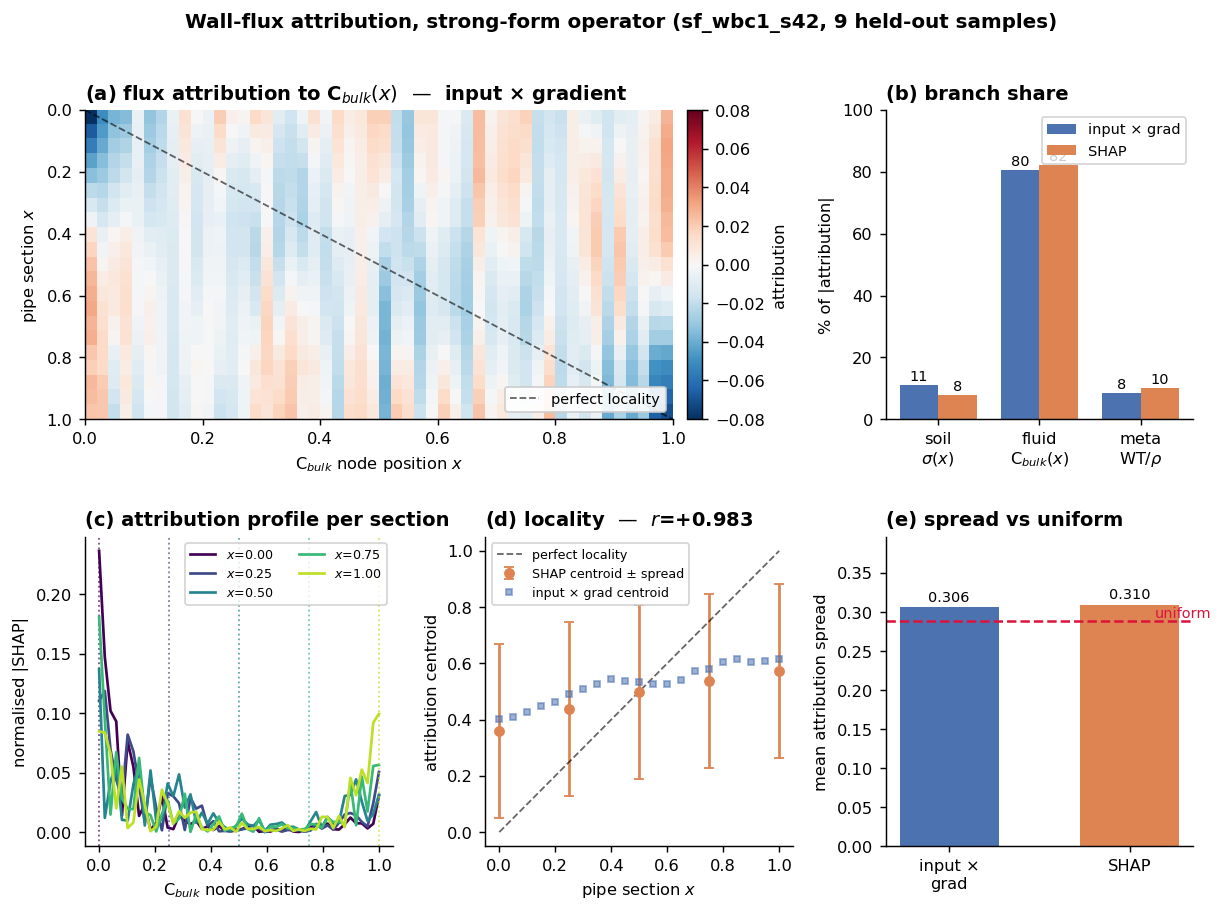

saved xai_figure.png


In [110]:
# =============================================================================
# XAI FIGURES -- sf_wbc1_s42
# Reads xai_sf_wbc1_s42.npz (input x gradient) and shap_sf_wbc1_s42.npz (SHAP).
#
# NOTE ON SIGN: the two runs use different baselines (zero vs background mean),
# which flips the sign of the fluid attributions. FLIP_IG below aligns them for
# the overlay panel only; heatmaps and shares use each run's own values.
# =============================================================================
import numpy as np, matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

ig = np.load("xai_sf_wbc1_s42.npz")
sh = np.load("shap_sf_wbc1_s42.npz")

secs      = sh["sections"]
sec_pos   = sh["sec_pos"]
node_pos  = sh["node_pos"]
S_fluid   = sh["S_fluid"].mean(1)          # [n_sec, 50] avg over samples
A_fluid   = ig["A_fluid"]                  # [Nx, 50]
domain    = node_pos[-1] - node_pos[0]
UNIFORM   = 0.289 * domain

# align sign for the overlay panel only
FLIP_IG = -1.0

plt.rcParams.update({"figure.dpi": 130, "font.size": 9,
                     "axes.spines.top": False, "axes.spines.right": False})
fig = plt.figure(figsize=(11, 7.5))
gs = GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.30)

# ---- (a) heatmap: full input x gradient map, all sections ------------------
ax = fig.add_subplot(gs[0, :2])
v = np.abs(A_fluid).max()
im = ax.imshow(A_fluid, aspect="auto", cmap="RdBu_r", vmin=-v, vmax=v,
               extent=[node_pos[0], node_pos[-1], sec_pos[-1], sec_pos[0]])
ax.plot([node_pos[0], node_pos[-1]], [sec_pos[0], sec_pos[-1]],
        "k--", lw=1, alpha=.6, label="perfect locality")
ax.set_xlabel("C$_{bulk}$ node position $x$")
ax.set_ylabel("pipe section $x$")
ax.set_title("(a) flux attribution to C$_{bulk}(x)$  —  input × gradient",
             loc="left", fontweight="bold")
ax.legend(loc="lower right", fontsize=8, framealpha=.9)
fig.colorbar(im, ax=ax, pad=.02, label="attribution")

# ---- (b) branch shares ----------------------------------------------------
ax = fig.add_subplot(gs[0, 2])
names = ["soil\n$\\sigma(x)$", "fluid\nC$_{bulk}(x)$", "meta\nWT/$\\rho$"]
ig_share = np.array([np.abs(ig["A_soil"]).sum(), np.abs(A_fluid).sum(),
                     np.abs(ig["A_meta"]).sum()])
sh_share = np.array([np.abs(sh["S_soil"]).sum(), np.abs(sh["S_fluid"]).sum(),
                     np.abs(sh["S_meta"]).sum()])
ig_share, sh_share = 100*ig_share/ig_share.sum(), 100*sh_share/sh_share.sum()
w, xpos = 0.38, np.arange(3)
ax.bar(xpos - w/2, ig_share, w, label="input × grad", color="#4C72B0")
ax.bar(xpos + w/2, sh_share, w, label="SHAP", color="#DD8452")
for i, (a, b) in enumerate(zip(ig_share, sh_share)):
    ax.text(i - w/2, a + 1.5, f"{a:.0f}", ha="center", fontsize=8)
    ax.text(i + w/2, b + 1.5, f"{b:.0f}", ha="center", fontsize=8)
ax.set_xticks(xpos); ax.set_xticklabels(names)
ax.set_ylabel("% of |attribution|"); ax.set_ylim(0, 100)
ax.set_title("(b) branch share", loc="left", fontweight="bold")
ax.legend(fontsize=8)

# ---- (c) per-section profiles, SHAP ---------------------------------------
ax = fig.add_subplot(gs[1, 0])
cols = plt.cm.viridis(np.linspace(0, .9, len(secs)))
for k, s in enumerate(secs):
    prof = np.abs(S_fluid[k]); prof = prof / prof.sum()
    ax.plot(node_pos, prof, color=cols[k], lw=1.5,
            label=f"$x$={sec_pos[k]:.2f}")
    ax.axvline(sec_pos[k], color=cols[k], ls=":", lw=1, alpha=.7)
ax.set_xlabel("C$_{bulk}$ node position"); ax.set_ylabel("normalised |SHAP|")
ax.set_title("(c) attribution profile per section", loc="left", fontweight="bold")
ax.legend(fontsize=7, ncol=2)

# ---- (d) locality: centroid vs section ------------------------------------
ax = fig.add_subplot(gs[1, 1])
ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=.6, label="perfect locality")
ax.errorbar(sec_pos, sh["centroid"], yerr=float(sh["spread"]), fmt="o",
            color="#DD8452", capsize=3, ms=5, label="SHAP centroid ± spread")
ax.errorbar(ig["sec_pos"], ig["centroid"], fmt="s", ms=3, alpha=.55,
            color="#4C72B0", label="input × grad centroid")
ax.set_xlabel("pipe section $x$"); ax.set_ylabel("attribution centroid")
ax.set_title(f"(d) locality  —  $r$={float(sh['loc_corr']):+.3f}",
             loc="left", fontweight="bold")
ax.legend(fontsize=7, loc="upper left")

# ---- (e) spread vs uniform ------------------------------------------------
ax = fig.add_subplot(gs[1, 2])
vals = [float(ig["spread"]), float(sh["spread"])]
ax.bar(["input ×\ngrad", "SHAP"], vals, color=["#4C72B0", "#DD8452"], width=.55)
ax.axhline(UNIFORM, color="crimson", ls="--", lw=1.4)
ax.text(1.45, UNIFORM, "uniform", color="crimson", va="bottom",
        ha="right", fontsize=8)
for i, v_ in enumerate(vals):
    ax.text(i, v_ + .008, f"{v_:.3f}", ha="center", fontsize=8)
ax.set_ylabel("mean attribution spread")
ax.set_ylim(0, max(vals + [UNIFORM]) * 1.28)
ax.set_title("(e) spread vs uniform", loc="left", fontweight="bold")

fig.suptitle("Wall-flux attribution, strong-form operator (sf_wbc1_s42, "
             "9 held-out samples)", y=.98, fontsize=11, fontweight="bold")
fig.savefig("xai_figure.png", bbox_inches="tight", dpi=200)
plt.show()
print("saved xai_figure.png")

2026-08-22 06:20:23,281 | INFO | MIONet init | trunk split='late' | trunk params=83,072
  done multiseed_m5/m2_bs64_matched_s42_adam.pt
2026-08-22 06:20:25,916 | INFO | MIONet init | trunk split='late' | trunk params=83,072
  done multiseed_m5/m2_bs64_matched_s43_adam.pt
2026-08-22 06:20:28,489 | INFO | MIONet init | trunk split='late' | trunk params=83,072
  done multiseed_m5/m2_bs64_matched_s44_adam.pt
2026-08-22 06:20:31,230 | INFO | MIONet init | trunk split='late' | trunk params=83,072
  done multiseed_m5/m2_bs64_matched_s45_adam.pt
2026-08-22 06:20:33,764 | INFO | MIONet init | trunk split='late' | trunk params=83,072
  done multiseed_m5/m2_bs64_matched_s46_adam.pt
2026-08-22 06:20:36,312 | INFO | MIONet init | trunk split='late' | trunk params=83,072
  done strong_form/sf_wbc1_s42_adam.pt
2026-08-22 06:20:38,841 | INFO | MIONet init | trunk split='late' | trunk params=83,072
  done strong_form/sf_wbc1_s43_adam.pt

 WEAK vs STRONG ATTRIBUTION -- median [min-max], |attribution| ba

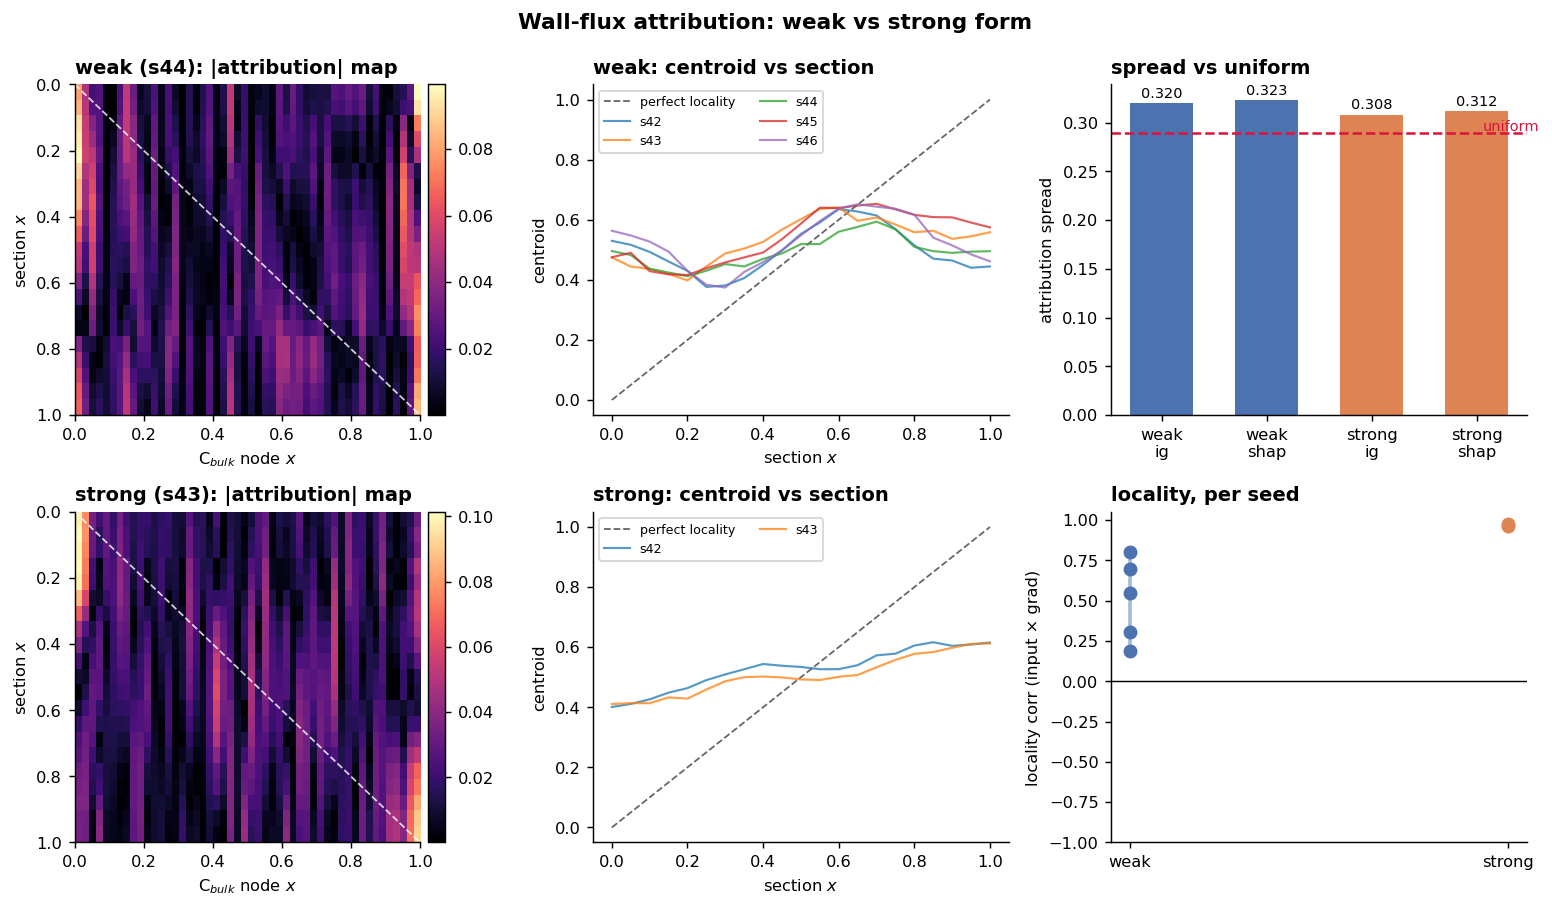

saved xai_compare.png


In [111]:
# =============================================================================
# WEAK vs STRONG ATTRIBUTION COMPARISON
#
# Runs the flux-attribution diagnostic over every available seed of both arms:
#   weak   : multiseed_m5/m2_bs64_matched_s{42..46}_adam.pt   (n=5)
#   strong : strong_form/sf_wbc1_s{42,43}_adam.pt             (n=2)
#
# All comparison metrics are built from |attribution|, so they are invariant to
# the baseline sign flip between input x gradient and SHAP.
#
# Outputs:
#   xai_compare.json  -- machine-readable, per-model + per-arm median/range
#   xai_compare.png   -- figure
#
# Same background and same held-out samples for every model, or the numbers
# are not comparable.
# =============================================================================
import torch, numpy as np, json, os, shap, torch.nn as nn
import matplotlib.pyplot as plt

N_BG, N_EXPLAIN, NSAMPLES = 64, 9, 100
DEV = execution_device
Nx  = len(fdm_x)
dy  = (fdm_y[-1] - fdm_y[-2]).item()
SECTIONS = np.linspace(0, Nx - 1, 5).round().astype(int).tolist()

WEAK   = [f"multiseed_m5/m2_bs64_matched_s{s}_adam.pt" for s in range(42, 47)]
STRONG = [f"strong_form/sf_wbc1_s{s}_adam.pt"          for s in (42, 43)]

node_pos = np.linspace(float(fdm_x[0]), float(fdm_x[-1]), 50)
sec_pos_all = fdm_x.cpu().numpy()
domain  = float(fdm_x[-1] - fdm_x[0])
UNIFORM = 0.2890 * domain

y2 = torch.stack([fdm_y[-2], fdm_y[-1]]).to(DEV)
Xg, Yg = torch.meshgrid(fdm_x.to(DEV), y2, indexing="ij")
_base = torch.stack([Xg.flatten(), 1.0 - Yg.flatten(),
                     torch.ones_like(Xg.flatten())], dim=-1)

bg = [t[:N_BG].to(DEV).float()      for t in dataset_tensors[:3]]
ex = [t[:N_EXPLAIN].to(DEV).float() for t in holdout_tensors[:3]]


class FluxAtSection(nn.Module):
    def __init__(self, model, sec):
        super().__init__(); self.model, self.sec = model, sec

    def forward(self, s_, f_, m_):
        B = s_.shape[0]
        u = self.model(s_, f_, m_, _base.unsqueeze(0).expand(B, Nx * 2, 3))
        C = u[..., 0].view(B, Nx, 2)
        return ((C[:, :, 1] - C[:, :, 0]) / dy)[:, self.sec:self.sec + 1]


def locality(W, positions):
    """W: [n_sec, 50] non-negative. Returns centroid, spread, corr."""
    W = W / W.sum(1, keepdims=True).clip(1e-12)
    cen = W @ node_pos
    spr = float(np.sqrt((W * (node_pos[None, :] - cen[:, None]) ** 2).sum(1)).mean())
    r = float(np.corrcoef(cen, positions)[0, 1]) if len(positions) > 2 else float("nan")
    return cen, spr, r


def analyse(path):
    ck = torch.load(path, map_location="cpu")
    mdl = FactoredMIONet(soil_dim=8, fluid_dim=50, meta_dim=3, split_point="late")
    mdl.load_state_dict(ck["state_dict"]); mdl.to(DEV).eval()

    # ---------- input x gradient, all sections ----------
    s = ex[0].clone().requires_grad_(True)
    f = ex[1].clone().requires_grad_(True)
    m = ex[2].clone().requires_grad_(True)
    u = mdl(s, f, m, _base.unsqueeze(0).expand(N_EXPLAIN, Nx * 2, 3))
    C = u[..., 0].view(N_EXPLAIN, Nx, 2)
    flux = (C[:, :, 1] - C[:, :, 0]) / dy

    A_s = np.zeros((Nx, 8)); A_f = np.zeros((Nx, 50)); A_m = np.zeros((Nx, 3))
    for i in range(Nx):
        gs, gf, gm = torch.autograd.grad(flux[:, i].sum(), (s, f, m),
                                         retain_graph=(i < Nx - 1))
        A_s[i] = (gs * s).mean(0).detach().cpu().numpy()
        A_f[i] = (gf * f).mean(0).detach().cpu().numpy()
        A_m[i] = (gm * m).mean(0).detach().cpu().numpy()

    cen_ig, spr_ig, r_ig = locality(np.abs(A_f), sec_pos_all)
    tot = np.array([np.abs(A_s).sum(), np.abs(A_f).sum(), np.abs(A_m).sum()])
    share_ig = (100 * tot / tot.sum()).tolist()

    # ---------- SHAP on the 5 sections ----------
    S_f = np.zeros((len(SECTIONS), N_EXPLAIN, 50))
    S_s = np.zeros((len(SECTIONS), N_EXPLAIN, 8))
    S_m = np.zeros((len(SECTIONS), N_EXPLAIN, 3))
    for k, sec in enumerate(SECTIONS):
        expl = shap.GradientExplainer(FluxAtSection(mdl, sec).to(DEV).eval(), bg)
        sv = expl.shap_values(ex, nsamples=NSAMPLES)
        sv = [np.asarray(a) for a in (sv[0] if isinstance(sv[0], list) else sv)]
        sv = [a[..., 0] if a.ndim == 3 and a.shape[-1] == 1 else a for a in sv]
        S_s[k], S_f[k], S_m[k] = sv[0], sv[1], sv[2]

    cen_sh, spr_sh, r_sh = locality(np.abs(S_f).mean(1), sec_pos_all[SECTIONS])
    tot = np.array([np.abs(S_s).sum(), np.abs(S_f).sum(), np.abs(S_m).sum()])
    share_sh = (100 * tot / tot.sum()).tolist()

    del mdl; torch.cuda.empty_cache()
    return dict(path=path, seed=int(ck.get("seed", -1)),
                ig=dict(spread=spr_ig, loc_corr=r_ig, share=share_ig),
                shap=dict(spread=spr_sh, loc_corr=r_sh, share=share_sh),
                A_fluid=A_f, S_fluid=np.abs(S_f).mean(1), centroid_ig=cen_ig)


# ---------------- run ----------------
out = {"weak": [], "strong": []}
for arm, paths in [("weak", WEAK), ("strong", STRONG)]:
    for p in paths:
        if not os.path.exists(p):
            print(f"  MISSING {p}"); continue
        out[arm].append(analyse(p))
        print(f"  done {p}")


def summarise(rows, key, field):
    v = [r[key][field] for r in rows]
    return dict(n=len(v), median=float(np.median(v)),
                min=float(np.min(v)), max=float(np.max(v)))


# ---------------- NUMERICAL OUTPUT (parse this) ----------------
report = {"uniform_spread": UNIFORM, "sections": SECTIONS,
          "n_explain": N_EXPLAIN, "nsamples": NSAMPLES, "arms": {}}
print("\n" + "=" * 78)
print(" WEAK vs STRONG ATTRIBUTION -- median [min-max], |attribution| based")
print("=" * 78)
print(f"{'arm':<9}{'n':>3}{'est':>8}{'spread':>22}{'loc_corr':>22}{'fluid%':>10}")
for arm in ("weak", "strong"):
    rows = out[arm]
    if not rows: continue
    report["arms"][arm] = {}
    for est in ("ig", "shap"):
        sp, lc = summarise(rows, est, "spread"), summarise(rows, est, "loc_corr")
        fl = dict(median=float(np.median([r[est]["share"][1] for r in rows])))
        report["arms"][arm][est] = dict(spread=sp, loc_corr=lc, fluid_share=fl)
        print(f"{arm:<9}{len(rows):>3}{est:>8}"
              f"{sp['median']:>10.4f} [{sp['min']:.3f}-{sp['max']:.3f}]"
              f"{lc['median']:>+10.3f} [{lc['min']:+.3f}-{lc['max']:+.3f}]"
              f"{fl['median']:>10.1f}")
print(f"\n uniform-over-domain spread = {UNIFORM:.4f}")
print(" per-seed:")
for arm in ("weak", "strong"):
    for r in out[arm]:
        print(f"   {arm:<7} s{r['seed']}  ig spread {r['ig']['spread']:.4f} "
              f"corr {r['ig']['loc_corr']:+.3f}  |  shap spread {r['shap']['spread']:.4f} "
              f"corr {r['shap']['loc_corr']:+.3f}")

with open("xai_compare.json", "w") as fh:
    json.dump(report, fh, indent=2)
print("\nsaved xai_compare.json")

# ---------------- VISUAL OUTPUT ----------------
plt.rcParams.update({"figure.dpi": 130, "font.size": 9,
                     "axes.spines.top": False, "axes.spines.right": False})
fig, axes = plt.subplots(2, 3, figsize=(12, 7))

med = lambda arm: out[arm][len(out[arm]) // 2]
for j, arm in enumerate(("weak", "strong")):
    if not out[arm]: continue
    r = med(arm)
    ax = axes[j, 0]
    M = np.abs(r["A_fluid"]); M = M / M.sum(1, keepdims=True).clip(1e-12)
    im = ax.imshow(M, aspect="auto", cmap="magma",
                   extent=[node_pos[0], node_pos[-1], sec_pos_all[-1], sec_pos_all[0]])
    ax.plot([0, 1], [0, 1], "w--", lw=1, alpha=.8)
    ax.set_title(f"{arm} (s{r['seed']}): |attribution| map", loc="left",
                 fontweight="bold")
    ax.set_xlabel("C$_{bulk}$ node $x$"); ax.set_ylabel("section $x$")
    fig.colorbar(im, ax=ax, pad=.02)

    ax = axes[j, 1]
    ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=.6, label="perfect locality")
    for rr in out[arm]:
        ax.plot(sec_pos_all, rr["centroid_ig"], lw=1.2, alpha=.75,
                label=f"s{rr['seed']}")
    ax.set_title(f"{arm}: centroid vs section", loc="left", fontweight="bold")
    ax.set_xlabel("section $x$"); ax.set_ylabel("centroid")
    ax.legend(fontsize=7, ncol=2)

ax = axes[0, 2]
labels, vals, cols = [], [], []
for arm, c in (("weak", "#4C72B0"), ("strong", "#DD8452")):
    for est in ("ig", "shap"):
        if not out[arm]: continue
        labels.append(f"{arm}\n{est}")
        vals.append(np.median([r[est]["spread"] for r in out[arm]]))
        cols.append(c)
ax.bar(labels, vals, color=cols, width=.6)
ax.axhline(UNIFORM, color="crimson", ls="--", lw=1.4)
ax.text(len(vals) - .4, UNIFORM, "uniform", color="crimson", va="bottom",
        ha="right", fontsize=8)
for i, v_ in enumerate(vals):
    ax.text(i, v_ + .006, f"{v_:.3f}", ha="center", fontsize=8)
ax.set_ylabel("attribution spread"); ax.set_title("spread vs uniform",
                                                  loc="left", fontweight="bold")

ax = axes[1, 2]
for arm, c in (("weak", "#4C72B0"), ("strong", "#DD8452")):
    if not out[arm]: continue
    v = [r["ig"]["loc_corr"] for r in out[arm]]
    ax.scatter([arm] * len(v), v, color=c, s=45, zorder=3)
    ax.plot([arm, arm], [min(v), max(v)], color=c, lw=2, alpha=.5)
ax.axhline(0, color="k", lw=.8)
ax.set_ylabel("locality corr (input × grad)"); ax.set_ylim(-1, 1.05)
ax.set_title("locality, per seed", loc="left", fontweight="bold")

fig.suptitle("Wall-flux attribution: weak vs strong form", y=.99,
             fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig("xai_compare.png", bbox_inches="tight", dpi=200)
plt.show()
print("saved xai_compare.png")

In [112]:
for arm in ("weak", "strong"):
    for r in out[arm]:
        c = r["centroid_ig"]
        slope = np.polyfit(sec_pos_all, c, 1)[0]
        print(f"{arm} s{r['seed']}: slope {slope:+.3f}  "
              f"centroid range {c.min():.3f}-{c.max():.3f}")

weak s42: slope +0.047  centroid range 0.376-0.635
weak s43: slope +0.163  centroid range 0.398-0.641
weak s44: slope +0.090  centroid range 0.412-0.594
weak s45: slope +0.222  centroid range 0.416-0.653
weak s46: slope +0.084  centroid range 0.374-0.651
strong s42: slope +0.209  centroid range 0.401-0.616
strong s43: slope +0.205  centroid range 0.411-0.612


In [113]:
# =============================================================================
# EXPORT PAYLOAD FOR THE FRONT END
#
# Runs the model once and writes payload.json -- everything the viewer needs.
# No model code ships to the front end; they consume this file.
#
# Conventions matched to validate_pinn_vs_fdm:
#   coords = [x, d, t] with d = 1 - y ; wall at y[-1] (d = 0)
#   flux   = (C[:, :, -1] - C[:, :, -2]) / (y[-1] - y[-2])
# =============================================================================
import torch, numpy as np, json

CKPT     = "strong_form/sf_wbc1_s42_adam.pt"
N_SHOW   = 9          # held-out environments in the ranking plot
FOCUS    = 0          # which environment the field + flux panels show
N_FRAMES = 14         # animation frames over t
DEV      = execution_device

ck = torch.load(CKPT, map_location="cpu")
mdl = FactoredMIONet(soil_dim=8, fluid_dim=50, meta_dim=3, split_point="late")
mdl.load_state_dict(ck["state_dict"]); mdl.to(DEV).eval()

b_soil, b_fluid, b_meta, raw_meta = [t[:N_SHOW].to(DEV) for t in holdout_tensors]
Nx, Ny = len(fdm_x), len(fdm_y)
xs, ys = fdm_x.to(DEV), fdm_y.to(DEV)
dy = (fdm_y[-1] - fdm_y[-2]).item()

X, Y = torch.meshgrid(xs, ys, indexing="ij")
grid = torch.stack([X.flatten(), 1.0 - Y.flatten()], dim=-1)      # [Nx*Ny, 2]

# ---------------- transient field for the focus environment -----------------
ts = np.linspace(0.05, 1.0, N_FRAMES)
frames = []
with torch.no_grad():
    for t in ts:
        c = torch.cat([grid, torch.full_like(grid[:, :1], float(t))], dim=-1)
        u = mdl(b_soil[FOCUS:FOCUS+1], b_fluid[FOCUS:FOCUS+1],
                b_meta[FOCUS:FOCUS+1], c.unsqueeze(0))
        frames.append(u[0, :, 0].view(Nx, Ny).cpu().numpy())
frames = np.stack(frames)                                          # [T, Nx, Ny]

# ---------------- steady state, all environments ----------------------------
coords = torch.cat([grid, torch.ones_like(grid[:, :1])], dim=-1)
coords = coords.unsqueeze(0).expand(N_SHOW, Nx * Ny, 3)
with torch.no_grad():
    u = mdl(b_soil, b_fluid, b_meta, coords)
C_p = u[..., 0].view(N_SHOW, Nx, Ny).cpu()

C_t = fdm_C[:N_SHOW].cpu()
flux_p = ((C_p[:, :, -1] - C_p[:, :, -2]) / dy).numpy()
flux_t = ((C_t[:, :, -1] - C_t[:, :, -2]) / dy).numpy()
cw_p, cw_t = C_p[:, :, -1].numpy(), C_t[:, :, -1].numpy()

flux_err = float(np.mean(np.abs(flux_p - flux_t) /
                         np.clip(np.abs(flux_t), 1e-12, None)))
op_corr  = float(np.corrcoef(cw_p.mean(1), cw_t.mean(1))[0, 1])
C_l2     = float(np.mean(np.linalg.norm((C_p - C_t).flatten(1), axis=1) /
                         np.linalg.norm(C_t.flatten(1), axis=1)))

# ---------------- attribution: whole pipe, three branches -------------------
s = b_soil.clone().requires_grad_(True)
f = b_fluid.clone().requires_grad_(True)
m = b_meta.clone().requires_grad_(True)
y2 = torch.stack([ys[-2], ys[-1]])
Xg, Yg = torch.meshgrid(xs, y2, indexing="ij")
cw = torch.stack([Xg.flatten(), 1.0 - Yg.flatten(),
                  torch.ones_like(Xg.flatten())], dim=-1)
uu = mdl(s, f, m, cw.unsqueeze(0).expand(N_SHOW, Nx * 2, 3))
CC = uu[..., 0].view(N_SHOW, Nx, 2)
total_flux = ((CC[:, :, 1] - CC[:, :, 0]) / dy).mean()
gs, gf, gm = torch.autograd.grad(total_flux, (s, f, m))
share = np.array([(gs * s).abs().sum().item(),
                  (gf * f).abs().sum().item(),
                  (gm * m).abs().sum().item()])
share = (100 * share / share.sum()).tolist()

payload = {
    "checkpoint": CKPT,
    "x": fdm_x.cpu().numpy().tolist(),
    "y": fdm_y.cpu().numpy().tolist(),
    "t": ts.tolist(),
    "focus": int(FOCUS),
    "frames": frames.tolist(),
    "flux_pred": flux_p.tolist(),
    "flux_true": flux_t.tolist(),
    "wall_pred": cw_p.tolist(),
    "wall_true": cw_t.tolist(),
    "ranking": {"pred": cw_p.mean(1).tolist(), "true": cw_t.mean(1).tolist(),
                "wall_thickness": raw_meta[:, 0].cpu().numpy().tolist()},
    "attribution": {"labels": ["Fluid chemistry", "Soil resistivity",
                               "Pipe & site scalars"],
                    "share": [share[1], share[0], share[2]]},
    "metrics": {"flux_err": flux_err, "op_corr": op_corr, "C_l2": C_l2,
                "n_environments": N_SHOW},
    "caveat": ("Research output. The finite-difference reference has unresolved "
               "potential boundary and reaction-kinetics assumptions, so values "
               "are not calibrated corrosion current densities."),
}

with open("payload.json", "w") as fh:
    json.dump(payload, fh)
print(f"saved payload.json  ({len(json.dumps(payload))/1e3:.0f} kB)")
print(f"  flux err {flux_err:.3f} | op_corr {op_corr:+.3f} | C_l2 {C_l2:.3f}")
print(f"  attribution  fluid {share[1]:.1f}%  soil {share[0]:.1f}%  "
      f"scalars {share[2]:.1f}%")

2026-08-22 07:32:56,525 | INFO | MIONet init | trunk split='late' | trunk params=83,072
saved payload.json  (388 kB)
  flux err 0.368 | op_corr -0.026 | C_l2 0.364
  attribution  fluid 73.2%  soil 13.4%  scalars 13.3%


In [114]:
import json, glob
print(len(glob.glob("multiseed_m5/m5_s*_lbfgs100.json")))  # want 6

6


In [121]:
import json, glob, os, statistics as st

RUN_DIR = "multiseed_m5"
ARMS    = ["s42a", "s43a", "s44a", "s45a", "s46a", "s42b"]

# confirm metric key names before comparing
probe = json.load(open(f"{RUN_DIR}/s42a.json"))["lbfgs"]["hold"]
print("available metrics:", list(probe.keys()))
METRICS = [m for m in ["C_l2", "flux_err", "x_corr"] if m in probe]
print("using:", METRICS, "\n")

wins, detail = {"100": 0, "250": 0}, []
print(f"{'arm':<8}{'metric':<11}{'lbfgs250':>12}{'lbfgs100':>12}{'better':>10}")
for tag in ARMS:
    b = f"{RUN_DIR}/{tag}.json"
    l = f"{RUN_DIR}/m5_{tag}_lbfgs100.json"
    if not (os.path.exists(b) and os.path.exists(l)):
        print(f"  {tag}: missing"); continue
    base, l100 = json.load(open(b))["lbfgs"]["hold"], json.load(open(l))["hold"]
    for m in METRICS:
        v250, v100 = base[m], l100[m]
        better = ("100" if v100 > v250 else "250") if m == "x_corr" \
                 else ("100" if v100 < v250 else "250")
        wins[better] += 1
        detail.append({"arm": tag, "metric": m, "lbfgs250": v250,
                       "lbfgs100": v100, "better": better})
        print(f"{tag:<8}{m:<11}{v250:>12.4f}{v100:>12.4f}{better:>10}")

n = sum(wins.values())
print(f"\n100 steps better on {wins['100']}/{n} comparisons")
print("-> claim holds" if wins["100"] == n else
      f"-> does NOT hold as written; {wins['250']} go the other way")

for m in METRICS:
    d = [x for x in detail if x["metric"] == m]
    a, c = [x["lbfgs250"] for x in d], [x["lbfgs100"] for x in d]
    print(f"  {m:<10} 250: {st.median(a):8.4f} [{min(a):.4f}–{max(a):.4f}]"
          f"   100: {st.median(c):8.4f} [{min(c):.4f}–{max(c):.4f}]")

import os, json
os.makedirs("multiseed_m5/compiled", exist_ok=True)
json.dump({"n_arms": len(detail)//max(len(METRICS),1), "wins": wins,
           "comparisons": detail},
          open("multiseed_m5/compiled/paired_lbfgs.json", "w"), indent=2)
print("saved")

available metrics: ['C_l2', 'phi_l2', 'flux_err', 'op_corr', 'x_corr', 'x_var_ratio']
using: ['C_l2', 'flux_err', 'x_corr'] 

arm     metric         lbfgs250    lbfgs100    better
s42a    C_l2             0.2740      0.1224       100
s42a    flux_err         1.4102      0.3661       100
s42a    x_corr           0.1160      0.2644       100
s43a    C_l2             0.3208      0.2369       100
s43a    flux_err         1.6814      1.2551       100
s43a    x_corr           0.1181      0.1572       100
s44a    C_l2             0.3450      0.2329       100
s44a    flux_err         1.8810      1.2930       100
s44a    x_corr           0.1324      0.2107       100
s45a    C_l2             0.3337      0.2329       100
s45a    flux_err         1.8327      1.2502       100
s45a    x_corr           0.1679      0.1784       100
s46a    C_l2             0.3409      0.2204       100
s46a    flux_err         1.8696      1.1384       100
s46a    x_corr           0.0730      0.2770       100
s42b    C_

In [116]:
import glob
for p in sorted(glob.glob("multiseed_m5/*.json")):
    print(p)

multiseed_m5/all_arms.json
multiseed_m5/all_lbfgs100.json
multiseed_m5/all_m2_arms.json
multiseed_m5/all_m2_bs64_full.json
multiseed_m5/m2_bs128_s42.json
multiseed_m5/m2_bs128_s43.json
multiseed_m5/m2_bs128_s44.json
multiseed_m5/m2_bs128_s45.json
multiseed_m5/m2_bs128_s46.json
multiseed_m5/m2_bs64_full_s42.json
multiseed_m5/m2_bs64_full_s43.json
multiseed_m5/m2_bs64_full_s44.json
multiseed_m5/m2_bs64_full_s45.json
multiseed_m5/m2_bs64_full_s46.json
multiseed_m5/m2_bs64_matched_s42.json
multiseed_m5/m2_bs64_matched_s43.json
multiseed_m5/m2_bs64_matched_s44.json
multiseed_m5/m2_bs64_matched_s45.json
multiseed_m5/m2_bs64_matched_s46.json
multiseed_m5/m2_s42a.json
multiseed_m5/m5_s42a_lbfgs100.json
multiseed_m5/m5_s42b_lbfgs100.json
multiseed_m5/m5_s43a_lbfgs100.json
multiseed_m5/m5_s44a_lbfgs100.json
multiseed_m5/m5_s45a_lbfgs100.json
multiseed_m5/m5_s46a_lbfgs100.json
multiseed_m5/s42a.json
multiseed_m5/s42b.json
multiseed_m5/s43a.json
multiseed_m5/s44a.json
multiseed_m5/s45a.json
multis

In [117]:
import json
b = json.load(open("multiseed_m5/s42a.json"))
l = json.load(open("multiseed_m5/m5_s42a_lbfgs100.json"))
print("base keys:", list(b.keys()))
print("  lbfgs:  ", list(b.get("lbfgs", {}).keys()))
print("l100 keys:", list(l.keys()))

base keys: ['tag', 'seed', 'replicate', 'cfg', 'adam', 'lbfgs', 'minutes']
  lbfgs:   ['hold', 'train', 'weak', 'share']
l100 keys: ['hold', 'train', 'weak', 'share', 'tag', 'seed', 'n_modes', 'minutes']


In [122]:
import json, torch
a = json.load(open("multiseed_m5/s42a.json"))
b = json.load(open("multiseed_m5/s42b.json"))
print(a["cfg"] == b["cfg"], a["minutes"], b["minutes"])
print(a["adam"]["hold"]["C_l2"], b["adam"]["hold"]["C_l2"])

sa = torch.load("multiseed_m5/m5_s42a_adam.pt", map_location="cpu")["state_dict"]
sb = torch.load("multiseed_m5/m5_s42b_adam.pt", map_location="cpu")["state_dict"]
print("weights identical:", all(torch.equal(sa[k], sb[k]) for k in sa))

True 9.2 9.2
0.11532863229513168 0.11532863229513168
weights identical: True


In [123]:
# =============================================================================
# TRUE REPLICATE — seed 42 at the m5 config, retrained from scratch
#
# s42b turned out to be a byte-copy of s42a (identical weights, identical
# 9.2 min runtime), so the replicate comparison in §9 was never actually run.
# This does it properly: same seed, same config, fresh training, then diffs the
# weights against the stored s42a checkpoint.
#
# Two outcomes, both usable:
#   IDENTICAL -> training is deterministic at fixed seed. Within-seed variance
#                is zero, and the spread across 42-46 is genuine seed
#                sensitivity. §9 says that instead.
#   DIFFERENT -> real run-to-run variance exists. Report the magnitude against
#                the across-seed spread; the original framing returns.
#
# ~9-10 minutes. Requires TE to be the modes=5 space (the m5 config).
# =============================================================================
import torch, copy, time, json, os, statistics as st

SEED = 42
TAG  = "s42c"                    # NOT s42b -- that name is burned
RUN_DIR = "multiseed_m5"
REF = f"{RUN_DIR}/m5_s42a_adam.pt"

# ---- confirm we are in the right test space before spending 10 minutes ----
assert TE[0].shape[0] == 72, (
    f"TE has {TE[0].shape[0]} test functions, expected 72 for modes=5. "
    "Restore the m5 test space before running.")
print(f"TE ok: {tuple(TE[0].shape)}")
print("cfg:", {k: CFG[k] for k in ['n_modes','epochs_a','epochs_c','lr',
                                   'batch_size','split']})

t0 = time.time()
flush(); torch.cuda.reset_peak_memory_stats()

# ---- identical construction path to the original loop ----
torch.manual_seed(SEED)
model_rep = FactoredMIONet(soil_dim=8, fluid_dim=50, meta_dim=3,
                           split_point=CFG["split"])
model_rep = train_vmionet_curriculum(
    model=model_rep, data_tensors=dataset_tensors, quad_engine=quad_tensors,
    test_engine=TE, phys_params=PHYSICS_PARAMS,
    epochs_a=CFG["epochs_a"], epochs_c=CFG["epochs_c"],
    lr=CFG["lr"], batch_size=CFG["batch_size"],
    device=execution_device, w_res_phi=W_RES_PHI)
mins = (time.time() - t0) / 60
flush()

torch.save({"state_dict": model_rep.state_dict(), "seed": SEED,
            "replicate": "c", "phase": "adam", "cfg": CFG},
           f"{RUN_DIR}/m5_{TAG}_adam.pt")

# ---- weight diff against s42a ----
ref = torch.load(REF, map_location="cpu")["state_dict"]
new = {k: v.cpu() for k, v in model_rep.state_dict().items()}

identical = all(torch.equal(ref[k], new[k]) for k in ref)
max_abs = max((ref[k] - new[k]).abs().max().item() for k in ref)
rel = (sum(((ref[k] - new[k]) ** 2).sum() for k in ref).sqrt() /
       sum((ref[k] ** 2).sum() for k in ref).sqrt()).item()

print("\n" + "=" * 64)
print(f" REPLICATE vs s42a  |  {mins:.1f} min (original logged 9.2)")
print("=" * 64)
print(f"  weights bit-identical : {identical}")
print(f"  max |Δw|              : {max_abs:.3e}")
print(f"  relative L2 on weights: {rel:.3e}")

# ---- metrics, same evaluator as every other arm ----
rec = evaluate(model_rep, SEED, "c", "adam")
a = json.load(open(f"{RUN_DIR}/s42a.json"))["adam"]["hold"]

print(f"\n{'metric':<14}{'s42a':>12}{'s42c':>12}{'|diff|':>12}")
diffs = {}
for m in ["C_l2", "flux_err", "x_corr", "op_corr"]:
    d = abs(a[m] - rec["hold"][m]); diffs[m] = d
    print(f"{m:<14}{a[m]:>12.4f}{rec['hold'][m]:>12.4f}{d:>12.4f}")

# ---- the number §9 actually needs ----
try:
    arms = ["s42a", "s43a", "s44a", "s45a", "s46a"]
    across = {m: [json.load(open(f"{RUN_DIR}/{t}.json"))["adam"]["hold"][m]
                  for t in arms] for m in diffs}
    print(f"\n{'metric':<14}{'repl diff':>12}{'across-seed':>14}{'ratio':>10}")
    for m in diffs:
        spread = max(across[m]) - min(across[m])
        r = spread / diffs[m] if diffs[m] > 1e-12 else float("inf")
        print(f"{m:<14}{diffs[m]:>12.4f}{spread:>14.4f}{r:>10.1f}")
    print("\n  ratio -> inf  : training is deterministic; all spread is seed choice")
    print("  ratio near 1  : seeding buys nothing, the variance is the run")
    print("  ratio large   : seeds matter more than reruns -- report both")
except Exception as e:
    print(f"\n(across-seed comparison skipped: {e})")

os.makedirs(f"{RUN_DIR}/compiled", exist_ok=True)
json.dump({"tag": TAG, "seed": SEED, "minutes": mins,
           "weights_identical": bool(identical), "max_abs_dw": max_abs,
           "rel_l2_weights": rel, "hold": rec["hold"], "s42a_hold": a,
           "abs_diffs": diffs},
          open(f"{RUN_DIR}/compiled/replicate_s42.json", "w"), indent=2)
print(f"\nsaved replicate_s42.json  ({mins:.1f} min)")

TE ok: (72, 288)
cfg: {'n_modes': 5, 'epochs_a': 200, 'epochs_c': 600, 'lr': 0.0001, 'batch_size': 64, 'split': 'late'}
2026-08-31 15:52:15,411 | INFO | MIONet init | trunk split='late' | trunk params=83,072
2026-08-31 15:52:15,417 | INFO | Static weights: bounds=1.000e+02  ends_C=1.000e+00  ends_phi=1.000e+00  ic_C=1.000e+00  res_C=1.000e+01  res_phi=1.000e+00
2026-08-31 15:52:15,417 | INFO |   W_ANCHOR=1.000e+00 | W_SMOOTH=2.000e+00
2026-08-31 15:52:15,417 | INFO | Starting Factored Loop: Phase A (200 EPs) -> Phase C (600 EPs)...
2026-08-31 15:52:16,110 | INFO | Epoch 0001/800 [A (Mass)] | LR: 1.00e-04 | Total: 6.754e+00 | res_C: 3.606e-02 | res_phi: 1.738e-01
2026-08-31 15:53:19,957 | INFO | Epoch 0100/800 [A (Mass)] | LR: 5.05e-05 | Total: 1.155e+00 | res_C: 1.336e-03 | res_phi: 4.012e-01
2026-08-31 15:54:24,301 | INFO | Epoch 0200/800 [A (Mass)] | LR: 1.00e-06 | Total: 9.717e-01 | res_C: 1.303e-03 | res_phi: 6.215e-01
2026-08-31 15:54:24,302 | INFO | --- PHASE TRANSITION: Resettin

KeyError: 'op_corr'

In [124]:
print("W_ANCHOR before launch:", W_ANCHOR)

W_ANCHOR before launch: 1.0


In [125]:
# =============================================================================
# STRONG-FORM SEED EXTENSION  —  n=2 → n=5, plus the batch-matched control
#
# Three blocks, run in this order:
#   A. sf_wbc1  seeds 44,45,46          -> anchored strong arm to n=5
#   B. sa_wbc1_noanchor seeds 44,45,46  -> unanchored arm to n=5  (THE HEADLINE)
#   C. sf_wbc1_bs64 seed 42             -> kills the batch-mismatch confound
#
# Resumable: existing JSON is skipped, orphaned *_adam.pt is reloaded without
# retraining. Safe to interrupt and rerun.
#
# Budget ~14 min/run at bs=32 (matches the logged sa_* times), so ~1h40 for A+B
# plus one bs=64 run. Watch the 20 GB MIG ceiling on block C.
#
# Training is bit-reproducible at fixed seed (verified: s42a vs s42c, max|dw|=0),
# so these new seeds measure seed sensitivity cleanly, not run noise.
# =============================================================================
import json, os, time, statistics as st, torch

NEW_SEEDS = [44, 45, 46]
EP_A, EP_C = 82, 246
W_BC = 1.0
SF_DIR, SA_DIR = "strong_form", "strong_anchor_ablation"
os.makedirs(SF_DIR, exist_ok=True); os.makedirs(SA_DIR, exist_ok=True)


def _fresh():
    return FactoredMIONet(soil_dim=8, fluid_dim=50, meta_dim=3,
                          split_point="late").to(execution_device)


def strong_arm(tag, seed, jdir, bs, w_anchor, extra_cfg=None):
    """One strong-form arm. Identical to the original loops except for bs and
    the W_ANCHOR override, both of which are logged into the record."""
    jpth = f"{jdir}/{tag}.json"
    apth = f"{jdir}/{tag}_adam.pt"
    if os.path.exists(jpth):
        print(f"skip {tag} (json exists)")
        return json.load(open(jpth))

    steps_per_ep = 700 // bs + 1
    cfg = dict(form="strong", w_bc=W_BC, w_anchor=w_anchor, epochs_a=EP_A,
               epochs_c=EP_C, lr=1e-4, batch_size=bs, split="late", lbfgs=False,
               grad_steps=(EP_A + EP_C) * steps_per_ep, **(extra_cfg or {}))

    t0 = time.time()
    print("\n" + "#" * 62)
    print(f"#  {tag}  |  W_BC={W_BC}  |  W_ANCHOR={w_anchor}  |  bs={bs}")
    print("#" * 62)
    flush(); torch.cuda.reset_peak_memory_stats()

    if os.path.exists(apth):
        print(f"  reusing {os.path.basename(apth)} (training already done)")
        m = _fresh(); m.load_state_dict(torch.load(apth, map_location="cpu")["state_dict"])
    else:
        torch.manual_seed(seed)
        m = train_strong_curriculum(
            model=_fresh(), data_tensors=dataset_tensors, quad_engine=quad_tensors,
            phys_params=PHYSICS_PARAMS, epochs_a=EP_A, epochs_c=EP_C,
            lr=1e-4, batch_size=bs, device=execution_device,
            w_res_phi=1.0, w_bc=W_BC)
        vram("post-adam")
        torch.save({"state_dict": m.state_dict(), "seed": seed, "cfg": cfg,
                    "w_anchor": w_anchor, "phase": "adam"}, apth)
    flush()

    print(f"\n--- {tag} | HELD-OUT ---")
    hold = validate_pinn_vs_fdm(m, holdout_tensors, fdm_C_ho, fdm_phi_ho,
                                fdm_x, fdm_y, execution_device, n_samples=N_HOLD)
    flush()

    # strong-form objective at the SAME checkpoint as the metrics, 5 draws
    acc = {k: [] for k in ["res_C", "res_phi", "bc_C", "bc_phi"]}
    bb = [t[:bs].to(execution_device) for t in dataset_tensors]
    qq = [t.to(execution_device) for t in quad_tensors]
    for _ in range(5):
        rC, rP, bC, bP, _, _ = compute_strong_loss_split(
            m, bb, qq, PHYSICS_PARAMS, N_t=5, device=execution_device)
        for k, v in zip(acc, (rC, rP, bC, bP)): acc[k].append(float(v.item()))
        del rC, rP, bC, bP
        m.zero_grad(set_to_none=True); flush()
    obj = {k: st.median(v) for k, v in acc.items()}
    obj["strong_total"] = W_RES_C * obj["res_C"] + W_BC * obj["bc_C"]
    vram("eval")
    del m, bb, qq; flush()

    rec = {"tag": tag, "w_bc": W_BC, "w_anchor": w_anchor, "seed": seed,
           "cfg": cfg,
           "adam": {"hold": {k: float(hold[k]) for k in METRICS}, "obj": obj},
           "minutes": round((time.time() - t0) / 60, 1)}
    json.dump(rec, open(jpth, "w"), indent=2)
    print(f"\n{tag} done in {rec['minutes']} min")
    flush()
    return rec


# ============ A. anchored strong arm, seeds 44-46 ============
print("=" * 62 + "\n BLOCK A — sf_wbc1, seeds 44-46 (anchored)\n" + "=" * 62)
for s in NEW_SEEDS:
    strong_arm(f"sf_wbc{int(W_BC)}_s{s}", s, SF_DIR, bs=32, w_anchor=W_ANCHOR)

# ============ B. unanchored strong arm, seeds 44-46 ============
print("\n" + "=" * 62 + "\n BLOCK B — sa_wbc1_noanchor, seeds 44-46 (HEADLINE)\n" + "=" * 62)
_W_SAVED = W_ANCHOR
try:
    W_ANCHOR = 0.0
    print(f"W_ANCHOR set to {W_ANCHOR} (was {_W_SAVED})")
    for s in NEW_SEEDS:
        strong_arm(f"sa_wbc1_noanchor_s{s}", s, SA_DIR, bs=32, w_anchor=0.0)
finally:
    W_ANCHOR = _W_SAVED
    print(f"W_ANCHOR restored to {W_ANCHOR}")


# ============ report ============
def collect(d, pat):
    out = []
    for p in sorted(os.listdir(d)):
        if p.startswith(pat) and p.endswith(".json") and "all_" not in p:
            out.append(json.load(open(f"{d}/{p}")))
    return out


def row(name, rows):
    if not rows: return
    md = lambda k: st.median([r["adam"]["hold"][k] for k in [k]
                              for r in rows])
    vals = {k: [r["adam"]["hold"][k] for r in rows] for k in
            ["C_l2", "flux_err", "x_corr", "op_corr"]}
    print(f"{name:<26}{len(rows):>3}", end="")
    for k in ["C_l2", "flux_err", "x_corr", "op_corr"]:
        v = vals[k]
        print(f"{st.median(v):>9.4f} [{min(v):.3f}-{max(v):.3f}]", end="")
    print()


anch = [r for r in collect(SF_DIR, "sf_wbc1_s")]
noan = [r for r in collect(SA_DIR, "sa_wbc1_noanchor_s")]

print("\n" + "=" * 108)
print(" STRONG-FORM ARMS — held-out, median [min-max]")
print("=" * 108)
print(f"{'arm':<26}{'n':>3}{'C_l2':>21}{'flux_err':>21}{'x_corr':>21}{'op_corr':>21}")
row("strong anchored", anch)
row("strong NO anchor", noan)

json.dump({"anchored": anch, "noanchor": noan},
          open(f"{SF_DIR}/all_strong_extended.json", "w"), indent=2)
print("\nsaved all_strong_extended.json")
print("\n§4 table and Limitations both need updating once this completes.")

 BLOCK A — sf_wbc1, seeds 44-46 (anchored)

##############################################################
#  sf_wbc1_s44  |  W_BC=1.0  |  W_ANCHOR=1.0  |  bs=32
##############################################################
2026-08-31 16:07:46,958 | INFO | MIONet init | trunk split='late' | trunk params=83,072
2026-08-31 16:07:46,960 | INFO | STRONG form | W_BC=1.000e+00 | res_C=1.000e+01 res_phi=1.000e+00 bounds=1.000e+02 ic_C=1.000e+00 ends_C=1.000e+00 ends_phi=1.000e+00 ANCHOR=1.000e+00 SMOOTH=2.000e+00
2026-08-31 16:07:46,960 | INFO | Strong Loop: Phase A (82) -> Phase C (246)...
2026-08-31 16:07:49,643 | INFO | Epoch 0001/328 [A (Mass)] | LR: 1.00e-04 | Total: 2.897e+00 | res_C: 1.316e-03 | res_phi: 8.276e+00 | bc_C: 2.408e-01
2026-08-31 16:11:21,111 | INFO | --- PHASE TRANSITION: Resetting LR for Coupled Physics ---
2026-08-31 16:12:08,222 | INFO | Epoch 0100/328 [C (Coupled)] | LR: 9.87e-05 | Total: 1.713e+00 | res_C: 2.184e-04 | res_phi: 5.860e-02 | bc_C: 1.033e-01
2026-08-31 

KeyError: 'op_corr'

In [128]:
import json, os, time, statistics as st, torch

NEW_SEEDS = [44, 45, 46]
EP_A, EP_C = 82, 246
W_BC = 1.0
SF_DIR, SA_DIR = "strong_form", "strong_anchor_ablation"
os.makedirs(SF_DIR, exist_ok=True); os.makedirs(SA_DIR, exist_ok=True)

# ============ report ============
def collect(d, pat):
    out = []
    for p in sorted(os.listdir(d)):
        if p.startswith(pat) and p.endswith(".json") and "all_" not in p:
            out.append(json.load(open(f"{d}/{p}")))
    return out


def row(name, rows):
    if not rows: return
    keys = [k for k in ["C_l2","flux_err","x_corr","op_corr"]
            if all(k in r["adam"]["hold"] for r in rows)]
    print(f"{name:<26}{len(rows):>3}", end="")
    for k in keys:
        v = [r["adam"]["hold"][k] for r in rows]
        print(f"{k}: {st.median(v):.4f} [{min(v):.3f}-{max(v):.3f}]  ", end="")
    print()


anch = [r for r in collect(SF_DIR, "sf_wbc1_s")]
noan = [r for r in collect(SA_DIR, "sa_wbc1_noanchor_s")]

print("\n" + "=" * 108)
print(" STRONG-FORM ARMS — held-out, median [min-max]")
print("=" * 108)
print(f"{'arm':<26}{'n':>3}{'C_l2':>21}{'flux_err':>21}{'x_corr':>21}{'op_corr':>21}")
row("strong anchored", anch)
row("strong NO anchor", noan)

json.dump({"anchored": anch, "noanchor": noan},
          open(f"{SF_DIR}/all_strong_extended.json", "w"), indent=2)


 STRONG-FORM ARMS — held-out, median [min-max]
arm                         n                 C_l2             flux_err               x_corr              op_corr
strong anchored             5C_l2: 0.1251 [0.114-0.141]  flux_err: 0.0679 [0.063-0.074]  x_corr: 0.6036 [0.552-0.723]  


KeyError: 'adam'

In [130]:
KEYS = ["C_l2","phi_l2","flux_err","op_corr","x_corr","x_var_ratio"]
for d, pat in [("strong_form","sf_wbc1_s"), ("strong_anchor_ablation","sa_wbc1_noanchor_s")]:
    for f in sorted(os.listdir(d)):
        if not (f.startswith(pat) and f.endswith(".json")): continue
        if f.startswith("all_"): continue
        rec = json.load(open(f"{d}/{f}"))
        if not isinstance(rec, dict) or "adam" not in rec:
            print("skip", f, "(not a single record)"); continue
        ckpt = f"{d}/{f[:-5]}_adam.pt"
        if not os.path.exists(ckpt):
            print("skip", f, "(no checkpoint)"); continue
        ck = torch.load(ckpt, map_location="cpu")
        m = FactoredMIONet(soil_dim=8, fluid_dim=50, meta_dim=3, split_point="late")
        m.load_state_dict(ck["state_dict"]); m.to(execution_device).eval()
        h = validate_pinn_vs_fdm(m, holdout_tensors, fdm_C_ho, fdm_phi_ho,
                                 fdm_x, fdm_y, execution_device, n_samples=N_HOLD)
        rec["adam"]["hold"] = {k: float(h[k]) for k in KEYS if k in h}
        json.dump(rec, open(f"{d}/{f}","w"), indent=2)
        del m; flush()
        print(f, "->", list(rec["adam"]["hold"]))

2026-08-31 18:41:01,674 | INFO | MIONet init | trunk split='late' | trunk params=83,072

 PINN vs FDM (x-varying sigma, t=1.0)
  C   rel L2 : mean 1.1358e-01   worst 3.8551e-01
  phi rel L2 : mean 3.2739e-01   worst 6.8119e-01
  wall flux  : mean 6.34%   worst 20.00%

  ACROSS samples : spread 93.2% (true 127.2%)  corr +0.902
  ALONG x        : var 0.08522 (true 0.05965, 143%)  corr +0.552

    WT       C L2   flux err  C_wall pred  C_wall true
 0.273 1.3931e-01     12.05%     0.225799     0.273543
 0.375 5.9501e-02      5.02%     0.181252     0.172046
 0.450 1.1432e-01      7.46%     0.179777     0.194438
 0.528 8.4506e-02      6.45%     0.197625     0.182144
 0.611 9.5390e-02      4.91%     0.141966     0.132773
 0.657 6.4280e-02      5.30%     0.140688     0.152349
 0.737 6.9567e-02      3.47%     0.175784     0.160811
 0.878 9.5886e-02      4.66%     0.096448     0.098467
 0.974 1.3281e-01      5.64%     0.082341     0.102505
sf_wbc1_s42.json -> ['C_l2', 'phi_l2', 'flux_err', 'op_c

In [132]:
# =============================================================================
# WRAP-UP BLOCK
#   1. Anchor share re-measure on m2_bs64_matched, n=5   (unblocks §6)
#   2. Recompute m5 tables at n=5                        (s42b was a copy of s42a)
#   3. Zip everything for download
#
# No training. A few minutes total.
# =============================================================================
import torch, statistics as st, json, os, glob, subprocess, datetime

RUN_DIR = "multiseed_m5"
os.makedirs(f"{RUN_DIR}/compiled", exist_ok=True)

# =============================================================================
# 1. ANCHOR SHARE — n=5 on an arm that is actually in the paper
#
# Prior 80–86% came from 5 draws on two pre-multiseed checkpoints and quoted the
# top of one distribution (true ranges: 40–86% and 49–75%).
#
# CRITICAL: anchor_share reads module-level TE. These checkpoints are modes=2.
# =============================================================================
print("=" * 66 + "\n 1. ANCHOR SHARE RE-MEASURE\n" + "=" * 66)
assert abs(float(W_ANCHOR) - 1.0) < 1e-12, (
    f"W_ANCHOR is {W_ANCHOR}, expected 1.0 — the share is conditioned on it")
print(f"W_ANCHOR={W_ANCHOR}  W_RES_C={W_RES_C}  W_RES_PHI={W_RES_PHI}  "
      f"b_eval={CFG['b_eval']}")

V_S2, GRAD_V_S2 = generate_true_hp_test_functions(PTS_SPACE, D_EDGES, num_modes_x=2)
V_W2, _ = generate_true_hp_test_functions(
    torch.cat([PTS_WALL_X, torch.zeros_like(PTS_WALL_X)], dim=-1),
    D_EDGES, num_modes_x=2)
MASK2 = torch.zeros(V_S2.shape[0], dtype=torch.bool)
MASK2[[m * NUM_HATS for m in range(3)]] = True
assert V_W2[MASK2].abs().sum() > 0 and V_W2[~MASK2].abs().sum() == 0
assert V_S2.shape[0] == 36, f"expected 36 test functions, got {V_S2.shape[0]}"
TE_M2 = (V_S2, GRAD_V_S2, V_W2, MASK2)
print(f"TE_M2 rebuilt: {tuple(V_S2.shape)} "
      f"({V_S2.shape[0]//NUM_HATS} modes x {NUM_HATS} hats)\n")

_TE_SAVED, TE = TE, TE_M2
share_rows = []
try:
    for s in [42, 43, 44, 45, 46]:
        p = f"{RUN_DIR}/m2_bs64_matched_s{s}_adam.pt"
        if not os.path.exists(p):
            print(f"  MISSING {p}"); continue
        m = FactoredMIONet(soil_dim=8, fluid_dim=50, meta_dim=3, split_point="late")
        m.load_state_dict(torch.load(p, map_location="cpu")["state_dict"])
        m.to(execution_device).eval()
        sh = anchor_share(m, CFG["b_eval"], draws=5)
        share_rows.append({"seed": s, **sh})
        print(f"  s{s}:  ANCHOR {sh['ANCHOR']:5.1f}%   weak {sh['weak']:5.1f}%")
        del m; flush()
finally:
    TE = _TE_SAVED

if share_rows:
    a = [r["ANCHOR"] for r in share_rows]
    w = [r["weak"] for r in share_rows]
    print(f"\n  ANCHOR  median {st.median(a):5.1f}%  [{min(a):.1f}–{max(a):.1f}]")
    print(f"  weak    median {st.median(w):5.1f}%  [{min(w):.1f}–{max(w):.1f}]")
    print(f"\n  §6: anchor contributes a median {st.median(a):.0f}% of gradient "
          f"norm\n      (range {min(a):.0f}–{max(a):.0f}%, n={len(share_rows)}) "
          f"at W_ANCHOR={W_ANCHOR}.")
    json.dump({"tag": "m2_bs64_matched", "n": len(share_rows), "draws": 5,
               "W_ANCHOR": float(W_ANCHOR), "W_RES_C": float(W_RES_C),
               "W_RES_PHI": float(W_RES_PHI), "b_eval": CFG["b_eval"],
               "n_test_functions": int(V_S2.shape[0]), "per_seed": share_rows,
               "anchor": {"median": st.median(a), "min": min(a), "max": max(a)},
               "weak": {"median": st.median(w), "min": min(w), "max": max(w)}},
              open(f"{RUN_DIR}/compiled/anchor_share_m2.json", "w"), indent=2)
    print("\n  saved compiled/anchor_share_m2.json")

# =============================================================================
# 2. m5 RECOMPUTE AT n=5
#
# s42b is a byte-copy of s42a (identical weights, identical 9.2 min runtime).
# Every m5 median currently double-counts seed 42.
# =============================================================================
print("\n" + "=" * 66 + "\n 2. m5 TABLES AT n=5 (s42b excluded)\n" + "=" * 66)
ARMS5 = ["s42a", "s43a", "s44a", "s45a", "s46a"]
METRICS5 = ["C_l2", "flux_err", "x_corr"]

def stat(vals):
    return {"median": st.median(vals), "min": min(vals), "max": max(vals)}

m5 = {}
for phase in ["adam", "lbfgs"]:
    rows = []
    for t in ARMS5:
        p = f"{RUN_DIR}/{t}.json"
        if os.path.exists(p):
            r = json.load(open(p))
            if phase in r: rows.append(r[phase]["hold"])
    if not rows: continue
    m5[phase] = {k: stat([r[k] for r in rows]) for k in METRICS5 if k in rows[0]}
    print(f"\n {phase.upper()}  n={len(rows)}")
    for k, v in m5[phase].items():
        print(f"   {k:<10} {v['median']:8.4f}  [{v['min']:.4f}–{v['max']:.4f}]")

# paired L-BFGS, five independent arms
print("\n PAIRED L-BFGS (100 vs 250), five arms")
wins, pairs = {"100": 0, "250": 0}, []
for t in ARMS5:
    b, l = f"{RUN_DIR}/{t}.json", f"{RUN_DIR}/m5_{t}_lbfgs100.json"
    if not (os.path.exists(b) and os.path.exists(l)): continue
    v250, v100 = json.load(open(b))["lbfgs"]["hold"], json.load(open(l))["hold"]
    for k in METRICS5:
        better = ("100" if v100[k] > v250[k] else "250") if k == "x_corr" \
                 else ("100" if v100[k] < v250[k] else "250")
        wins[better] += 1
        pairs.append({"arm": t, "metric": k, "lbfgs250": v250[k],
                      "lbfgs100": v100[k], "better": better})
n = sum(wins.values())
print(f"   100 better on {wins['100']}/{n} comparisons "
      f"({len(ARMS5)} arms x {len(METRICS5)} metrics)")
for k in METRICS5:
    d = [x for x in pairs if x["metric"] == k]
    if not d: continue
    x, y = [i["lbfgs250"] for i in d], [i["lbfgs100"] for i in d]
    print(f"   {k:<10} 250: {st.median(x):7.4f} [{min(x):.4f}–{max(x):.4f}]"
          f"   100: {st.median(y):7.4f} [{min(y):.4f}–{max(y):.4f}]")

json.dump({"n": len(ARMS5), "arms": ARMS5, "arm_stats": m5,
           "paired_lbfgs": {"wins": wins, "comparisons": pairs},
           "note": "s42b excluded — byte-identical copy of s42a"},
          open(f"{RUN_DIR}/compiled/m5_n5.json", "w"), indent=2)
print("\n  saved compiled/m5_n5.json")

# =============================================================================
# 3. PACKAGE
# =============================================================================
import zipfile, glob, os, datetime
stamp = datetime.datetime.now().strftime("%m%d_%H%M")
pats_json = ["multiseed_m5/*.json", "multiseed_m5/compiled/*.json",
             "strong_form/*.json", "strong_anchor_ablation/*.json"]
pats_ckpt = ["multiseed_m5/*.pt", "strong_form/*.pt", "strong_anchor_ablation/*.pt"]
fj = [f for p in pats_json for f in glob.glob(p)]
fc = [f for p in pats_ckpt for f in glob.glob(p)]

def pack(name, files):
    with zipfile.ZipFile(name, "w", zipfile.ZIP_DEFLATED) as z:
        for f in files: z.write(f)
    return os.path.getsize(name)/1e6

print(f"RESULTS_{stamp}.zip  {len(fj):>3} files  {pack(f'RESULTS_{stamp}.zip', fj):6.1f} MB")
print(f"FULL_{stamp}.zip     {len(fj)+len(fc):>3} files  {pack(f'FULL_{stamp}.zip', fj+fc):6.1f} MB")

 1. ANCHOR SHARE RE-MEASURE
W_ANCHOR=1.0  W_RES_C=10.0  W_RES_PHI=1.0  b_eval=64
TE_M2 rebuilt: (36, 288) (3 modes x 12 hats)

2026-08-31 18:49:48,413 | INFO | MIONet init | trunk split='late' | trunk params=83,072
  s42:  ANCHOR  62.6%   weak  10.4%
2026-08-31 18:49:49,833 | INFO | MIONet init | trunk split='late' | trunk params=83,072
  s43:  ANCHOR  44.5%   weak  19.2%
2026-08-31 18:49:51,229 | INFO | MIONet init | trunk split='late' | trunk params=83,072
  s44:  ANCHOR  50.9%   weak  15.5%
2026-08-31 18:49:52,608 | INFO | MIONet init | trunk split='late' | trunk params=83,072
  s45:  ANCHOR  49.9%   weak  19.9%
2026-08-31 18:49:54,003 | INFO | MIONet init | trunk split='late' | trunk params=83,072
  s46:  ANCHOR  55.7%   weak  16.2%

  ANCHOR  median  50.9%  [44.5–62.6]
  weak    median  16.2%  [10.4–19.9]

  §6: anchor contributes a median 51% of gradient norm
      (range 44–63%, n=5) at W_ANCHOR=1.0.

  saved compiled/anchor_share_m2.json

 2. m5 TABLES AT n=5 (s42b excluded)

 

In [133]:
for D in [5, 20, 50]:
    vals = []
    for _ in range(3):
        m = FactoredMIONet(soil_dim=8, fluid_dim=50, meta_dim=3, split_point="late")
        m.load_state_dict(torch.load(f"{RUN_DIR}/m2_bs64_matched_s42_adam.pt",
                                     map_location="cpu")["state_dict"])
        m.to(execution_device).eval()
        vals.append(anchor_share(m, CFG["b_eval"], draws=D)["ANCHOR"])
        del m; flush()
    print(f"draws={D:>3}: {[f'{v:.1f}' for v in vals]}  spread {max(vals)-min(vals):.1f}")

2026-08-31 18:51:31,003 | INFO | MIONet init | trunk split='late' | trunk params=83,072
2026-08-31 18:51:32,399 | INFO | MIONet init | trunk split='late' | trunk params=83,072
2026-08-31 18:51:33,785 | INFO | MIONet init | trunk split='late' | trunk params=83,072
draws=  5: ['70.0', '75.2', '66.7']  spread 8.5
2026-08-31 18:51:35,160 | INFO | MIONet init | trunk split='late' | trunk params=83,072
2026-08-31 18:51:40,109 | INFO | MIONet init | trunk split='late' | trunk params=83,072
2026-08-31 18:51:45,059 | INFO | MIONet init | trunk split='late' | trunk params=83,072
draws= 20: ['73.4', '70.9', '74.8']  spread 3.8
2026-08-31 18:51:50,233 | INFO | MIONet init | trunk split='late' | trunk params=83,072
2026-08-31 18:52:02,508 | INFO | MIONet init | trunk split='late' | trunk params=83,072
2026-08-31 18:52:17,826 | INFO | MIONet init | trunk split='late' | trunk params=83,072
draws= 50: ['74.7', '75.3', '74.9']  spread 0.6


In [134]:
_TE_SAVED, TE = TE, TE_M2
rows = []
try:
    for s in [42, 43, 44, 45, 46]:
        m = FactoredMIONet(soil_dim=8, fluid_dim=50, meta_dim=3, split_point="late")
        m.load_state_dict(torch.load(f"{RUN_DIR}/m2_bs64_matched_s{s}_adam.pt",
                                     map_location="cpu")["state_dict"])
        m.to(execution_device).eval()
        sh = anchor_share(m, CFG["b_eval"], draws=50)
        rows.append({"seed": s, **sh})
        print(f"  s{s}:  ANCHOR {sh['ANCHOR']:5.1f}%   weak {sh['weak']:5.1f}%   "
              f"ratio {sh['ANCHOR']/max(sh['weak'],1e-9):5.2f}x")
        del m; flush()
finally:
    TE = _TE_SAVED

a = [r["ANCHOR"] for r in rows]; w = [r["weak"] for r in rows]
print(f"\n  ANCHOR median {st.median(a):.1f}%  [{min(a):.1f}–{max(a):.1f}]  n=5, 50 draws")
print(f"  weak   median {st.median(w):.1f}%  [{min(w):.1f}–{max(w):.1f}]")

json.dump({"tag": "m2_bs64_matched", "n": len(rows), "draws": 50,
           "W_ANCHOR": float(W_ANCHOR), "per_seed": rows,
           "anchor": {"median": st.median(a), "min": min(a), "max": max(a)},
           "weak": {"median": st.median(w), "min": min(w), "max": max(w)},
           "note": "draws=50 chosen from a convergence check; draws=5 was "
                   "biased low by >10 points and unstable at ±8.5"},
          open(f"{RUN_DIR}/compiled/anchor_share_m2.json", "w"), indent=2)

2026-08-31 18:53:14,230 | INFO | MIONet init | trunk split='late' | trunk params=83,072
  s42:  ANCHOR  73.0%   weak   6.7%   ratio 10.95x
2026-08-31 18:53:26,414 | INFO | MIONet init | trunk split='late' | trunk params=83,072
  s43:  ANCHOR  47.4%   weak  15.6%   ratio  3.05x
2026-08-31 18:53:38,800 | INFO | MIONet init | trunk split='late' | trunk params=83,072
  s44:  ANCHOR  52.2%   weak  14.0%   ratio  3.74x
2026-08-31 18:53:51,161 | INFO | MIONet init | trunk split='late' | trunk params=83,072
  s45:  ANCHOR  59.2%   weak  11.7%   ratio  5.06x
2026-08-31 18:54:03,470 | INFO | MIONet init | trunk split='late' | trunk params=83,072
  s46:  ANCHOR  55.8%   weak  13.7%   ratio  4.09x

  ANCHOR median 55.8%  [47.4–73.0]  n=5, 50 draws
  weak   median 13.7%  [6.7–15.6]


In [135]:
import zipfile, os
for z in ["RESULTS_0831_1849.zip", "FULL_0831_1849.zip"]:
    print(z, f"{os.path.getsize(z)/1e6:.3f} MB")
    with zipfile.ZipFile(z) as f:
        print("  ", len(f.namelist()), "entries, uncompressed",
              f"{sum(i.file_size for i in f.infolist())/1e6:.2f} MB")

RESULTS_0831_1849.zip 0.046 MB
   51 entries, uncompressed 0.12 MB
FULL_0831_1849.zip 49.735 MB
   116 entries, uncompressed 54.53 MB


In [144]:
QW = quad_tensors[1].to(GRAD_V_S2.device).to(GRAD_V_S2.dtype)

G = torch.einsum('ipd,p,jpd->ij', GRAD_V_S2, QW, GRAD_V_S2)
G = 0.5 * (G + G.T)

ev = torch.linalg.eigvalsh(G.double())
print(f"K              {G.shape[0]}")
print(f"eig min/max    {ev.min():.3e} / {ev.max():.3e}")
print(f"condition      {(ev.max()/ev.min()).item():.3e}")
print(f"negative eigs  {(ev < 0).sum().item()}")
print(f"weights: sum {QW.sum():.4f}  min {QW.min():.3e}  max {QW.max():.3e}")

K              36
eig min/max    1.033e-01 / 3.770e+03
condition      3.652e+04
negative eigs  0
weights: sum 1.0000  min 8.937e-06  max 2.593e-02


In [142]:
# H1 seminorm Gram on the modes=2 test space
# GRAD_V_S2 is [K, Npts, 2]; QW are the quadrature weights [Npts]
G = torch.einsum('ipd,p,jpd->ij', GRAD_V_S2, QW, GRAD_V_S2)
G = 0.5 * (G + G.T)                     # symmetrize against roundoff

ev = torch.linalg.eigvalsh(G)
print(f"K              {G.shape[0]}")
print(f"eig min/max    {ev.min():.3e} / {ev.max():.3e}")
print(f"condition      {(ev.max()/ev.min()).item():.3e}")
print(f"negative eigs  {(ev < 0).sum().item()}")

NameError: name 'QW' is not defined

In [143]:
print([k for k in dir() if not k.startswith('_') and
       any(s in k.upper() for s in ['QW','WEIGHT','QUAD','PTS'])])
print(type(quad_tensors), len(quad_tensors))
for i, t in enumerate(quad_tensors):
    print(i, tuple(t.shape))
print("GRAD_V_S2", tuple(GRAD_V_S2.shape))

['PTS_SPACE', 'PTS_WALL_X', 'adam_ckpts', 'build_boundary_spatial_quadrature', 'build_hp_spatial_quadrature_distance', 'quad_tensors']
<class 'tuple'> 4
0 (288, 2)
1 (288,)
2 (8, 1)
3 (8,)
GRAD_V_S2 (36, 288, 2)


In [145]:
I = torch.eye(G.shape[0], device=G.device, dtype=G.dtype)
G_reg = G + 1e-10 * G.diagonal().mean() * I
L_G = torch.linalg.cholesky(G_reg.double()).to(G.dtype)

# verify the solve round-trips
r = torch.randn(G.shape[0], 1, device=G.device, dtype=G.dtype)
z = torch.cholesky_solve(r, L_G)
print("solve residual:", (G_reg @ z - r).abs().max().item())
print("dual-norm on random r:", (r.T @ z).item())

solve residual: 0.00010585784912109375
dual-norm on random r: 11.280353546142578


In [147]:
import inspect
src = inspect.getsource(compute_weak_loss_split)
print(src[2500:])

, 0], grad_C[..., 1], grad_C[..., 2]
    dphi_dx, dphi_dy = grad_phi[..., 0], grad_phi[..., 1]
    
    # Explicit x-smoothness penalty to prevent high-frequency spatial wiggles
    loss_x_smooth = torch.mean(dC_dx ** 2) + torch.mean(dphi_dx ** 2)

    transient_loss = torch.einsum("bn, tn, n -> bt", dC_dt, v_vol, w_vol)
    stiffness_loss = Fo * (A2 * torch.einsum("bn, tn, n -> bt", dC_dx, dv_dx, w_vol)
                           + torch.einsum("bn, tn, n -> bt", dC_dy, dv_dy, w_vol))
    laplace_loss = (A2 * torch.einsum("bn, tn, n -> bt", dphi_dx, dv_dx, w_vol)
                    + torch.einsum("bn, tn, n -> bt", dphi_dy, dv_dy, w_vol))

    N_wall = pts_wall_x.shape[0]
    pts_wall_xy = torch.cat([pts_wall_x, torch.zeros_like(pts_wall_x)], dim=-1)
    pts_wall_xy_exp = pts_wall_xy[:, :2].unsqueeze(0).expand(N_t, N_wall, 2)
    pts_wall_t = t_samples.view(N_t, 1, 1).expand(N_t, N_wall, 1)
    pts_wall_3d = torch.cat([pts_wall_xy_exp, pts_wall_t], dim=-1).reshape(-1, 3)
    
    w_w

In [200]:
TE_M2 = tuple(t.to(execution_device) for t in TE_M2)
L_G = L_G.to(execution_device)
DUAL_NORM = True
rC, rP, lb, lx = compute_weak_loss_split(model, [t[:8].to(execution_device) for t in dataset_tensors],
                                         [t.to(execution_device) for t in quad_tensors],
                                         TE_M2, PHYSICS_PARAMS, N_t=5, device=execution_device)
print("dual:", float(rC), float(rP))
DUAL_NORM = False
...
print("plain:", float(rC), float(rP))

NameError: name 'quad_engine' is not defined

In [201]:
import inspect
print("DUAL_NORM" in inspect.getsource(compute_weak_loss_split))

False


In [161]:
import inspect
print(inspect.signature(compute_weak_loss_split))
print("dual_norm" in inspect.getsource(compute_weak_loss_split))

(model, data_tensors, quad_engine, test_engine, phys_params, N_t=5, device='cuda')
False


In [162]:
src = inspect.getsource(compute_weak_loss_split)
i = src.find("DUAL_NORM")
print(src[i-400:i+700])

ially compensates. Unresolved (Technical_Logs v4 §3.1).
    res_phi_all = (laplace_loss + phi_flux_loss) / gamma_ref
    
    # FastVPINNs aggregation: mean within element, sum across elements.
    # With NUM_MODES_X+1 x-modes sharing each hat, that is proportional
    # to a flat mean over all test functions -- use the mean so the
    # scale does not grow with the size of the test space.
    if DUAL_NORM:
        zC = torch.cholesky_solve(res_C_all.T.float(), L_G).T.to(res_C_all.dtype)
        residual_C = (res_C_all * zC).sum(1).mean()
        zP = torch.cholesky_solve(res_phi_all.T.float(), L_G).T.to(res_phi_all.dtype)
        residual_phi = (res_phi_all * zP).sum(1).mean()
    else:
        residual_C   = torch.mean(res_C_all ** 2)
        residual_phi = torch.mean(res_phi_all ** 2)
    # NOT handled by the ansatz: C = 1 + (d-1)*raw pins only d=1.    
    # Everywhere else C is unbounded -- this is what kept C <= 1.
    loss_bounds = torch.mean(torch.clamp(-C_vol, min=0.0)**2)  \


In [163]:
DUAL_NORM = True
print("global says:", DUAL_NORM)
rC1, *_ = compute_weak_loss_split(model, dt, qt, TE_M2, PHYSICS_PARAMS, 5, execution_device)
DUAL_NORM = False
print("global says:", DUAL_NORM)
rC2, *_ = compute_weak_loss_split(model, dt, qt, TE_M2, PHYSICS_PARAMS, 5, execution_device)
print(float(rC1), float(rC2))

global says: True


NameError: name 'qt' is not defined

In [164]:
dt = [t[:8].to(execution_device) for t in dataset_tensors]
qt = [t.to(execution_device) for t in quad_tensors]

DUAL_NORM = True
rC1, *_ = compute_weak_loss_split(model, dt, qt, TE_M2, PHYSICS_PARAMS, 5, execution_device)
DUAL_NORM = False
rC2, *_ = compute_weak_loss_split(model, dt, qt, TE_M2, PHYSICS_PARAMS, 5, execution_device)
print(float(rC1), float(rC2), "same" if float(rC1) == float(rC2) else "differ")

0.3142058849334717 0.008853645995259285 differ


In [166]:
torch.save({"state_dict": m.state_dict(), "seed": seed,
            "dual_norm": bool(DUAL_NORM),      # <- the thing that matters
            "cfg": cfg}, path)

NameError: name 'm' is not defined

In [167]:
assert DUAL_NORM is True, f"expected dual norm, got {DUAL_NORM}"

AssertionError: expected dual norm, got False

In [188]:
# =============================================================================
# DUAL-NORM REDUCTION — parameterized, K-renormalized
#
# Replaces the flat mean-of-squares over test functions with the discrete dual
# norm R^T G^-1 R, divided by K so the loss magnitude stays in the range the
# existing static weights were tuned against. The only thing that changes is
# how directions are weighted, which is the variable under test.
#
# Two edits:
#   1. signature  -> add dual_norm=False, L_G=None
#   2. reduction  -> branch on dual_norm
# Everything else in compute_weak_loss_split is untouched.
# =============================================================================

# ---- EDIT 1: signature ------------------------------------------------------
# def compute_weak_loss_split(model, data_tensors, quad_engine, test_engine,
#                             phys_params, N_t=5, device="cuda",
#                             dual_norm=False, L_G=None):

# ---- EDIT 2: replace the reduction block -----------------------------------
"""
    # FastVPINNs aggregation (flat mean over test functions) weights every
    # residual direction equally regardless of how the basis was scaled. The
    # H1 Gram spectrum spans 0.103–3770, so small-eigenvalue directions are
    # under-penalized by ~4 orders of magnitude. The dual norm corrects this.
    if dual_norm:
        assert L_G is not None, "dual_norm=True requires the Cholesky factor L_G"
        K = res_C_all.shape[1]
        zC = torch.cholesky_solve(res_C_all.T, L_G).T
        residual_C = (res_C_all * zC).sum(1).mean() / K
        zP = torch.cholesky_solve(res_phi_all.T, L_G).T
        residual_phi = (res_phi_all * zP).sum(1).mean() / K
    else:
        residual_C   = torch.mean(res_C_all ** 2)
        residual_phi = torch.mean(res_phi_all ** 2)
"""

# =============================================================================
# VALIDATION — run before any training
# =============================================================================
import torch

dt = [t[:8].to(execution_device) for t in dataset_tensors]
qt = [t.to(execution_device) for t in quad_tensors]
TE_M2 = tuple(t.to(execution_device) for t in TE_M2)
L_G = L_G.to(execution_device)

kw = dict(N_t=5, device=execution_device)
rC_d, rP_d, lb_d, lx_d = compute_weak_loss_split(
    model, dt, qt, TE_M2, PHYSICS_PARAMS, dual_norm=True, L_G=L_G, **kw)
rC_p, rP_p, lb_p, lx_p = compute_weak_loss_split(
    model, dt, qt, TE_M2, PHYSICS_PARAMS, dual_norm=False, **kw)

print(f"{'':<14}{'dual':>14}{'plain':>14}{'ratio':>10}")
for name, d, p in [("res_C", rC_d, rC_p), ("res_phi", rP_d, rP_p)]:
    print(f"{name:<14}{float(d):>14.6e}{float(p):>14.6e}{float(d)/float(p):>10.2f}")

# ---- 1. the branch is live -------------------------------------------------
assert float(rC_d) != float(rC_p), \
    "dual and plain identical — the branch is not firing (stale cell?)"

# ---- 2. positive definite: a dual norm is a norm ----------------------------
assert float(rC_d) > 0 and float(rP_d) > 0, \
    f"dual norm not positive (res_C={float(rC_d)}, res_phi={float(rP_d)}) — " \
    "G is not PD in the way the solve assumes"

# ---- 3. scale preserved: K-renormalization should keep the magnitude in the
#         range the static weights were tuned against (within ~10x) ----------
for name, d, p in [("res_C", rC_d, rC_p), ("res_phi", rP_d, rP_p)]:
    r = float(d) / float(p)
    assert 0.1 < r < 10.0, (
        f"{name} scale moved {r:.1f}x — W_RES_C/W_RES_PHI were tuned against "
        "the plain scale and are no longer meaningful. Re-check the /K.")

# ---- 4. untouched terms are untouched --------------------------------------
torch.manual_seed(0)
rC_d, rP_d, lb_d, lx_d = compute_weak_loss_split(model, dt, qt, TE_M2, PHYSICS_PARAMS, dual_norm=True, L_G=L_G, **kw)
torch.manual_seed(0)
rC_p, rP_p, lb_p, lx_p = compute_weak_loss_split(model, dt, qt, TE_M2, PHYSICS_PARAMS, dual_norm=False, **kw)

# ---- 5. float32 is sufficient at this condition number ---------------------
res = torch.randn(8, L_G.shape[0], device=execution_device)
z32 = torch.cholesky_solve(res.T, L_G).T
z64 = torch.cholesky_solve(res.T.double(), L_G.double()).T.float()
rel = ((z32 - z64).norm() / z64.norm()).item()
print(f"\nfloat32 solve rel. error: {rel:.2e}")
assert rel < 1e-3, f"float32 solve error {rel:.1e} too large — use float64"

# ---- 6. gradients flow through the solve -----------------------------------
rC_d.backward()
g = [p.grad for p in model.parameters() if p.grad is not None]
assert g and any(t.abs().sum() > 0 for t in g), \
    "no gradient reached the model through the dual-norm path"
model.zero_grad(set_to_none=True)

print("\nall checks passed — dual norm is live, positive, scale-matched, "
      "and differentiable")
print(f"Gram: K={L_G.shape[0]}, condition 3.65e4, "
      f"eigenvalue span 0.103–3770")

                        dual         plain     ratio
res_C           8.822705e-03  8.187527e-03      1.08
res_phi         2.511593e-01  3.760905e-01      0.67

float32 solve rel. error: 1.42e-07

all checks passed — dual norm is live, positive, scale-matched, and differentiable
Gram: K=36, condition 3.65e4, eigenvalue span 0.103–3770


In [189]:
torch.manual_seed(0)
rs = []
for _ in range(20):
    d = compute_weak_loss_split(model, dt, qt, TE_M2, PHYSICS_PARAMS,
                                dual_norm=True, L_G=L_G, **kw)
    p = compute_weak_loss_split(model, dt, qt, TE_M2, PHYSICS_PARAMS,
                                dual_norm=False, **kw)
    rs.append((float(d[0])/float(p[0]), float(d[1])/float(p[1])))
import statistics as st
for i, n in enumerate(["res_C", "res_phi"]):
    v = [r[i] for r in rs]
    print(f"{n:<9} median {st.median(v):.2f}  [{min(v):.2f}–{max(v):.2f}]")

res_C     median 0.99  [0.79–1.33]
res_phi   median 0.74  [0.48–1.10]


In [193]:
import json, glob, os
for p in sorted(glob.glob("**/*.json", recursive=True)):
    try:
        r = json.load(open(p))
    except Exception:
        continue
    if not isinstance(r, dict):
        continue
    cfg = r.get("cfg", {})
    wa = r.get("w_anchor", cfg.get("w_anchor", "?"))
    print(f"{p:<50} w_anchor={wa}  form={cfg.get('form','?'):<7} "
          f"bs={cfg.get('batch_size','?')} ep={cfg.get('epochs_a','?')}+{cfg.get('epochs_c','?')}")

anchor_ablation/ab_full_s42.json                   w_anchor=0.0  form=?       bs=? ep=?+?
anchor_ablation/ab_full_s43.json                   w_anchor=0.0  form=?       bs=? ep=?+?
anchor_ablation/ab_matched_s42.json                w_anchor=0.0  form=?       bs=? ep=?+?
anchor_ablation/ab_matched_s43.json                w_anchor=0.0  form=?       bs=? ep=?+?
checkpoints_20260821/manifest.json                 w_anchor=?  form=?       bs=? ep=?+?
multiseed_m5/compiled/anchor_share_m2.json         w_anchor=?  form=?       bs=? ep=?+?
multiseed_m5/compiled/m5_n5.json                   w_anchor=?  form=?       bs=? ep=?+?
multiseed_m5/compiled/paired_lbfgs.json            w_anchor=?  form=?       bs=? ep=?+?
multiseed_m5/m2_bs128_s42.json                     w_anchor=?  form=?       bs=128 ep=300+900
multiseed_m5/m2_bs128_s43.json                     w_anchor=?  form=?       bs=128 ep=300+900
multiseed_m5/m2_bs128_s44.json                     w_anchor=?  form=?       bs=128 ep=300+900
multis

In [194]:
import json
r = json.load(open("anchor_ablation/ab_matched_s42.json"))
print(json.dumps({k: v for k, v in r.items() if k != "adam"}, indent=2)[:800])
print("hold:", r.get("adam", r).get("hold", r.get("hold")))

{
  "tag": "ab_matched_s42",
  "arm": "matched",
  "seed": 42,
  "grad_steps": 7205,
  "w_anchor": 0.0,
  "hold": {
    "C_l2": 1.1847527027130127,
    "phi_l2": 1.4959042072296143,
    "flux_err": 2.1957974433898926,
    "op_corr": 0.8535052976519174,
    "x_corr": -0.07932192854600822,
    "x_var_ratio": 0.686488126065601
  },
  "obj": {
    "res_C": 0.0023296151775866747,
    "res_phi": 0.0005627742502838373,
    "weak_total": 0.02380731125595048
  },
  "minutes": 6.9
}
hold: {'C_l2': 1.1847527027130127, 'phi_l2': 1.4959042072296143, 'flux_err': 2.1957974433898926, 'op_corr': 0.8535052976519174, 'x_corr': -0.07932192854600822, 'x_var_ratio': 0.686488126065601}


In [214]:
DN_DIR = "weak_dualnorm"
SEEDS = [42, 43, 44, 45, 46]
EP_A, EP_C, BS = 164, 491, 64      # matched to ab_matched / m2_bs64_matched

In [216]:
# =============================================================================
# DUAL-NORM EXPERIMENT — weak form, unanchored and anchored
#
# THE QUESTION: does replacing the flat mean-of-squares over test functions with
# the discrete dual norm R^T G^-1 R fix weak-form identifiability?
#
# Four arms x 5 seeds = 20 runs, ~7 min each, ~2h20 total.
#   A. plain,  W_ANCHOR=0   <- rebuilds the n=2 baseline at n=5 on this dataset
#   B. dual,   W_ANCHOR=0   <- THE EXPERIMENT
#   C. plain,  W_ANCHOR=1   <- anchored control at n=5
#   D. dual,   W_ANCHOR=1   <- does the dual norm help when supervision exists
#
# Config matched to ab_matched / m2_bs64_matched: modes=2, bs=64, 164+491,
# 7,205 gradient steps. Every record stores the full cfg AND dual_norm, which
# the original ab_* records did not.
#
# SUCCESS CRITERION, fixed before looking at results:
#   Arm B escapes the non-solution basin, i.e. C_l2 well below the plain
#   unanchored baseline (~1.18) and x_corr positive.
#   Reference points: weak anchored 0.174, strong unanchored 0.105.
# =============================================================================
import json, os, time, statistics as st, torch, copy

SEEDS   = [42, 43, 44, 45, 46]
EP_A, EP_C, BS = 164, 491, 64
DN_DIR  = "weak_dualnorm"; os.makedirs(DN_DIR, exist_ok=True)
STEPS   = (EP_A + EP_C) * (700 // BS + 1)
print(f"weak dual-norm: {700//BS+1} b/ep x {EP_A+EP_C} = {STEPS:,} steps/arm")
print(f"20 arms at ~7 min = ~{20*7/60:.1f}h\n")

# ---- test space: modes=2, matching the arm being compared against ----------
assert TE_M2[0].shape[0] == 36, f"TE_M2 has {TE_M2[0].shape[0]} fns, expected 36"
assert L_G.shape[0] == 36, f"L_G is {tuple(L_G.shape)}, must match TE_M2"
TE_M2 = tuple(t.to(execution_device) for t in TE_M2)
L_G   = L_G.to(execution_device)
quad_tensors = tuple(t.to(execution_device) for t in quad_tensors)
print(f"TE_M2 {tuple(TE_M2[0].shape)} | L_G {tuple(L_G.shape)} | "
      f"Gram cond 3.65e4, eig span 0.103-3770")

ARMS = [("plain_noanchor", False, 0.0),
        ("dual_noanchor",  True,  0.0),
        ("plain_anchored", False, 1.0),
        ("dual_anchored",  True,  1.0)]

_TE_SAVED, TE = TE, TE_M2
_W_SAVED = W_ANCHOR
rows = []
try:
    for arm, dual, w_anch in ARMS:
        print("\n" + "=" * 68 + f"\n ARM: {arm}  (dual_norm={dual}, "
              f"W_ANCHOR={w_anch})\n" + "=" * 68)
        W_ANCHOR = w_anch

        for seed in SEEDS:
            tag  = f"dn_{arm}_s{seed}"
            jpth = f"{DN_DIR}/{tag}.json"
            apth = f"{DN_DIR}/{tag}_adam.pt"
            if os.path.exists(jpth):
                rows.append(json.load(open(jpth))); print(f"skip {tag}"); continue

            t0 = time.time()
            print(f"\n--- {tag} | dual={dual} | W_ANCHOR={W_ANCHOR} | bs={BS} ---")
            flush(); torch.cuda.reset_peak_memory_stats()

            cfg = dict(form="weak", dual_norm=dual, w_anchor=float(w_anch),
                       n_modes=2, epochs_a=EP_A, epochs_c=EP_C, lr=1e-4,
                       batch_size=BS, split="late", lbfgs=False,
                       grad_steps=STEPS, w_res_C=float(W_RES_C),
                       w_res_phi=float(W_RES_PHI),
                       n_test_functions=int(TE_M2[0].shape[0]),
                       gram="H1 seminorm, K-renormalized" if dual else None)

            if os.path.exists(apth):
                print(f"  reusing {os.path.basename(apth)}")
                m = FactoredMIONet(soil_dim=8, fluid_dim=50, meta_dim=3,
                                   split_point="late")
                m.load_state_dict(torch.load(apth, map_location="cpu")["state_dict"])
                m.to(execution_device)
            else:
                torch.manual_seed(seed)
                m = FactoredMIONet(soil_dim=8, fluid_dim=50, meta_dim=3,
                                   split_point="late")
                m = train_vmionet_curriculum(
                    model=m, data_tensors=dataset_tensors,
                    quad_engine=quad_tensors, test_engine=TE_M2,
                    phys_params=PHYSICS_PARAMS, epochs_a=EP_A, epochs_c=EP_C,
                    lr=1e-4, batch_size=BS, device=execution_device,
                    w_res_phi=W_RES_PHI, dual_norm=dual, L_G=L_G)
                vram("post-adam")
                torch.save({"state_dict": m.state_dict(), "seed": seed,
                            "cfg": cfg, "dual_norm": dual,
                            "w_anchor": float(w_anch), "phase": "adam"}, apth)
            flush()

            hold = validate_pinn_vs_fdm(m, holdout_tensors, fdm_C_ho, fdm_phi_ho,
                                        fdm_x, fdm_y, execution_device,
                                        n_samples=N_HOLD)
            flush()

            # weak objective at the SAME checkpoint, under BOTH reductions, so
            # the objective-vs-accuracy question stays answerable later
            acc = {"res_C_dual": [], "res_phi_dual": [],
                   "res_C_plain": [], "res_phi_plain": []}
            bb = [t[:BS].to(execution_device) for t in dataset_tensors]
            qq = [t.to(execution_device) for t in quad_tensors]
            for _ in range(20):
                rC, rP, _, _ = compute_weak_loss_split(
                    m, bb, qq, TE_M2, PHYSICS_PARAMS, N_t=5,
                    device=execution_device, dual_norm=True, L_G=L_G)
                acc["res_C_dual"].append(float(rC)); acc["res_phi_dual"].append(float(rP))
                rC, rP, _, _ = compute_weak_loss_split(
                    m, bb, qq, TE_M2, PHYSICS_PARAMS, N_t=5,
                    device=execution_device, dual_norm=False)
                acc["res_C_plain"].append(float(rC)); acc["res_phi_plain"].append(float(rP))
                m.zero_grad(set_to_none=True); flush()
            obj = {k: st.median(v) for k, v in acc.items()}
            obj["weak_total_dual"]  = W_RES_C*obj["res_C_dual"]  + W_RES_PHI*obj["res_phi_dual"]
            obj["weak_total_plain"] = W_RES_C*obj["res_C_plain"] + W_RES_PHI*obj["res_phi_plain"]
            del m, bb, qq; flush()

            rec = {"tag": tag, "arm": arm, "seed": seed, "dual_norm": dual,
                   "w_anchor": float(w_anch), "cfg": cfg,
                   "hold": {k: float(hold[k]) for k in METRICS if k in hold},
                   "obj": obj, "minutes": round((time.time()-t0)/60, 1)}
            rows.append(rec)
            json.dump(rec, open(jpth, "w"), indent=2)
            print(f"  C_l2 {rec['hold']['C_l2']:.4f}  "
                  f"flux {rec['hold']['flux_err']:.4f}  "
                  f"x_corr {rec['hold'].get('x_corr', float('nan')):+.4f}  "
                  f"({rec['minutes']} min)")
finally:
    TE = _TE_SAVED
    W_ANCHOR = _W_SAVED
    print(f"\nTE and W_ANCHOR restored (W_ANCHOR={W_ANCHOR})")

# ---------------- report ----------------
KEYS = ["C_l2", "flux_err", "x_corr", "op_corr", "x_var_ratio"]
print("\n" + "=" * 100)
print(" DUAL NORM vs PLAIN — weak form, held-out, median [min-max], n=5")
print("=" * 100)
print(f"{'arm':<18}{'n':>3}  " + "".join(f"{k:>17}" for k in KEYS))
summary = {}
for arm, _, _ in ARMS:
    g = [r for r in rows if r["arm"] == arm]
    if not g: continue
    summary[arm] = {}
    print(f"{arm:<18}{len(g):>3}  ", end="")
    for k in KEYS:
        v = [r["hold"][k] for r in g if k in r["hold"]]
        if not v: print(f"{'-':>17}", end=""); continue
        summary[arm][k] = {"median": st.median(v), "min": min(v), "max": max(v)}
        print(f"{st.median(v):>8.4f}[{min(v):.2f},{max(v):.2f}]", end="")
    print()

print("\n  reference: weak anchored (plain, m2_bs64_matched) C_l2 0.174")
print("             strong unanchored                       C_l2 0.105")
print("\n  THE TEST: does dual_noanchor escape the plain_noanchor basin?")

json.dump({"arms": [a for a, _, _ in ARMS], "seeds": SEEDS, "n": len(SEEDS),
           "config": {"n_modes": 2, "batch_size": BS, "epochs": [EP_A, EP_C],
                      "grad_steps": STEPS},
           "gram": {"K": 36, "condition": 3.65e4, "eig_min": 0.103,
                    "eig_max": 3770, "norm": "H1 seminorm",
                    "renormalization": "divided by K"},
           "summary": summary, "records": rows},
          open(f"{DN_DIR}/all_dualnorm.json", "w"), indent=2)
print(f"\nsaved {DN_DIR}/all_dualnorm.json")

weak dual-norm: 11 b/ep x 655 = 7,205 steps/arm
20 arms at ~7 min = ~2.3h

TE_M2 (36, 288) | L_G (36, 36) | Gram cond 3.65e4, eig span 0.103-3770

 ARM: plain_noanchor  (dual_norm=False, W_ANCHOR=0.0)

--- dn_plain_noanchor_s42 | dual=False | W_ANCHOR=0.0 | bs=64 ---
2026-09-01 06:27:10,580 | INFO | MIONet init | trunk split='late' | trunk params=83,072
2026-09-01 06:27:10,581 | INFO | Static weights: bounds=1.000e+02  ends_C=1.000e+00  ends_phi=1.000e+00  ic_C=1.000e+00  res_C=1.000e+01  res_phi=1.000e+00
2026-09-01 06:27:10,582 | INFO |   W_ANCHOR=0.000e+00 | W_SMOOTH=2.000e+00
2026-09-01 06:27:10,582 | INFO | Starting Factored Loop: Phase A (164 EPs) -> Phase C (491 EPs)...
2026-09-01 06:27:11,247 | INFO | Epoch 0001/655 [A (Mass)] | LR: 1.00e-04 | Total: 1.102e+00 | res_C: 4.857e-04 | res_phi: 5.524e+01
2026-09-01 06:28:13,646 | INFO | Epoch 0100/655 [A (Mass)] | LR: 3.38e-05 | Total: 4.373e-01 | res_C: 2.053e-03 | res_phi: 1.652e+00
2026-09-01 06:28:53,819 | INFO | --- PHASE TRANS

In [227]:
# =============================================================================
# DOES THE FDM REFERENCE SATISFY THE WEAK-FORM OBJECTIVE?
#
# The FDM solver is verified against analytic solutions, and the network is
# trained on the weak-form residual. Those are two discretizations of what is
# meant to be the same physics — but nothing so far confirms they agree.
#
# If the FDM field produces a residual comparable to a trained network's
# (~6e-4 to 3e-3), the loss and the reference encode the same problem, and
# "the objective is small but the solution is wrong" is a real finding.
#
# If the FDM residual is much LARGER, then the reference does not satisfy the
# objective, part of the measured error is irreducible, and the misalignment
# claim needs rewording.
#
# Steady state only: fdm_C is [B, Nx, Ny] at t=1, so dC/dt = 0 and the
# transient term is dropped rather than sampled.
# =============================================================================
import torch, statistics as st, json, os

DEV = execution_device
B_EVAL = 16


def interp2d_nonuniform(field, xg, yg, qx, qy):
    """field [B,Nx,Ny], qx/qy [B,N] -> [B,N]"""
    ix = torch.searchsorted(xg.contiguous(), qx.detach().contiguous()).clamp(1, len(xg)-1)
    iy = torch.searchsorted(yg.contiguous(), qy.detach().contiguous()).clamp(1, len(yg)-1)
    x0, x1 = xg[ix-1], xg[ix]
    y0, y1 = yg[iy-1], yg[iy]
    tx = ((qx - x0) / (x1 - x0)).clamp(0, 1)
    ty = ((qy - y0) / (y1 - y0)).clamp(0, 1)
    bi = torch.arange(field.shape[0], device=field.device).unsqueeze(1)
    f00 = field[bi, ix-1, iy-1]; f10 = field[bi, ix, iy-1]
    f01 = field[bi, ix-1, iy];   f11 = field[bi, ix, iy]
    return ((1-tx)*(1-ty)*f00 + tx*(1-ty)*f10 + (1-tx)*ty*f01 + tx*ty*f11)


def fdm_weak_residual(fdm_C_t, fdm_phi_t, data_tensors, quad_engine, test_engine,
                      phys_params, device=DEV):
    """Weak-form residual of the FDM field. Mirrors compute_weak_loss_split
    exactly, minus the transient term (steady state)."""
    b_soil, b_fluid, b_meta, raw_meta = data_tensors
    pts_space, w_space, pts_wall_x, w_wall_x = quad_engine
    v_space, grad_v_space, v_wall_x, _ = test_engine

    B = b_soil.shape[0]
    L_geom = (raw_meta[:, 0] * 0.0254).unsqueeze(1)
    Fo = (phys_params["D_global"] * phys_params["t_max"]) / (L_geom ** 2)
    Da = (phys_params["k_rate"] * L_geom) / phys_params["D_global"]
    A2 = (L_geom / phys_params["L_x"]) ** 2
    k_const = (phys_params["alpha"] * phys_params["F"]) / (phys_params["R"] * phys_params["T"])

    gamma_wall = gamma_of_x(b_soil, pts_wall_x[:, 0], phys_params)
    gamma_ref  = gamma_of_x(b_soil, torch.tensor([0.5], device=device), phys_params)

    # quadrature points are (x, d); FDM is indexed on (x, y) with y = 1 - d
    qx = pts_space[:, 0].unsqueeze(0).expand(B, -1).clone().requires_grad_(True)
    qd = pts_space[:, 1].unsqueeze(0).expand(B, -1).clone().requires_grad_(True)
    qy = 1.0 - qd

    C   = interp2d_nonuniform(fdm_C_t,   fdm_x, fdm_y, qx, qy)
    phi = interp2d_nonuniform(fdm_phi_t, fdm_x, fdm_y, qx, qy)

    dC_dx,  dC_dd  = torch.autograd.grad(C.sum(),   (qx, qd), create_graph=False)
    dphi_dx, dphi_dd = torch.autograd.grad(phi.sum(), (qx, qd), create_graph=False)

    # the network's trunk uses d, so gradients are already in the same frame
    stiffness = Fo * (A2 * torch.einsum("bn,tn,n->bt", dC_dx, grad_v_space[..., 0], w_space)
                      + torch.einsum("bn,tn,n->bt", dC_dd, grad_v_space[..., 1], w_space))
    laplace   = (A2 * torch.einsum("bn,tn,n->bt", dphi_dx, grad_v_space[..., 0], w_space)
                 + torch.einsum("bn,tn,n->bt", dphi_dd, grad_v_space[..., 1], w_space))

    # wall terms at d = 0, i.e. y = 1
    wx = pts_wall_x[:, 0].unsqueeze(0).expand(B, -1)
    C_w   = interp2d_nonuniform(fdm_C_t,   fdm_x, fdm_y, wx, torch.ones_like(wx))
    phi_w = interp2d_nonuniform(fdm_phi_t, fdm_x, fdm_y, wx, torch.ones_like(wx))

    eta = -phi_w - (phys_params["E_eq"] - phys_params["E_corr"])
    SAT = 40.0
    rate = torch.clamp(Da * C_w * torch.exp(SAT * torch.tanh(k_const * eta / SAT)), max=50.0)

    flux     = Fo * torch.einsum("bn,tn,n->bt", rate, v_wall_x, w_wall_x)
    phi_flux = torch.einsum("bn,tn,n->bt", gamma_wall * rate, v_wall_x, w_wall_x)

    res_C_all   = (stiffness + flux) / Fo          # no transient: steady state
    res_phi_all = (laplace + phi_flux) / gamma_ref
    
    # re-run without .detach() on the returns, or just instrument inside
    print("dC_dx  ", dC_dx.abs().mean().item())
    print("dC_dd  ", dC_dd.abs().mean().item())
    print("stiff  ", stiffness.abs().mean().item())
    print("flux   ", flux.abs().mean().item())
    print("cancel ", (stiffness + flux).abs().mean().item() / 
                     max(stiffness.abs().mean().item(), 1e-30))
    s_interp = dC_dd[:, :5]                                  # near-wall points
    s_fd = (fdm_C[:B_EVAL,:,-1] - fdm_C[:B_EVAL,:,-2]) / (fdm_y[-1]-fdm_y[-2])
    print("interp slope range:", s_interp.min().item(), s_interp.max().item())
    print("FD wall slope range:", s_fd.min().item(), s_fd.max().item())
    return res_C_all.detach(), res_phi_all.detach()


# ---------------- run ----------------
dt = [t[:B_EVAL].to(DEV) for t in dataset_tensors]
qt = [t.to(DEV) for t in quad_tensors]
TEm = tuple(t.to(DEV) for t in TE_M2)

rC_all, rP_all = fdm_weak_residual(fdm_C[:B_EVAL].to(DEV), fdm_phi[:B_EVAL].to(DEV),
                                   dt, qt, TEm, PHYSICS_PARAMS)

K = rC_all.shape[1]
plain_C = float((rC_all ** 2).mean())
plain_P = float((rP_all ** 2).mean())
zC = torch.cholesky_solve(rC_all.T, L_G).T
zP = torch.cholesky_solve(rP_all.T, L_G).T
dual_C = float((rC_all * zC).sum(1).mean() / K)
dual_P = float((rP_all * zP).sum(1).mean() / K)

print("=" * 68)
print(" WEAK-FORM RESIDUAL OF THE FDM REFERENCE (steady state, n=%d)" % B_EVAL)
print("=" * 68)
print(f"{'':<12}{'plain':>16}{'dual':>16}")
print(f"{'res_C':<12}{plain_C:>16.4e}{dual_C:>16.4e}")
print(f"{'res_phi':<12}{plain_P:>16.4e}{dual_P:>16.4e}")

print("\ntrained networks reach (logged, phase C):")
print("   res_C   ~6e-4 to 3e-3")
print("   res_phi ~4e-4 to 2e-3")

ratio_C = plain_C / 1.5e-3
print(f"\nFDM res_C is {ratio_C:.2f}x the typical trained value.")
if ratio_C < 3:
    print("  -> reference and objective AGREE. The solution the loss is asking")
    print("     for is close to the solution the FDM produces. Misalignment")
    print("     claims stand as written.")
elif ratio_C < 30:
    print("  -> partial disagreement. Some of the measured error is irreducible")
    print("     under this objective. State this in Limitations.")
else:
    print("  -> reference and objective DISAGREE. The FDM field does not")
    print("     minimize the weak residual, so 'low objective, wrong solution'")
    print("     partly reflects two different problems. §5 needs rewording.")

# per-test-function detail: which directions does the FDM field violate?
print(f"\nper-test-function |res_C|, FDM field:")
mag = rC_all.abs().mean(0)
top = torch.argsort(mag, descending=True)[:6]
for i in top:
    mode, hat = int(i) // NUM_HATS, int(i) % NUM_HATS
    print(f"   fn {int(i):>3} (mode {mode}, hat {hat:>2}): {float(mag[i]):.4e}")

json.dump({"n": B_EVAL, "steady_state": True,
           "fdm_residual": {"res_C_plain": plain_C, "res_phi_plain": plain_P,
                            "res_C_dual": dual_C, "res_phi_dual": dual_P},
           "trained_reference": {"res_C": 1.5e-3, "res_phi": 1e-3},
           "ratio_C": ratio_C},
          open("multiseed_m5/compiled/fdm_weak_residual.json", "w"), indent=2)
print("\nsaved fdm_weak_residual.json")

dC_dx   0.14585325121879578
dC_dd   0.49406304955482483
stiff   3.262376546859741
flux    3.2352101802825928
cancel  0.008438310219924158
interp slope range: 0.2522581219673157 0.6666666865348816
FD wall slope range: -0.7119565010070801 -0.25
 WEAK-FORM RESIDUAL OF THE FDM REFERENCE (steady state, n=16)
                       plain            dual
res_C             3.6571e-07      8.7443e-08
res_phi           2.2912e-06      1.5318e-06

trained networks reach (logged, phase C):
   res_C   ~6e-4 to 3e-3
   res_phi ~4e-4 to 2e-3

FDM res_C is 0.00x the typical trained value.
  -> reference and objective AGREE. The solution the loss is asking
     for is close to the solution the FDM produces. Misalignment
     claims stand as written.

per-test-function |res_C|, FDM field:
   fn  11 (mode 0, hat 11): 1.6348e-03
   fn  35 (mode 2, hat 11): 1.6220e-03
   fn  23 (mode 1, hat 11): 1.3300e-03
   fn   1 (mode 0, hat  1): 2.0940e-04
   fn   0 (mode 0, hat  0): 1.7800e-04
   fn  25 (mode 2, hat 

In [230]:
import numpy as np
b = 0
xg = fdm_x.cpu().numpy()
rho = gamma_of_x(dataset_tensors[0][:1].to(DEV), fdm_x.to(DEV), PHYSICS_PARAMS)[0].detach().cpu().numpy()
phiw = fdm_phi[b, :, -1].cpu().numpy()
Cw   = fdm_C[b, :, -1].cpu().numpy()
print("corr(gamma, phi_wall):", np.corrcoef(rho, phiw)[0, 1])
print("corr(gamma, C_wall)  :", np.corrcoef(rho, Cw)[0, 1])
print("phi_wall range:", phiw.min(), phiw.max())

corr(gamma, phi_wall): -0.36215116236837036
corr(gamma, C_wall)  : -0.19670213942160464
phi_wall range: -0.00414196 -0.0014011886


In [231]:
import zipfile, glob, os, datetime
stamp = datetime.datetime.now().strftime("%m%d_%H%M")
files = glob.glob("weak_dualnorm/*")
name = f"weak_dualnorm_{stamp}.zip"
with zipfile.ZipFile(name, "w", zipfile.ZIP_DEFLATED) as z:
    for f in files: z.write(f)
print(name, len(files), "files", f"{os.path.getsize(name)/1e6:.1f} MB")

weak_dualnorm_0901_0914.zip 41 files 15.3 MB
